# All Relevant Plots for Multi-Scale Analysis Paper: Higgs Fiducial Model


In this document I will include all the plots I would expect to see in the paper. 


**Relevant Imports:**

In [6]:

import sys
import os
import glob
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)
from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)
from matplotlib.lines import Line2D
import corner
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker



# --- Paths -----------------------------------------------------
# Where the InflationModels package lives, so we can import from it
INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)
if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

# Where the actual batch/model output directories live
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT


# Load Generated Models

In [7]:
# ============================================================
# CELL: Load all helper functions that validate model by tag and batch directory
#
# This cell loads the helper functions:
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs

# validate_model_tag — guards against typos in model_tag
# batch_dirs_for — finds all neqs{N}_{tag}_batch* folders
# folder_for — finds the specific model folder matching a (param_name, value) pair
# get_base_dir — thin wrapper around folder_for for your fiducial/base model
# get_param_values_from_dirs — scans folder names, parses out unique parameter values, returns them sorted with plot labels

# ============================================================



#Model membership test: If not there will raise value error
def validate_model_tag(model_tag):
    """Checks that the requested model tag is supported. This lives inside model tag dict"""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )

#Finds all batch directories given a NEQs, model_tag, and base_path_root
#Searches according to search pattern = base_path_root / f"neqs{NEQS}_{model_tag}_batch*"
def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS"""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / (f"lam2_*_lam3_*_lam4_*_lam5_*")

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            if f"{param_name}_{val_str}" in folder.name:
                return folder

        if folder.exists(): #technicall true for both files and directories
            return folder
        
#         if folder.is_dir(): #could be more specific here
#             return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
    )

    

#Conveinence wrapper to use with folder_for 
def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns:
    list of tuple
        Each tuple contains (value, label).
    """
    values = [] #initialize first, to collect parsed (value, label) pairs

    #loop over batches. if no batches will not run and will return empty list
    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"
        pattern = batch_dir / "lam2_*_lam3_*_lam4_*_lam5_*"

        for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
            folder = Path(folder)

            #rejects nondirectories, they have to be
            if not folder.is_dir():
                continue

            try:
                
                folder_name = folder.name

                parameter_order = ["lam2", "lam3", "lam4", "lam5"]
                parts = folder_name.split("_")

                param_index = parameter_order.index(param_name)
                value_index = 2 * param_index + 1

                value_string = parts[value_index]
                value = float(value_string)


                label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

                values.append((value, label)) #and it stories the result

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    #sort output according to ascending numerical order
    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values




Currently, I have run models assuming NEQs=6 for the fiducial Higgs model. This implies that $^3\lambda_H$ is the variable changing between models. That is listed below.

In [8]:
# ============================================================
# CELL: Load all generated models
#
# This cell assumes the helper functions below are ALREADY
# defined in an earlier cell (or imported from a module):
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================


# --- Model / scan configuration ---------------------------------
MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

# Currently only scanning lam5 (NEQS=8)
SCAN_INFO = {
    6: ("lam3", r"\lambda_3"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

# The fiducial ("base") value for each model type, at each NEQS.
# folder_for() / get_base_dir() use this to find the base model's folder.
MODEL_CONFIG = {
    "higgs": {
        "label": "Higgs",
        "lam_base": {
            6: ("lam3", -4.60971e-6),
        },
    },
}

# --- Containers to be filled in the loop below -------------------
base_dirs_by_model = {}      # base/fiducial model folder, per model_tag & NEQS
param_values_by_model = {}   # every scanned lam5 value found, per model_tag & NEQS
batch_dirs_by_model = {}     # list of batch directories, per model_tag & NEQS
batch_counts_by_model = {}   # how many model folders live in each batch

# --- Main loading loop --------------------------------------------
for model_tag, config in MODEL_CONFIG.items():
    print("\n" + "=" * 70)
    print(f"Loading {config['label']} models")
    print("=" * 70)

    # 1) Find the fiducial/base-model directory for each NEQS
    base_dirs_by_model[model_tag] = {}
    for NEQS, (param_name, base_val) in config["lam_base"].items():
        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }
        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, {param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

    # 2) Find every scanned parameter value across all batches
    param_values_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        param_values_by_model[model_tag][NEQS] = values

    # 3) Find batch directories and count models per batch
    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")

        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            pattern = os.path.join(
                str(batch_dir),
                "lam2_*_lam3_*_lam4_*_lam5_*",
            )
            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]
            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))
            batch_counts_by_model[model_tag][NEQS][batch_name] = count
            print(f"  {batch_name}: {count}")


Loading Higgs models
Higgs base model: NEQS=6, lam3=-4.6097100000e-06
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Summary for model=higgs, NEQS=6, parameter=lam3
Unique parameter values (or number of viable models) found: 1450
Parameter range: -5.000e-03 to 7.468e-06


Batch directories for Higgs, NEQS=6:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch003
  /Users/epmeador/Desktop/research/rwa

## Reusuable Helpers

In [9]:
# ============================================================
# CELL 3: Reused loading / normalization / comparison helpers
#
# These build on the Cell 2 functions (folder_for, batch_dirs_for,
# etc.) and are used throughout the rest of the notebook:
# plotting raw spectra, normalizing at k_ref, comparing models
# to the base model, and pulling summary-table observables.

# load_specs — reads scalar/tensor power spectrum .dat files
# load_batch_summaries — concatenates all summary.csv files into one DataFrame
# prepare_increasing — sorts/validates monotonicity of a trajectory
# normalize_curve_at_Nref / normalize_at_ref / normalize_at_ref_local — normalize a curve to its value at a reference point (e.g. kref)
# fractional_difference_on_overlap / ..._on_reference_grid — compute y-yref/yref over the shared domain
# get_summary_row / load_observables / load_path — pull r, ns, alphas from the summary table and load raw trajectory paths (these depend on notebook globals like summary_all, scan_name — worth remembering when you reuse them elsewhere)

# ============================================================


# --- Raw spectra loader -----------------------------------------
def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}"
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0]
    Ps = scalar_data[:, 1]

    k_t = tensor_data[:, 0]
    Pt = tensor_data[:, 1]

    return k_s, Ps, k_t, Pt


# --- Summary CSV loader -------------------------------------------
def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    summary_files = []
    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )
        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )

    dfs = []
    for summary_file in summary_files:
        df = pd.read_csv(summary_file)
        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# --- Array sorting / cleaning --------------------------------------
def prepare_increasing(x, y):
    """
    Return paired arrays with x increasing.

    The input must already be monotonic:
    increasing data are kept, decreasing data are reversed,
    and non-monotonic data raise an error.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; "
            f"got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    if len(x) == 1:
        return x, y

    dx = np.diff(x)

    if np.all(dx >= 0):
        return x, y

    if np.all(dx <= 0):
        return x[::-1], y[::-1]

    raise ValueError(
        "x is non-monotonic; refusing to sort and reorder the trajectory."
    )


# --- Normalization at a reference point -----------------------------
def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """Normalize a curve Y(N) by its value at N_ref."""
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if not np.isfinite(Y_ref):
        raise ValueError(f"Non-finite reference value at N_ref={N_ref}")

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: {Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """Normalize a spectrum P(k) by its value at k_ref."""
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(f"Non-finite spectrum value at k_ref={k_ref}")

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: {P_ref:.3e}"
        )

    if np.any(P_use < 0):
        raise ValueError("Spectrum contains negative values.")

    return k_use, P_use / P_ref, P_ref


def normalize_at_ref_local(x, y, x_ref):
    """
    Sort by increasing x, then divide y by its interpolated value at x_ref.
    Returns (x, y / y(x_ref)) — no ref_floor / negativity checks.
    """
    x, y = prepare_increasing(x, y)

    if not (np.min(x) <= x_ref <= np.max(x)):
        raise ValueError(
            f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
        )

    y_ref = np.interp(x_ref, x, y)

    if np.abs(y_ref) < 1e-30:
        raise ValueError(f"Reference value too small at k_ref={x_ref}")

    return x, y / y_ref


# --- Comparing a model curve to a reference curve --------------------
def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.
    The reference curve is interpolated onto the model's x-grid.
    """
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([])

    mask = (x_use_all >= xmin) & (x_use_all <= xmax)

    x_use = x_use_all[mask]
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_ref_interp = np.interp(x_use, x_ref_use, y_ref_use)

    valid_ref = np.abs(y_ref_interp) > frac_floor

    frac = np.full_like(y_use, np.nan, dtype=float)
    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac


def fractional_difference_on_reference_grid(
    x_ref,
    y_ref,
    x_cmp,
    y_cmp,
    xmin=None,
    xmax=None,
    frac_floor=1e-30,
):
    """
    Same idea as fractional_difference_on_overlap, but the output is
    reported on the REFERENCE curve's x-grid instead of the model's.
    """
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)
    x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

    xlo = max(x_ref.min(), x_cmp.min())
    xhi = min(x_ref.max(), x_cmp.max())

    if xmin is not None:
        xlo = max(xlo, xmin)
    if xmax is not None:
        xhi = min(xhi, xmax)

    if xlo >= xhi:
        return np.array([]), np.array([])

    mask = (x_ref >= xlo) & (x_ref <= xhi)

    x_use = x_ref[mask]
    y_ref_use = y_ref[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

    valid = np.abs(y_ref_use) > frac_floor

    frac = np.full_like(y_ref_use, np.nan, dtype=float)
    frac[valid] = (
        y_cmp_interp[valid] - y_ref_use[valid]
    ) / y_ref_use[valid]

    return x_use, frac


# --- Summary-table observable lookups -------------------------------
# NOTE: these three rely on notebook-level globals (summary_all, NEQS,
# scan_name, model_tag, base_path_root) rather than taking them as
# arguments. Make sure those variables are set before calling these.
def get_summary_row(value):
    matches = summary_all.loc[
        np.isclose(
            summary_all[scan_name].to_numpy(dtype=float),
            value,
            rtol=1e-8,
            atol=max(1e-15, abs(value) * 1e-8),
        )
    ]

    if matches.empty:
        raise FileNotFoundError(
            f"No summary row found for "
            f"{scan_name}={value:.10e}, "
            f"model={model_tag}"
        )

    return matches.iloc[0]


def load_observables(value):
    row = get_summary_row(value)

    return (
        float(row["r"]),
        float(row["n_s"]),
        float(row["alpha_s"]),
    )


def load_path(value):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS=NEQS,
        param_name=scan_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
        folder.glob(
            f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(f"Missing path file inside: {folder}")

    file_path = path_matches[0]

    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values


# --- Misc -------------------------------------------------------------
def sanitize_lam_values(vals):
    """Convert a list of (value, label) tuples or plain values to a float array."""
    return np.array(
        [x[0] if isinstance(x, tuple) else x for x in vals],
        dtype=float,
    )

# Plot 1: Examine Background Trajectories for All Models (To Go in Appendix)

Total models = 1450

Base model:
outdir = /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
original_N_end = 939.16357227245
Successfully compared 1450 models.


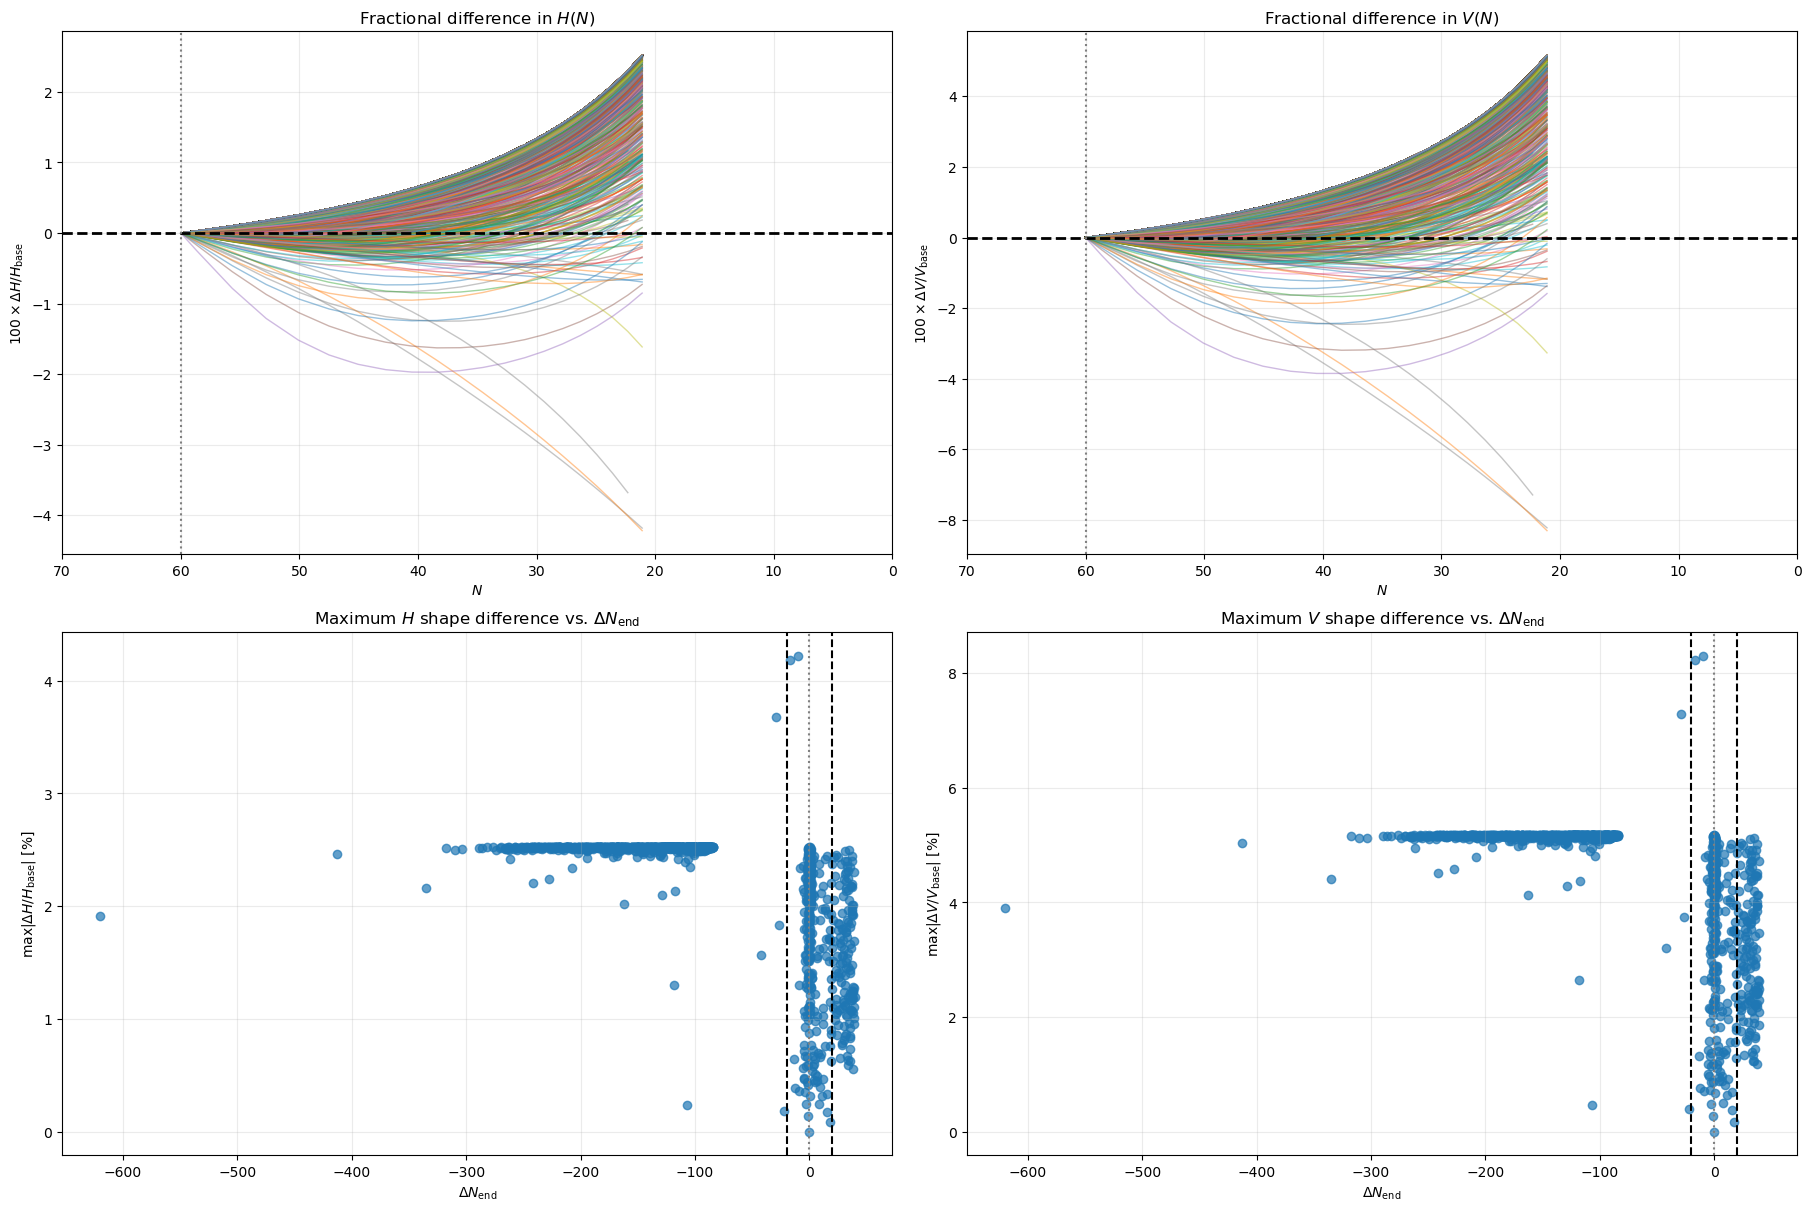


|Delta N_end| <= 20
        max_H_pct   max_V_pct
count  370.000000  370.000000
mean     1.852878    3.797565
std      0.659892    1.346965
min      0.000000    0.000000
25%      1.520277    3.125914
50%      2.096431    4.303540
75%      2.323210    4.764673
max      4.221089    8.301969

|Delta N_end| > 20
         max_H_pct    max_V_pct
count  1080.000000  1080.000000
mean      2.382981     4.879604
std       0.391853     0.803360
min       0.183850     0.392524
25%       2.509814     5.140101
50%       2.520614     5.162636
75%       2.522631     5.166855
max       3.682250     7.289744


In [10]:
# ============================================================
# Compare all H(N) and V(N) curves to the FIRST saved model
# ============================================================

NEQS = 6
model_tag = "higgs"

N_REF = 60.0
N_MIN = 20.0
N_MAX = 60.0


# ------------------------------------------------------------
# Load path from one model directory
# ------------------------------------------------------------

def load_path_from_outdir(outdir, NEQS=NEQS):

    folder = Path(outdir)

    matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_*.dat"
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"No path found in {folder}"
        )

    return np.loadtxt(matches[0])


# ------------------------------------------------------------
# Extract N, H, V and normalize H,V at N=60
# ------------------------------------------------------------

def get_HV(data, N_ref=60.0):

    N = data[:, NEQS]
    H = data[:, 1]
    V = data[:, NEQS + 1]

    # We expect the saved trajectory to already be increasing.
    # If fully decreasing, reverse paired arrays together.
    dN = np.diff(N)

    if np.all(dN > 0):
        pass

    elif np.all(dN < 0):
        N = N[::-1]
        H = H[::-1]
        V = V[::-1]

    else:
        raise ValueError(
            "N is non-monotonic; refusing to reorder."
        )

    # Need N=60 to exist inside trajectory
    if not (N.min() <= N_ref <= N.max()):
        raise ValueError(
            f"N={N_ref} outside path range."
        )

    H60 = np.interp(N_ref, N, H)
    V60 = np.interp(N_ref, N, V)

    H_norm = H / H60
    V_norm = V / V60

    mask = (
        (N >= N_MIN)
        & (N <= N_MAX)
    )

    return (
        N[mask],
        H_norm[mask],
        V_norm[mask],
    )


# ------------------------------------------------------------
# Load all accepted models
# ------------------------------------------------------------

summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)

print(
    f"Total models = {len(summary_all)}"
)


# ============================================================
# BASE MODEL = FIRST MODEL SAVED
# ============================================================

base_row = summary_all.iloc[0]

base_data = load_path_from_outdir(
    base_row["outdir"]
)

N_base, H_base, V_base = get_HV(
    base_data,
    N_ref=N_REF,
)

base_Nend = float(
    base_row["original_N_end"]
)

print("\nBase model:")
print("outdir =", base_row["outdir"])
print("original_N_end =", base_Nend)


# ============================================================
# Compare every model to base
# ============================================================

models = []

for i, row in summary_all.iterrows():

    try:

        data = load_path_from_outdir(
            row["outdir"]
        )

        N, H, V = get_HV(
            data,
            N_ref=N_REF,
        )

        # ----------------------------------------------------
        # Compare on BASE model's N grid
        # ----------------------------------------------------

        Nlo = max(
            N_base.min(),
            N.min(),
            N_MIN,
        )

        Nhi = min(
            N_base.max(),
            N.max(),
            N_MAX,
        )

        mask = (
            (N_base >= Nlo)
            & (N_base <= Nhi)
        )

        N_use = N_base[mask]

        H_base_use = H_base[mask]
        V_base_use = V_base[mask]

        # interpolate model onto base model N points
        H_interp = np.interp(
            N_use,
            N,
            H,
        )

        V_interp = np.interp(
            N_use,
            N,
            V,
        )

        # ----------------------------------------------------
        # Fractional error relative to base
        # ----------------------------------------------------

        frac_H = (
            H_interp - H_base_use
        ) / H_base_use

        frac_V = (
            V_interp - V_base_use
        ) / V_base_use

        Nend = float(
            row["original_N_end"]
        )

        deltaN_end = (
            Nend - base_Nend
        )

        models.append({
            "model_index": i,
            "N": N_use,
            "frac_H": frac_H,
            "frac_V": frac_V,
            "deltaN_end": deltaN_end,

            "max_H_pct":
                100.0
                * np.max(np.abs(frac_H)),

            "max_V_pct":
                100.0
                * np.max(np.abs(frac_V)),
        })

    except Exception as exc:

        print(
            f"Skipping model {i}: {exc}"
        )


print(
    f"Successfully compared {len(models)} models."
)


# ============================================================
# PLOT FRACTIONAL ERRORS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    constrained_layout=True,
)

ax_H = axes[0, 0]
ax_V = axes[0, 1]

ax_H_dN = axes[1, 0]
ax_V_dN = axes[1, 1]


# ------------------------------------------------------------
# Fractional differences vs N
# ------------------------------------------------------------

for model in models:

    ax_H.plot(
        model["N"],
        100.0 * model["frac_H"],
        lw=1.0,
        alpha=0.45,
    )

    ax_V.plot(
        model["N"],
        100.0 * model["frac_V"],
        lw=1.0,
        alpha=0.45,
    )


ax_H.axhline(
    0,
    color="black",
    ls="--",
    lw=2,
)

ax_V.axhline(
    0,
    color="black",
    ls="--",
    lw=2,
)


ax_H.axvline(
    60,
    color="gray",
    ls=":",
)

ax_V.axvline(
    60,
    color="gray",
    ls=":",
)


ax_H.set_title(
    r"Fractional difference in $H(N)$"
)

ax_V.set_title(
    r"Fractional difference in $V(N)$"
)


ax_H.set_ylabel(
    r"$100\times\Delta H/H_{\rm base}$"
)

ax_V.set_ylabel(
    r"$100\times\Delta V/V_{\rm base}$"
)


ax_H.set_xlabel(r"$N$")
ax_V.set_xlabel(r"$N$")


# Show evolution 70 -> 0
ax_H.set_xlim(70, 0)
ax_V.set_xlim(70, 0)


# ============================================================
# Max error vs Delta N_end
# ============================================================

deltaN = np.array([
    m["deltaN_end"]
    for m in models
])

max_H = np.array([
    m["max_H_pct"]
    for m in models
])

max_V = np.array([
    m["max_V_pct"]
    for m in models
])


ax_H_dN.scatter(
    deltaN,
    max_H,
    alpha=0.7,
)

ax_V_dN.scatter(
    deltaN,
    max_V,
    alpha=0.7,
)


# Your proposed truncation cutoff
for ax in [
    ax_H_dN,
    ax_V_dN,
]:

    ax.axvline(
        -20,
        color="black",
        ls="--",
    )

    ax.axvline(
        20,
        color="black",
        ls="--",
    )

    ax.axvline(
        0,
        color="gray",
        ls=":",
    )


ax_H_dN.set_title(
    r"Maximum $H$ shape difference vs. $\Delta N_{\rm end}$"
)

ax_V_dN.set_title(
    r"Maximum $V$ shape difference vs. $\Delta N_{\rm end}$"
)


ax_H_dN.set_xlabel(
    r"$\Delta N_{\rm end}$"
)

ax_V_dN.set_xlabel(
    r"$\Delta N_{\rm end}$"
)


ax_H_dN.set_ylabel(
    r"$\max |\Delta H/H_{\rm base}|\ [\%]$"
)

ax_V_dN.set_ylabel(
    r"$\max |\Delta V/V_{\rm base}|\ [\%]$"
)


for ax in axes.ravel():
    ax.grid(
        True,
        alpha=0.25,
    )


plt.show()


# ============================================================
# SIMPLE NUMERICAL SUMMARY
# ============================================================

result_df = pd.DataFrame({
    "model_index": [
        m["model_index"]
        for m in models
    ],

    "deltaN_end": [
        m["deltaN_end"]
        for m in models
    ],

    "max_H_pct": [
        m["max_H_pct"]
        for m in models
    ],

    "max_V_pct": [
        m["max_V_pct"]
        for m in models
    ],
})


inside = result_df[
    np.abs(
        result_df["deltaN_end"]
    ) <= 20
]


outside = result_df[
    np.abs(
        result_df["deltaN_end"]
    ) > 20
]


print("\n========================================")
print("|Delta N_end| <= 20")
print("========================================")

print(
    inside[
        [
            "max_H_pct",
            "max_V_pct",
        ]
    ].describe()
)


print("\n========================================")
print("|Delta N_end| > 20")
print("========================================")

print(
    outside[
        [
            "max_H_pct",
            "max_V_pct",
        ]
    ].describe()
)

Right, so above I inspected the normalized fractional error plots (looking at shape differences in background)for all models. Keep in mind, every model is normalized at it $N=60$, so the maxima above are measuring how much the shape diverges as we go from $N=60$ down to $N=20$ which is the N-range of interest for this study. This set of models has a $\Delta N = N_{end} - N_{end,fiducial}$ that are max around 300 or so $N_{end}$ different from the fiducial model. As you can see,large changes in $N_{end}$ do not necessarily correspond to large changes in the background shape. In other words, $N_{end}$ is more of a shift of the trajectory but does not deform the underlying inflationary dynamics. Us placing a model selection cut on $\Delta N$ does not reduce the inflationary dynamics we are actually considering. Even for models with $|\Delta N_{end}| > 20$ maintain a small normalized shape difference from base by only a few percent. Making the $|\Delta N_{end}| < 20$ cut is not marking a physical breakdown but rather is a practical bound on how much trajectory translation we expect to absorb from uncertainties due to truncation order. Next, let's go ahead and compare how much the space changes with the model selection cut.



## Paper Method: $\Delta N$ Model Selection Cut

I have already discussed that for the most part when you examine $\Delta N$ for a set near the fiducial model and examine a set NEQs (ex. NEQs=8) while setting higher order parameters progressively to zero you do not recover a $\Delta N$ greater than 20 e-folds, with no change to the spectral shape. The same is seen as you examine the base model as it truncated to higher order up to NEQs=9 (convergence test).

Given a set of models with an associated NEQs we can generate a large number of models that end up with a range of $\Delta N$ values (anywhere from -250 to 50,etc). This range of $\Delta N$ values typically has viable solutions that may live in a basin with a $\Delta N = -250$ from the base or $\Delta N = +50$ from the base. However, the models themselves sampled near the fiducial model correspond to similar nphysics of other models in the space. We make an explicit choice to discard models with a $|\Delta N| > 20$. 
The models in cases where it appears to be significantly past $|\Delta N| > 20$ are evolving for awhile but are effectively equivalent to a different model in our space of initial conditions. 

By making this model-selection cut we are very likely not removing any models with unique physics applied to them. It would be useful to explicitly show that this is case. 


The general idea will discard $|\Delta N| > 20$, where $\Delta N = N_{end}- N_{end, fiducial}$. 




# Plot 2: All Models with the $|\Delta N|>20$ (Likely to go in Appendix)

Total accepted models found: 1450
Base model path:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00/path_neqs6_N0to70_paramsAtN60_lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00.dat

DELTA N CLASSIFICATION
Total accepted models found : 1450
Delta N maximum             : 20
Models passing cut          : 370
Models failing cut          : 1080
Models failing to load      : 0


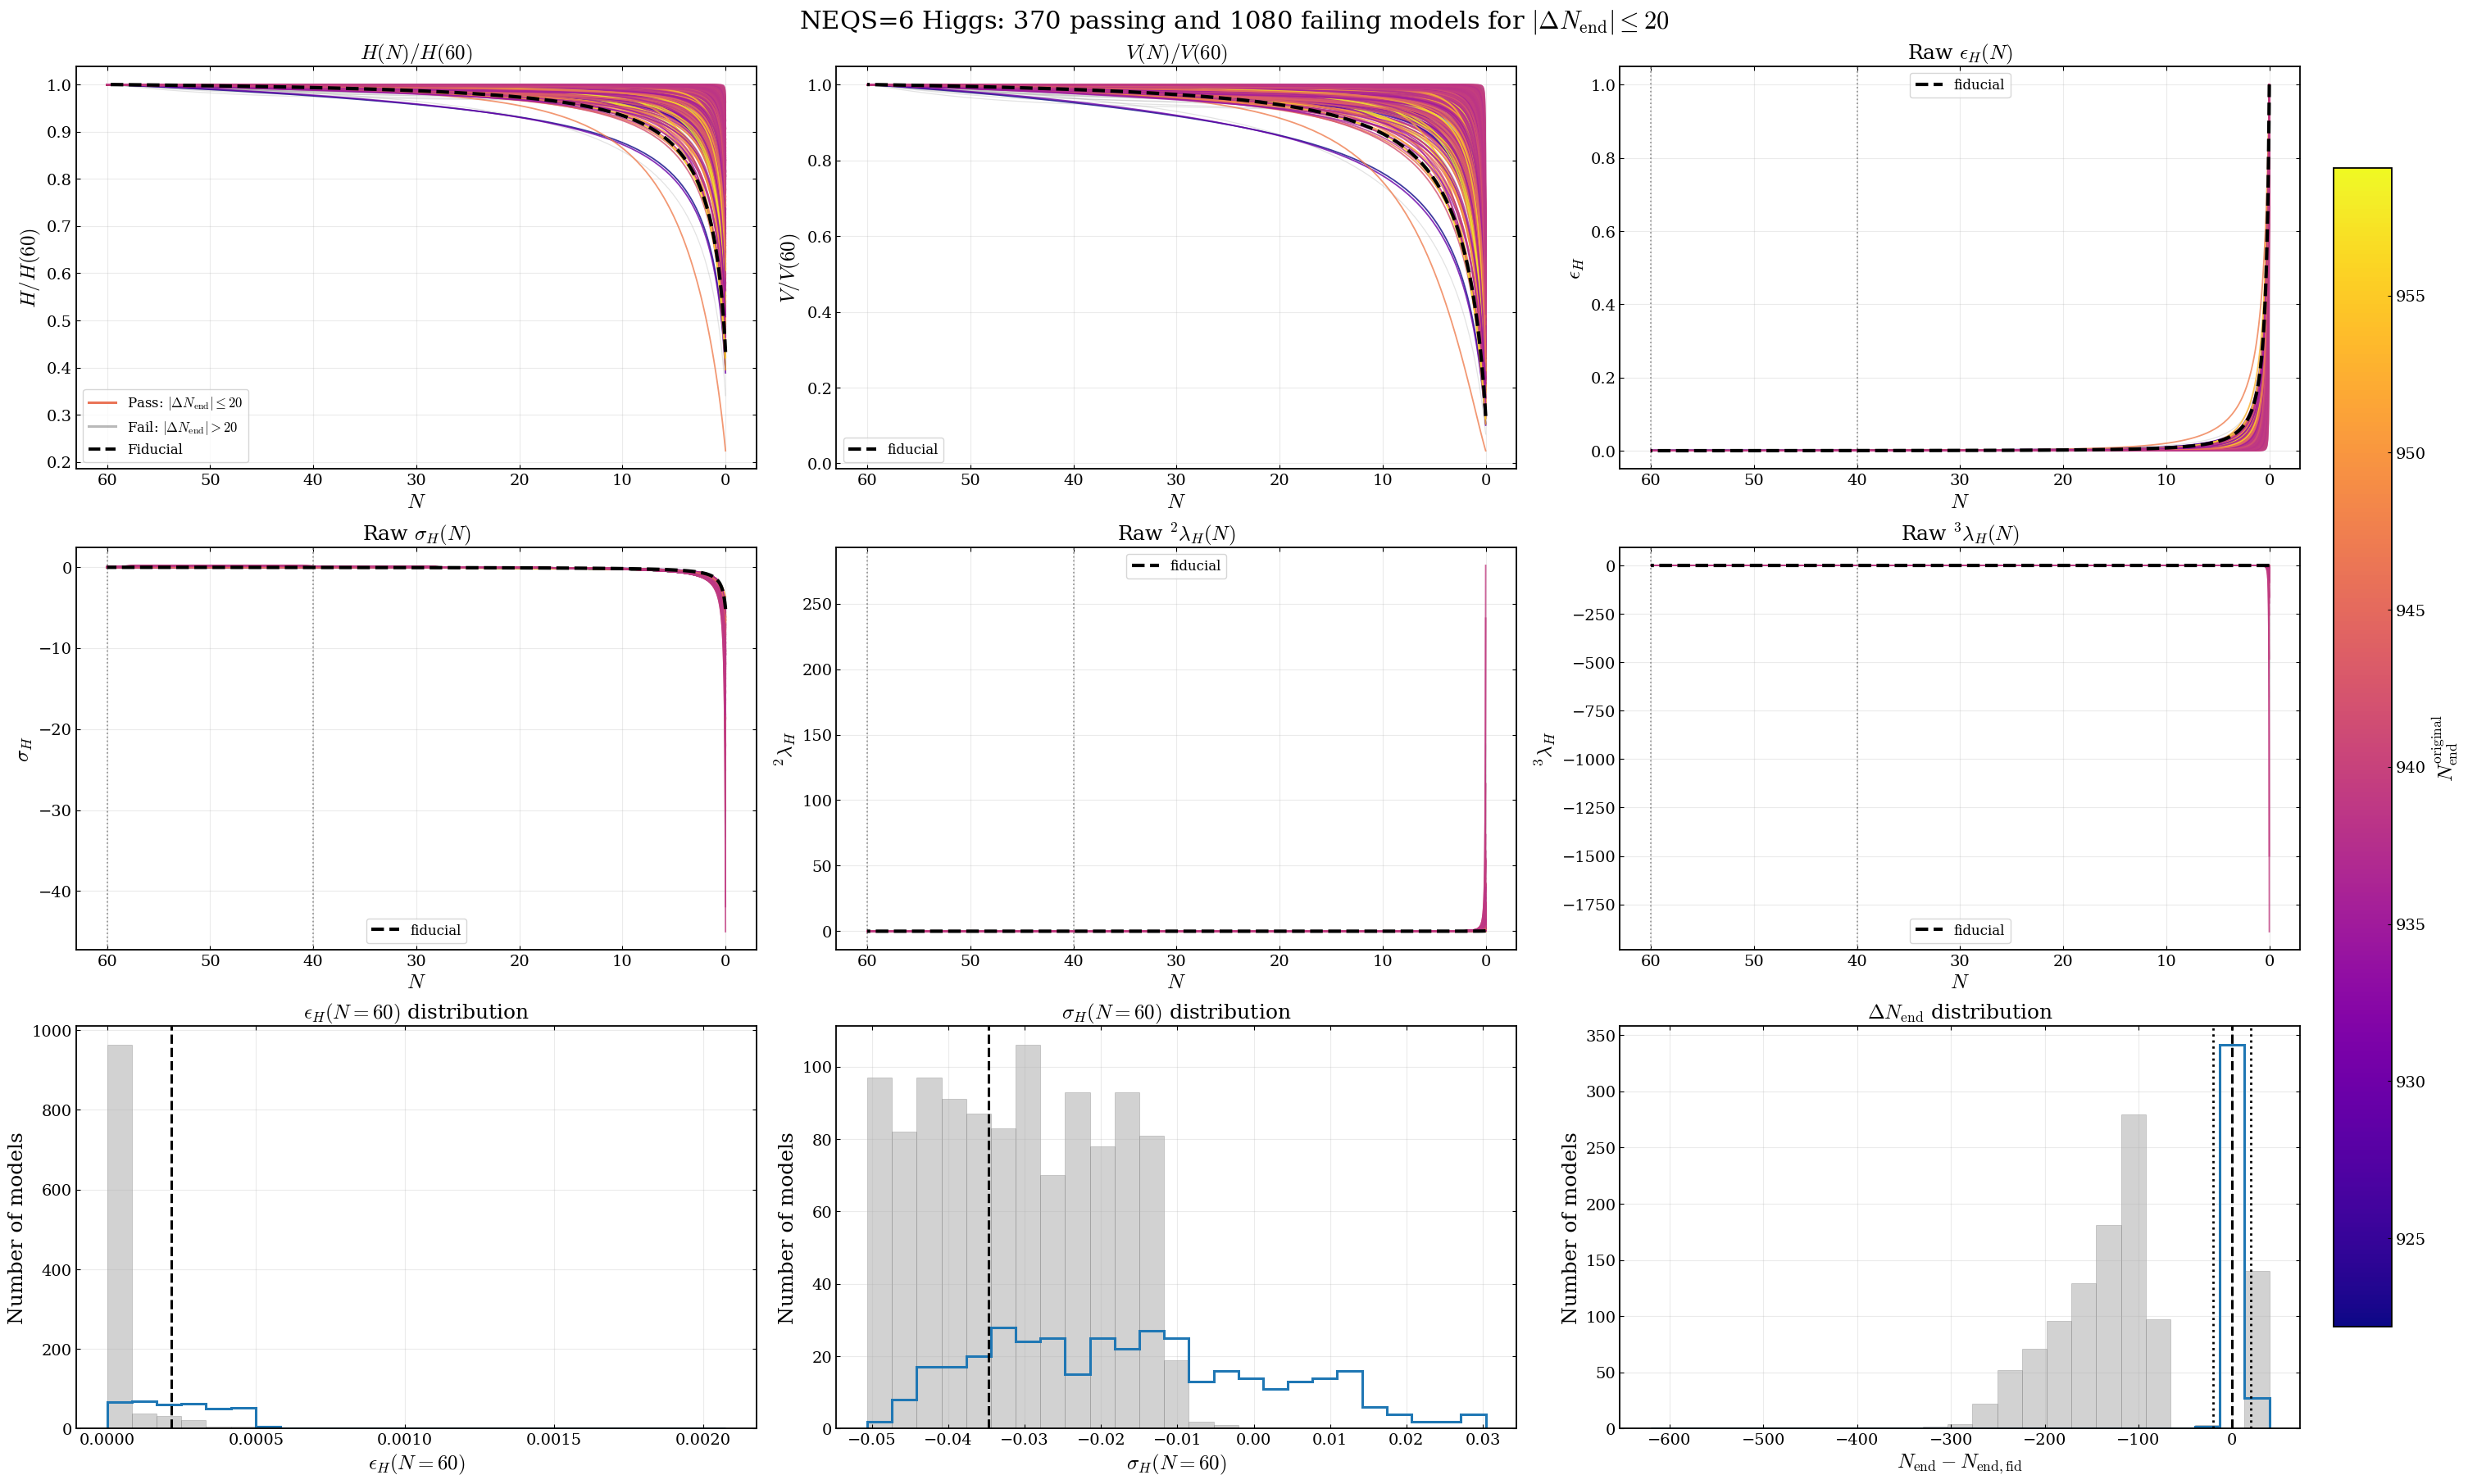

Figure saved to: paper_higgs_neqs6_deltaNmax_20_background_summary.pdf


In [11]:
# ============================================================
# CELL X:

#This will show all models and all the ones that got cut!

# ============================================================


plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


# Configuration
NEQS = 6
model_tag = "higgs"
N_ref = 60.0

# Restrict the visible N interval if desired.
# Set either value to None to use every available point.
N_plot_min = 0.0
N_plot_max = 60.0
DELTA_N_MAX = 20.0

# Load one saved trajectory
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)

    matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"No path file found in:\n{folder}"
        )

    return np.loadtxt(matches[0]), matches[0]


# Prepare all quantities needed for plotting
def process_trajectory_maxN_both(
    data,
    N_ref=N_ref,
    NEQS=NEQS,
    N_min=N_plot_min,
    N_max=N_plot_max,
):
    """
    Extract and prepare the saved background trajectory.

    For NEQS=6, the saved columns are:

        0   phi
        1   H
        2   epsilon_H
        3   sigma_H
        4   lambda_2
        5   lambda_3
        6   N
        7   V
        8   kinetic-energy-like quantity
    """

    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    sigma_raw = np.asarray(data[:, 3], dtype=float)
    lam2_raw = np.asarray(data[:, 4], dtype=float)
    lam3_raw = np.asarray(data[:, 5], dtype=float)

    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(sigma_raw)
        & np.isfinite(lam2_raw)
        & np.isfinite(lam3_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )

    phi_raw = phi_raw[finite]
    H_raw = H_raw[finite]
    eps_raw = eps_raw[finite]
    sigma_raw = sigma_raw[finite]
    lam2_raw = lam2_raw[finite]
    lam3_raw = lam3_raw[finite]
    N_raw = N_raw[finite]
    V_raw = V_raw[finite]

    if len(N_raw) < 2:
        raise ValueError("Not enough finite trajectory points.")

    # Ensure N is increasing for interpolation
    #Again this is checking monotonicity
    #Are consec terms going ++++ or ----
    dN = np.diff(N_raw)

    if np.all(dN >= 0):
        N = N_raw
        phi = phi_raw
        H = H_raw
        eps = eps_raw
        sigma = sigma_raw
        lam2 = lam2_raw
        lam3 = lam3_raw
        V = V_raw

    elif np.all(dN <= 0):
        N = N_raw[::-1]
        phi = phi_raw[::-1]
        H = H_raw[::-1]
        eps = eps_raw[::-1]
        sigma = sigma_raw[::-1]
        lam2 = lam2_raw[::-1]
        lam3 = lam3_raw[::-1]
        V = V_raw[::-1]

    else:
        raise ValueError(
            "N is non-monotonic; refusing to reorder trajectory."
        )

    # Require the normalization point
    #Guard before interpolation
    if not (N.min() <= N_ref <= N.max()):
        raise ValueError(
            f"N_ref={N_ref} outside trajectory range "
            f"[{N.min():.6f}, {N.max():.6f}]"
        )

    H_ref = np.interp(N_ref, N, H)
    V_ref = np.interp(N_ref, N, V)

    if not np.isfinite(H_ref) or abs(H_ref) < 1e-30:
        raise ValueError(
            f"Invalid H_ref at N={N_ref}: {H_ref}"
        )

    if not np.isfinite(V_ref) or abs(V_ref) < 1e-30:
        raise ValueError(
            f"Invalid V_ref at N={N_ref}: {V_ref}"
        )

    # Optional plotting window, if I only wanna look at a certain range!
    plot_mask = np.ones_like(N, dtype=bool)

    if N_min is not None:
        plot_mask &= N >= N_min

    if N_max is not None:
        plot_mask &= N <= N_max

    if not np.any(plot_mask):
        raise ValueError(
            "No points remain inside the requested N plotting range."
        )

    return {
        "N": N[plot_mask],
        "phi": phi[plot_mask],

        # Only H and V are normalized by H for model at N=60 and same for V
        "H_norm": H[plot_mask] / H_ref,
        "V_norm": V[plot_mask] / V_ref,

        # Flow variables remain raw
        "epsilon": eps[plot_mask],
        "sigma": sigma[plot_mask],
        "lambda2": lam2[plot_mask],
        "lambda3": lam3[plot_mask],

        # Values exactly at N_ref, these interped
        #This using 1D linear interpolation
        #Such that line is drawn between two saved traj paths
        "epsilon_ref": np.interp(N_ref, N, eps),
        "sigma_ref": np.interp(N_ref, N, sigma),
        "lambda2_ref": np.interp(N_ref, N, lam2),
        "lambda3_ref": np.interp(N_ref, N, lam3),
    }


# Load every accepted model across every batch
summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)

print(f"Total accepted models found: {len(summary_all)}")


# Identify the fiducial/base model
base_param_name, base_val = (
    MODEL_CONFIG[model_tag]["lam_base"][NEQS]
)

base_mask = np.isclose(
    summary_all[base_param_name].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)

if not np.any(base_mask):
    raise FileNotFoundError(
        f"Could not find the base model with "
        f"{base_param_name}={base_val:.10e}"
    )

base_row = summary_all.loc[base_mask].iloc[0]

base_N_end = float(base_row["original_N_end"])

base_data, base_path_file = load_path_from_outdir(
    base_row["outdir"]
)

base_curves = process_trajectory_maxN_both(base_data)

print(f"Base model path:\n{base_path_file}")

# Process models satisfying the Delta N cut
processed = []
failed = []
rejected_deltaN = []

# ============================================================
# Process all models and classify them by the Delta N cut
# ============================================================

passed_models = []
rejected_models = []
failed = []

for row_index, row in summary_all.iterrows():
    try:
        N_end = float(row["original_N_end"])
        deltaN_from_base = N_end - base_N_end

        # Load every trajectory, whether it passes or fails the cut
        data, path_file = load_path_from_outdir(
            row["outdir"]
        )

        curves = process_trajectory_maxN_both(data)

        model_data = {
            **curves,
            "row_index": row_index,
            "path_file": path_file,
            "outdir": row["outdir"],
            "original_N_end": N_end,
            "deltaN_from_base": deltaN_from_base,

            # Initial sampled values stored in the summary
            "eps_input": float(row["eps"]),
            "sig_input": float(row["sig"]),
            "lam2_input": float(row["lam2"]),
            "lam3_input": float(row["lam3"]),
        }

        # Classify the model after loading its trajectory
        if abs(deltaN_from_base) <= DELTA_N_MAX:
            passed_models.append(model_data)
        else:
            rejected_models.append(model_data)

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:
        failed.append(
            (
                row.get("outdir", f"row {row_index}"),
                str(exc),
            )
        )

# Keep this alias so less of the remaining plotting code must change
processed = passed_models

print("\n" + "=" * 70)
print("DELTA N CLASSIFICATION")
print("=" * 70)

print(f"Total accepted models found : {len(summary_all)}")
print(f"Delta N maximum             : {DELTA_N_MAX:g}")
print(f"Models passing cut          : {len(passed_models)}")
print(f"Models failing cut          : {len(rejected_models)}")
print(f"Models failing to load      : {len(failed)}")

print("=" * 70)


if failed:
    print(f"Skipped models: {len(failed)}")
    for outdir, message in failed[:10]:
        print(f"  {outdir}: {message}")

    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")


if not processed:
    raise RuntimeError("No valid model trajectories were processed.")


# Color passing models by their original N_end
#So color goes to passing models
Nend_vals = np.asarray(
    [model["original_N_end"] for model in processed],
    dtype=float,
)

#it really should be already but
finite_Nend = np.isfinite(Nend_vals)

if not np.any(finite_Nend):
    raise ValueError("No finite original_N_end values found.")

    #ignoring any nans
Nend_min = np.nanmin(Nend_vals)
Nend_max = np.nanmax(Nend_vals)

# Avoid a zero-width color normalization
if np.isclose(Nend_min, Nend_max):
    Nend_min -= 0.5 #subtract this amount from existing value x = x - 0.5
    Nend_max += 0.5 #add this amount such that x = x + 0.5

cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(
    vmin=Nend_min,
    vmax=Nend_max,
)


# ------------------------------------------------------------
# Construct the figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    3,
    figsize=(30, 18),
    constrained_layout=True,
)

(
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
    ax_eps60,
    ax_sig60,
    ax_deltaN,
) = axes.ravel()


# Now I can plot both rejected AND processed ones 

# ============================================================
# Rejected models: gray background trajectories
# ============================================================

#zorder will control which lines are places visually on top

# zorder=1   # rejected models behind
# zorder=2   # passing models above them
# zorder=3   # fiducial should be highest


for model in rejected_models:

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )
    
# ============================================================
# Passing models: colored by original N_end
# ============================================================

for model in passed_models:
    color = cmap(norm(model["original_N_end"]))

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )
    
    

# Fiducial model overlay
base_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "fiducial",
    "zorder": 3,
}

ax_H.plot(
    base_curves["N"],
    base_curves["H_norm"],
    **base_style,
)

ax_V.plot(
    base_curves["N"],
    base_curves["V_norm"],
    **base_style,
)

ax_eps.plot(
    base_curves["N"],
    base_curves["epsilon"],
    **base_style,
)

ax_sigma.plot(
    base_curves["N"],
    base_curves["sigma"],
    **base_style,
)

ax_lam2.plot(
    base_curves["N"],
    base_curves["lambda2"],
    **base_style,
)

ax_lam3.plot(
    base_curves["N"],
    base_curves["lambda3"],
    **base_style,
)

classification_handles = [
    Line2D(
        [0],
        [0],
        color=cmap(0.65),
        lw=2.2,
        label=rf"Pass: $|\Delta N_{{\rm end}}| \leq {DELTA_N_MAX:g}$",
    ),
    Line2D(
        [0],
        [0],
        color="gray",
        lw=2.2,
        alpha=0.55,
        label=rf"Fail: $|\Delta N_{{\rm end}}| > {DELTA_N_MAX:g}$",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.8,
        ls="--",
        label="Fiducial",
    ),
]

ax_H.legend(
    handles=classification_handles,
    loc="best",
)


# ------------------------------------------------------------
# N=60 distributions
# ------------------------------------------------------------

    
eps60_passed = np.asarray(
    [model["epsilon_ref"] for model in passed_models],
    dtype=float,
)

eps60_rejected = np.asarray(
    [model["epsilon_ref"] for model in rejected_models],
    dtype=float,
)

sig60_passed = np.asarray(
    [model["sigma_ref"] for model in passed_models],
    dtype=float,
)

sig60_rejected = np.asarray(
    [model["sigma_ref"] for model in rejected_models],
    dtype=float,
)

deltaN_passed = np.asarray(
    [model["deltaN_from_base"] for model in passed_models],
    dtype=float,
)

deltaN_rejected = np.asarray(
    [model["deltaN_from_base"] for model in rejected_models],
    dtype=float,
)



all_eps60 = np.concatenate(
    [eps60_passed, eps60_rejected]
)

eps_bins = np.histogram_bin_edges(
    all_eps60,
    bins=25,
)

ax_eps60.hist(
    eps60_rejected,
    bins=eps_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_eps60.hist(
    eps60_passed,
    bins=eps_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)

ax_eps60.axvline(
    base_curves["epsilon_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)



#sigma hist
all_sig60 = np.concatenate(
    [sig60_passed, sig60_rejected]
)

sig_bins = np.histogram_bin_edges(
    all_sig60,
    bins=25,
)

ax_sig60.hist(
    sig60_rejected,
    bins=sig_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_sig60.hist(
    sig60_passed,
    bins=sig_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)

ax_sig60.axvline(
    base_curves["sigma_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


#deltaN hist
all_deltaN = np.concatenate(
    [deltaN_passed, deltaN_rejected]
)

deltaN_bins = np.histogram_bin_edges(
    all_deltaN,
    bins=25,
)

ax_deltaN.hist(
    deltaN_rejected,
    bins=deltaN_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_deltaN.hist(
    deltaN_passed,
    bins=deltaN_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)


ax_deltaN.axvline(
    0.0,
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)

ax_deltaN.axvline(
    -DELTA_N_MAX,
    color="black",
    ls=":",
    lw=2.0,
    label=rf"$\pm {DELTA_N_MAX:g}$ cut",
)

ax_deltaN.axvline(
    DELTA_N_MAX,
    color="black",
    ls=":",
    lw=2.0,
)


# Titles and labels
ax_H.set_title(
    rf"$H(N)/H({N_ref:g})$"
)

ax_V.set_title(
    rf"$V(N)/V({N_ref:g})$"
)

ax_eps.set_title(
    r"Raw $\epsilon_H(N)$"
)

ax_sigma.set_title(
    r"Raw $\sigma_H(N)$"
)

ax_lam2.set_title(
    r"Raw ${}^{2}\lambda_H(N)$"
)

ax_lam3.set_title(
    r"Raw ${}^{3}\lambda_H(N)$"
)

ax_eps60.set_title(
    rf"$\epsilon_H(N={N_ref:g})$ distribution"
)

ax_sig60.set_title(
    rf"$\sigma_H(N={N_ref:g})$ distribution"
)

ax_deltaN.set_title(
    r"$\Delta N_{\rm end}$ distribution"
)


for ax in [
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()


ax_H.set_ylabel(
    rf"$H/H({N_ref:g})$"
)

ax_V.set_ylabel(
    rf"$V/V({N_ref:g})$"
)

ax_eps.set_ylabel(
    r"$\epsilon_H$"
)

ax_sigma.set_ylabel(
    r"$\sigma_H$"
)

ax_lam2.set_ylabel(
    r"${}^{2}\lambda_H$"
)

ax_lam3.set_ylabel(
    r"${}^{3}\lambda_H$"
)

ax_eps60.set_xlabel(
    rf"$\epsilon_H(N={N_ref:g})$"
)

ax_eps60.set_ylabel(
    "Number of models"
)

ax_sig60.set_xlabel(
    rf"$\sigma_H(N={N_ref:g})$"
)

ax_sig60.set_ylabel(
    "Number of models"
)

ax_deltaN.set_xlabel(
    r"$N_{\rm end}-N_{\rm end,fid}$"
)

ax_deltaN.set_ylabel(
    "Number of models"
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

# Explicit classification legend on the first panel
ax_H.legend(
    handles=classification_handles,
    loc="best",
)

# Fiducial legends on remaining trajectory panels
for ax in [
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend()
        



# Mark N=60 and N=40 on the raw epsilon/sigma panels
for ax in [ax_eps, ax_sigma, ax_lam2, ax_lam3]:
    ax.axvline(
        60.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )

    ax.axvline(
        40.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes[:, :].ravel().tolist(),
    pad=0.015,
    shrink=0.85,
)

cbar.set_label(
    r"$N_{\rm end}^{\rm original}$"
)

cbar.ax.tick_params(
    direction="in"
)

cbar_formatter = ScalarFormatter(
    useOffset=False
)

cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()


fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"{len(passed_models)} passing and "
    rf"{len(rejected_models)} failing models for "
    rf"$|\Delta N_{{\rm end}}| \leq {DELTA_N_MAX:g}$"
)

output_name = (
    f"paper_{model_tag}_neqs{NEQS}_"
    f"deltaNmax_{DELTA_N_MAX:g}_background_summary.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {output_name}")



# Plot 3: CMB Observables Past Model Selection Cut

Saved figure to:
paper_higgs_neqs6_observables_vs_deltaN_abs_le_20.pdf


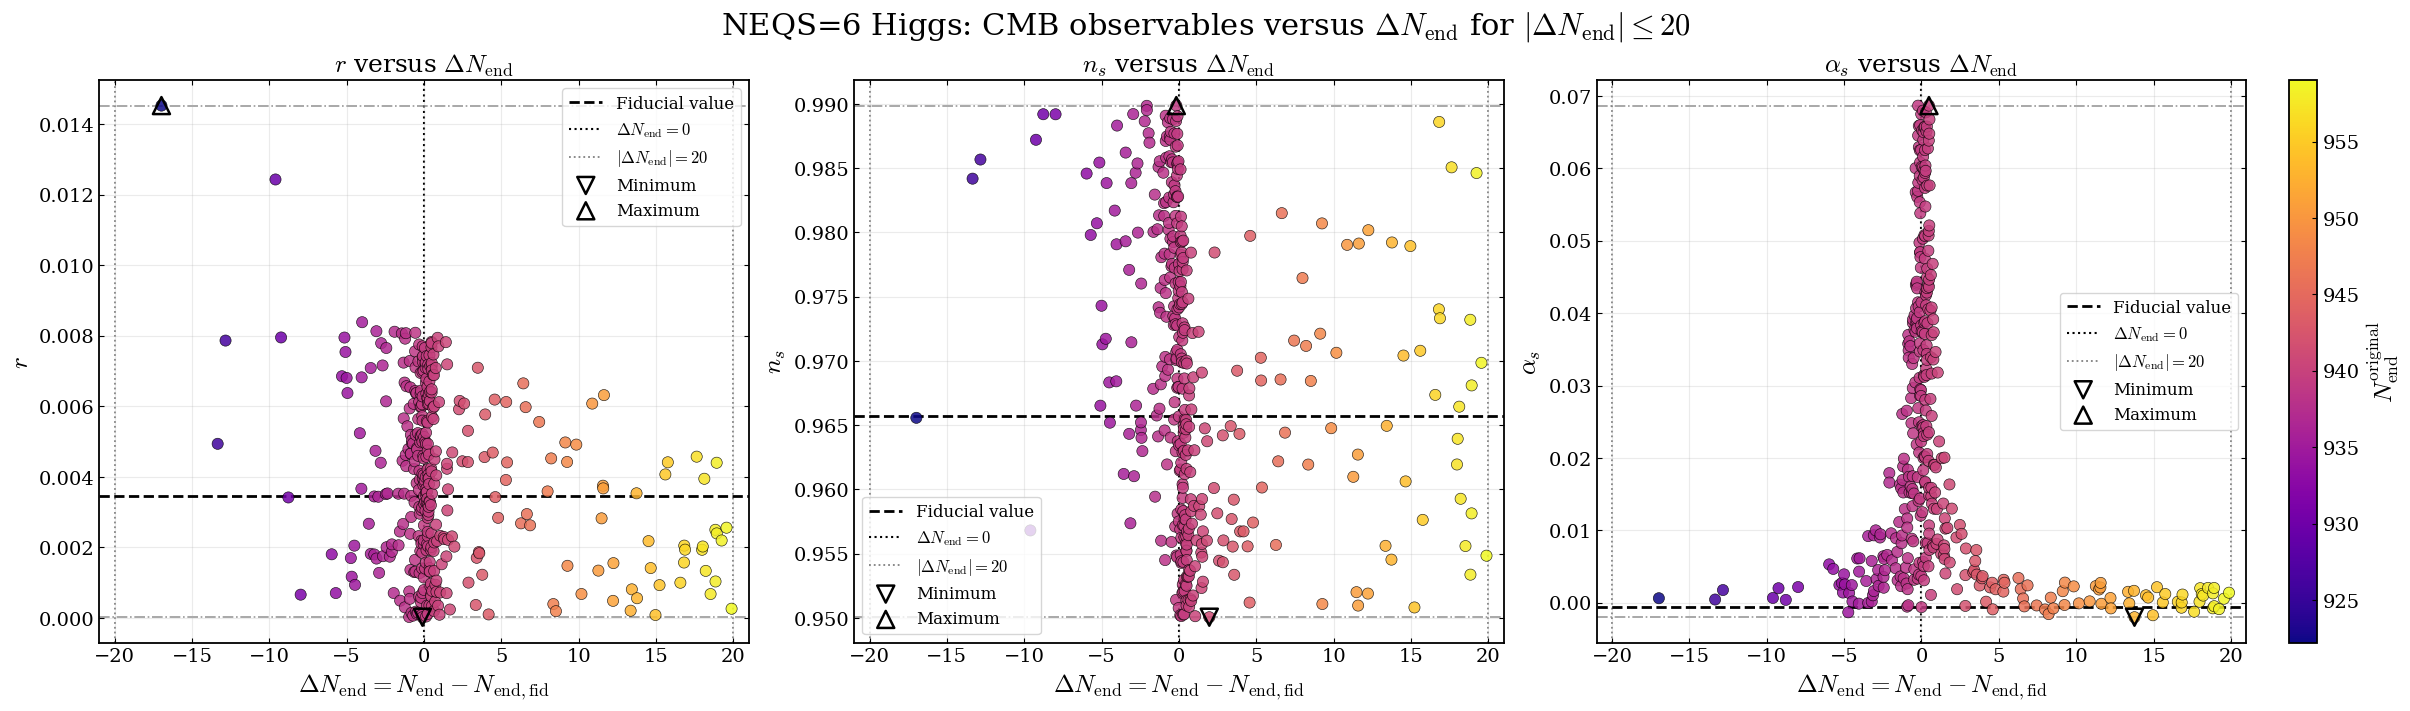


Higgs (NEQS=6): observable ranges for |Delta N| <= 20
Total models in summary     : 1450
Finite models               : 1450
Models passing Delta N cut  : 370
Models failing Delta N cut  : 1080
Models with invalid values  : 0
Fiducial original N_end     : 939.1635722724
Selected Delta N range      : [-16.974504, 19.879733]

------------------------------------------------------------------------------------
Observable: r
Fiducial value : 3.4541891486e-03
Range          : [2.1713236137e-05, 1.4521249036e-02]
Width          : 1.4499535800e-02
Mean           : 3.9035850283e-03
Median         : 3.8007050240e-03
Std. dev.      : 2.4549055316e-03
Minimum at     : Delta N=-0.102799
Maximum at     : Delta N=-16.974504
Minimum model  : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch005/lam2_-1.8176652237e-02_lam3_-1.9190938351e-03_lam4_0.0000000000e+00_lam5_0.0000000000e+00
Maximum model  : /Users

In [12]:
# ============================================================
# Observables versus Delta N
#
# Panels:
#   r versus Delta N_end
#   n_s versus Delta N_end
#   alpha_s versus Delta N_end
#
# Uses all accepted models in summary_all, then applies:
#
#       |Delta N_end| <= DELTA_N_MAX
#
# where:
#
#       Delta N_end = N_end - N_end,fiducial
# ============================================================

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
NEQS = 6
model_tag = "higgs"

DELTA_N_MAX = 20.0


# ============================================================
# Main plotting function
# ============================================================
def plot_observables_vs_deltaN(
    summary_all,
    model_tag,
    NEQS,
    max_deltaN=20.0,
    save=True,
    filename=None,
):
    """
    Plot r, n_s, and alpha_s versus Delta N_end for all accepted
    models satisfying:

        |Delta N_end| <= max_deltaN

    where:

        Delta N_end = N_end - N_end,fiducial

    Parameters
    ----------
    summary_all : pandas.DataFrame
        Full summary DataFrame containing all accepted models.

        Required columns:
            original_N_end
            r
            n_s
            alpha_s

        It must also contain the base-parameter column specified
        by MODEL_CONFIG.

    model_tag : str
        Model family key, such as "higgs".

    NEQS : int
        Number of slow-roll flow equations.

    max_deltaN : float, default=20
        Maximum allowed absolute difference in N_end:

            |Delta N_end| <= max_deltaN

    save : bool, default=True
        If True, save the figure as a PDF.

    filename : str or None
        Optional output filename.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Generated figure.

    axes : numpy.ndarray
        Array containing the three plotting axes.

    observable_stats : pandas.DataFrame
        Summary statistics for r, n_s, and alpha_s.

    models_used : pandas.DataFrame
        Cleaned DataFrame containing models that passed the
        Delta N cut.

    rejected_models : pandas.DataFrame
        Cleaned DataFrame containing models that failed the
        Delta N cut.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if max_deltaN < 0:
        raise ValueError(
            "max_deltaN must be nonnegative."
        )

    required_columns = {
        "original_N_end",
        "r",
        "n_s",
        "alpha_s",
    }

    missing_columns = required_columns.difference(
        summary_all.columns
    )

    if missing_columns:
        raise ValueError(
            "summary_all is missing the following columns: "
            f"{sorted(missing_columns)}"
        )

    if model_tag not in MODEL_CONFIG:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_CONFIG)}."
        )

    if NEQS not in MODEL_CONFIG[model_tag]["lam_base"]:
        raise ValueError(
            f"No base-model configuration exists for "
            f"model_tag={model_tag!r}, NEQS={NEQS}."
        )

    # --------------------------------------------------------
    # Find the fiducial/base model
    # --------------------------------------------------------
    base_param_name, base_param_value = (
        MODEL_CONFIG[model_tag]["lam_base"][NEQS]
    )

    if base_param_name not in summary_all.columns:
        raise ValueError(
            f"The base-parameter column {base_param_name!r} "
            "is missing from summary_all."
        )

    base_parameter_values = pd.to_numeric(
        summary_all[base_param_name],
        errors="coerce",
    ).to_numpy(dtype=float)

    base_mask = np.isclose(
        base_parameter_values,
        base_param_value,
        rtol=1e-8,
        atol=max(
            1e-15,
            abs(base_param_value) * 1e-8,
        ),
    )

    if not np.any(base_mask):
        raise ValueError(
            f"Could not locate the fiducial model with "
            f"{base_param_name}={base_param_value:.10e}."
        )

    base_row = summary_all.loc[
        base_mask
    ].iloc[0]

    base_N_end = float(
        base_row["original_N_end"]
    )

    if not np.isfinite(base_N_end):
        raise ValueError(
            f"Fiducial original_N_end is not finite: "
            f"{base_N_end}"
        )

    base_values = {
        "r": float(base_row["r"]),
        "n_s": float(base_row["n_s"]),
        "alpha_s": float(base_row["alpha_s"]),
    }

    for observable_name, value in base_values.items():
        if not np.isfinite(value):
            raise ValueError(
                f"Fiducial {observable_name} is not finite: "
                f"{value}"
            )

    # --------------------------------------------------------
    # Build a working DataFrame
    # --------------------------------------------------------
    models_all = summary_all.copy()

    numeric_columns = [
        "original_N_end",
        "r",
        "n_s",
        "alpha_s",
    ]

    for column in numeric_columns:
        models_all[column] = pd.to_numeric(
            models_all[column],
            errors="coerce",
        )

    # Compute Delta N relative to the fiducial model
    models_all["deltaN_from_base"] = (
        models_all["original_N_end"]
        - base_N_end
    )

    # --------------------------------------------------------
    # Remove rows with nonfinite values
    # --------------------------------------------------------
    finite_columns = [
        "original_N_end",
        "deltaN_from_base",
        "r",
        "n_s",
        "alpha_s",
    ]

    finite_mask = np.ones(
        len(models_all),
        dtype=bool,
    )

    for column in finite_columns:
        finite_mask &= np.isfinite(
            models_all[column].to_numpy(
                dtype=float
            )
        )

    invalid_models = models_all.loc[
        ~finite_mask
    ].copy()

    models_all = models_all.loc[
        finite_mask
    ].copy()

    # --------------------------------------------------------
    # Apply the Delta N classification
    # --------------------------------------------------------
    pass_mask = (
        models_all["deltaN_from_base"].abs()
        <= max_deltaN
    )

    models_used = models_all.loc[
        pass_mask
    ].copy()

    rejected_models = models_all.loc[
        ~pass_mask
    ].copy()

    if models_used.empty:
        raise ValueError(
            f"No finite models satisfy "
            f"|Delta N_end| <= {max_deltaN:g}."
        )

    # Sort from negative to positive Delta N
    models_used = models_used.sort_values(
        "deltaN_from_base"
    ).reset_index(drop=True)

    rejected_models = rejected_models.sort_values(
        "deltaN_from_base"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Observable plotting settings
    # --------------------------------------------------------
    observables = [
        {
            "column": "r",
            "label": r"$r$",
            "title": r"$r$ versus $\Delta N_{\rm end}$",
        },
        {
            "column": "n_s",
            "label": r"$n_s$",
            "title": r"$n_s$ versus $\Delta N_{\rm end}$",
        },
        {
            "column": "alpha_s",
            "label": r"$\alpha_s$",
            "title": r"$\alpha_s$ versus $\Delta N_{\rm end}$",
        },
    ]

    # --------------------------------------------------------
    # Compute observable statistics
    # --------------------------------------------------------
    statistics_records = []

    for observable in observables:
        column = observable["column"]

        values = models_used[
            column
        ].to_numpy(dtype=float)

        minimum_position = int(
            np.argmin(values)
        )

        maximum_position = int(
            np.argmax(values)
        )

        minimum_row = models_used.iloc[
            minimum_position
        ]

        maximum_row = models_used.iloc[
            maximum_position
        ]

        record = {
            "observable": column,

            "base_value": base_values[column],

            "minimum": float(
                np.min(values)
            ),

            "maximum": float(
                np.max(values)
            ),

            "range_width": float(
                np.max(values)
                - np.min(values)
            ),

            "mean": float(
                np.mean(values)
            ),

            "median": float(
                np.median(values)
            ),

            "standard_deviation": float(
                np.std(values, ddof=1)
                if len(values) > 1
                else 0.0
            ),

            "deltaN_at_minimum": float(
                minimum_row[
                    "deltaN_from_base"
                ]
            ),

            "deltaN_at_maximum": float(
                maximum_row[
                    "deltaN_from_base"
                ]
            ),

            "N_end_at_minimum": float(
                minimum_row[
                    "original_N_end"
                ]
            ),

            "N_end_at_maximum": float(
                maximum_row[
                    "original_N_end"
                ]
            ),
        }

        if "outdir" in models_used.columns:
            record["outdir_at_minimum"] = (
                minimum_row["outdir"]
            )

            record["outdir_at_maximum"] = (
                maximum_row["outdir"]
            )

        statistics_records.append(
            record
        )

    observable_stats = pd.DataFrame(
        statistics_records
    )

    # --------------------------------------------------------
    # Set up the figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24, 7),
        constrained_layout=True,
    )

    deltaN_values = models_used[
        "deltaN_from_base"
    ].to_numpy(dtype=float)

    # Color passing models by original N_end
    Nend_values = models_used[
        "original_N_end"
    ].to_numpy(dtype=float)

    Nend_min = np.min(Nend_values)
    Nend_max = np.max(Nend_values)

    if np.isclose(Nend_min, Nend_max):
        Nend_min -= 0.5
        Nend_max += 0.5

    norm = mcolors.Normalize(
        vmin=Nend_min,
        vmax=Nend_max,
    )

    cmap = plt.get_cmap(
        "plasma"
    )

    # --------------------------------------------------------
    # Plot each observable
    # --------------------------------------------------------
    for axis, observable in zip(
        axes,
        observables,
    ):
        column = observable["column"]

        observable_values = models_used[
            column
        ].to_numpy(dtype=float)

        axis.scatter(
            deltaN_values,
            observable_values,
            c=Nend_values,
            cmap=cmap,
            norm=norm,
            s=65,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.45,
            zorder=3,
        )

        # Fiducial observable value
        axis.axhline(
            base_values[column],
            color="black",
            linestyle="--",
            linewidth=2.0,
            label="Fiducial value",
            zorder=2,
        )

        # Fiducial Delta N position
        axis.axvline(
            0.0,
            color="black",
            linestyle=":",
            linewidth=1.5,
            label=r"$\Delta N_{\rm end}=0$",
            zorder=1,
        )

        # Delta N cut boundaries
        axis.axvline(
            -max_deltaN,
            color="gray",
            linestyle=":",
            linewidth=1.3,
            label=rf"$|\Delta N_{{\rm end}}|={max_deltaN:g}$",
            zorder=1,
        )

        axis.axvline(
            max_deltaN,
            color="gray",
            linestyle=":",
            linewidth=1.3,
            zorder=1,
        )

        observable_minimum = np.min(
            observable_values
        )

        observable_maximum = np.max(
            observable_values
        )

        # Horizontal range boundaries
        axis.axhline(
            observable_minimum,
            color="gray",
            linestyle="-.",
            linewidth=1.2,
            alpha=0.8,
            zorder=1,
        )

        axis.axhline(
            observable_maximum,
            color="gray",
            linestyle="-.",
            linewidth=1.2,
            alpha=0.8,
            zorder=1,
        )

        # Locations of extrema
        minimum_index = int(
            np.argmin(observable_values)
        )

        maximum_index = int(
            np.argmax(observable_values)
        )

        axis.scatter(
            deltaN_values[minimum_index],
            observable_values[minimum_index],
            marker="v",
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            label="Minimum",
            zorder=5,
        )

        axis.scatter(
            deltaN_values[maximum_index],
            observable_values[maximum_index],
            marker="^",
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            label="Maximum",
            zorder=5,
        )

        axis.set_title(
            observable["title"]
        )

        axis.set_xlabel(
            r"$\Delta N_{\rm end}"
            r"=N_{\rm end}-N_{\rm end,fid}$"
        )

        axis.set_ylabel(
            observable["label"]
        )

        axis.set_xlim(
            -1.05 * max_deltaN,
            1.05 * max_deltaN,
        )

        axis.grid(
            True,
            alpha=0.25,
        )

        axis.legend()

    # --------------------------------------------------------
    # Shared color bar
    # --------------------------------------------------------
    scalar_mappable = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    scalar_mappable.set_array([])

    colorbar = fig.colorbar(
        scalar_mappable,
        ax=axes.ravel().tolist(),
        pad=0.02,
    )

    colorbar.set_label(
        r"$N_{\rm end}^{\rm original}$"
    )

    colorbar_formatter = ScalarFormatter(
        useOffset=False
    )

    colorbar_formatter.set_scientific(
        False
    )

    colorbar.formatter = (
        colorbar_formatter
    )

    colorbar.update_ticks()

    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------
    model_label = MODEL_CONFIG[
        model_tag
    ]["label"]

    fig.suptitle(
        rf"NEQS={NEQS} {model_label}: "
        rf"CMB observables versus $\Delta N_{{\rm end}}$ "
        rf"for $|\Delta N_{{\rm end}}|\leq {max_deltaN:g}$"
    )

    # --------------------------------------------------------
    # Save the figure
    # --------------------------------------------------------
    if filename is None:
        filename = (
            f"paper_{model_tag}_neqs{NEQS}_"
            f"observables_vs_deltaN_abs_le_"
            f"{max_deltaN:g}.pdf"
        )

    if save:
        fig.savefig(
            filename,
            dpi=300,
            bbox_inches="tight",
        )

        print(
            f"Saved figure to:\n{filename}"
        )

    plt.show()

    # --------------------------------------------------------
    # Print classification summary
    # --------------------------------------------------------
    print("\n" + "=" * 84)

    print(
        f"{model_label} (NEQS={NEQS}): "
        f"observable ranges for "
        f"|Delta N| <= {max_deltaN:g}"
    )

    print("=" * 84)

    print(
        f"Total models in summary     : "
        f"{len(summary_all)}"
    )

    print(
        f"Finite models               : "
        f"{len(models_all)}"
    )

    print(
        f"Models passing Delta N cut  : "
        f"{len(models_used)}"
    )

    print(
        f"Models failing Delta N cut  : "
        f"{len(rejected_models)}"
    )

    print(
        f"Models with invalid values  : "
        f"{len(invalid_models)}"
    )

    print(
        f"Fiducial original N_end     : "
        f"{base_N_end:.10f}"
    )

    print(
        f"Selected Delta N range      : "
        f"[{models_used['deltaN_from_base'].min():.6f}, "
        f"{models_used['deltaN_from_base'].max():.6f}]"
    )

    # --------------------------------------------------------
    # Print observable statistics
    # --------------------------------------------------------
    for _, row in observable_stats.iterrows():

        print("\n" + "-" * 84)

        print(
            f"Observable: "
            f"{row['observable']}"
        )

        print(
            f"Fiducial value : "
            f"{row['base_value']:.10e}"
        )

        print(
            f"Range          : "
            f"[{row['minimum']:.10e}, "
            f"{row['maximum']:.10e}]"
        )

        print(
            f"Width          : "
            f"{row['range_width']:.10e}"
        )

        print(
            f"Mean           : "
            f"{row['mean']:.10e}"
        )

        print(
            f"Median         : "
            f"{row['median']:.10e}"
        )

        print(
            f"Std. dev.      : "
            f"{row['standard_deviation']:.10e}"
        )

        print(
            f"Minimum at     : "
            f"Delta N="
            f"{row['deltaN_at_minimum']:.6f}"
        )

        print(
            f"Maximum at     : "
            f"Delta N="
            f"{row['deltaN_at_maximum']:.6f}"
        )

        if "outdir_at_minimum" in row.index:
            print(
                "Minimum model  : "
                f"{row['outdir_at_minimum']}"
            )

            print(
                "Maximum model  : "
                f"{row['outdir_at_maximum']}"
            )

    return (
        fig,
        axes,
        observable_stats,
        models_used,
        rejected_models,
    )


# ============================================================
# Run the function
# ============================================================

(
    fig_obs,
    axes_obs,
    observable_stats,
    observable_models,
    observable_rejected_models,
) = plot_observables_vs_deltaN(
    summary_all=summary_all,
    model_tag=model_tag,
    NEQS=NEQS,
    max_deltaN=DELTA_N_MAX,
    save=True,
)

# Paper Method: Accounting for Nuisance Parameter, $\delta N_{piv}$


In addition to applying a general cut for models whose $|\Delta N = N_{end}- N_{end, fiducial}|>20$, we also want to properly account for the effect the higher order parameters have on observables. Typically, when we evolve a model we check to determine when $\epsilon = 1$, that is our condition for the end of inflation. Successful models, labeled as nontrivial, will find a place at which the trial of slow-roll parameters end inflation. From that point, our model will trace back  (integrate) $N_init$ e-folds, that is the path trajectory that gets saved. We are going to consider an extra $\Delta N$ when mapping back from the moment inflation end, such that:

$N_{i,model} = N_{end,i} + \delta N$
(Yes, this is plus because it is number of e-folds remaining before the end of inflation)

That $\delta N$ can be chosen to lie within a specific interval that I believe should span a total of approximately 20 e-folds in our case, because remember that is what we are calling to be our range in $N$ that covers the uncertainty in the duration of the evolution. This means I can fold in higher order effects by including this $\delta N$ which should account for the uncertainty from truncating the equations. We saw before that, when we accounted for the spread away from $N_{end,base}$ the spread in our power spectra (tensor and scalar on appropriate scales) decreased significantly to below 5 percent when sampled near the fiducial model. We expect that differences in the power spectrum should be neglibible over the range from CMB scales down to interferometer scales, which will be the smallest scales we consider. For this case, we could consider $\delta N$ randomly between $[-10,10]$, so that the full range is 20 e-folds.

Effectively, we allow each model to vary between that particular uncertainty range, $\delta N$. This $\delta N$ is changing specifically where along an accepted model's trajectory we are going to evaluate the CMB observables (shifts the observable evaluation point).

For now, I will keep $N=60$ as the nominal physics CMB evaluation point and I can treat $\delta N$ as the uncertainty in where that same observed CMB scale maps onto the inflationary trajectory. I will keep the observed scale fixed at $N=60$ and I can define the N range at which I will evaluate CMB observables as:

$N_{eval} = 60 + \delta N$

where $\delta N_{piv} \in [-14,0]$ such that $N_{eval} \in [50,70]$.

So, for one model/realization the corresponding $k_{piv} \rightarrow N=58$ and maybe for another model $k_{piv} \rightarrow N=52$ . The uncertainty lives in the $N_{piv}$. We will need to define $r(N_{eval})$, $n_s(N_{eval})$, $\alpha_s(N_{eval})$ and then apply CMB constraints for our fiducial model. Let's examine how the observables change over this range.


# Plot 4: Observable Curves


OBSERVABLE CURVES
Models passing Delta N_end cut : 370
Observable curves produced     : 370
Failed observable calculations : 0
N interval                    : [46, 60]
delta N_piv interval           : [-14, 0]


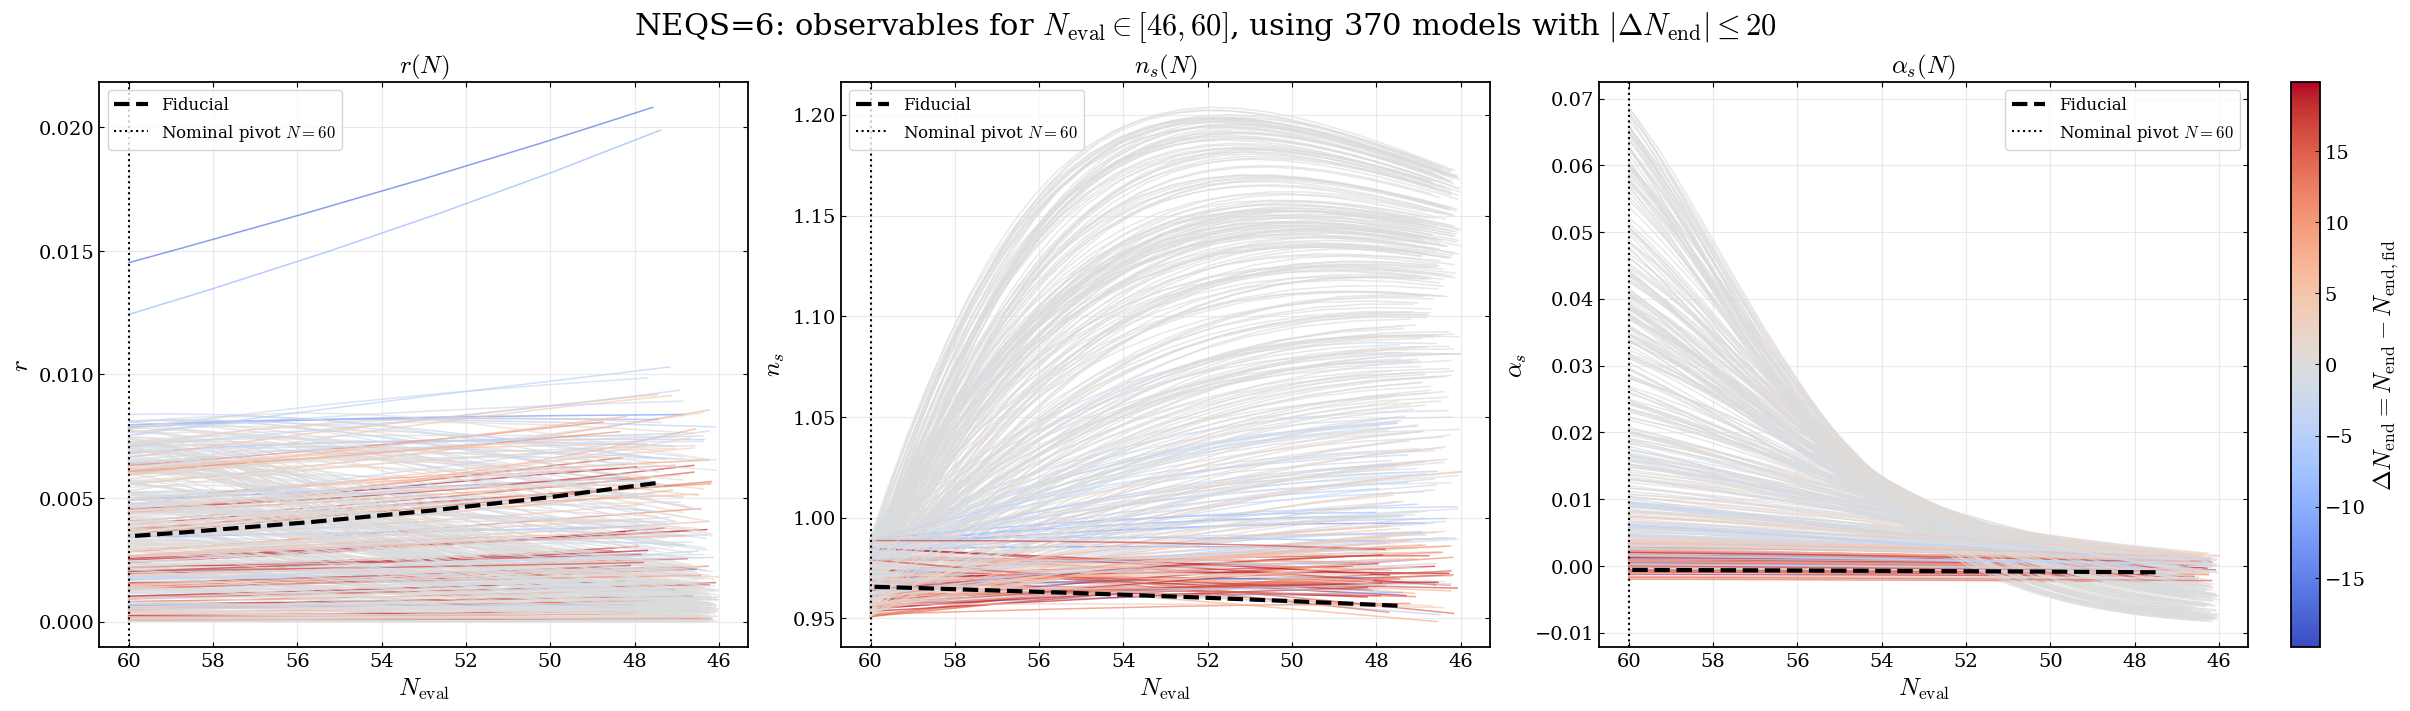

Figure saved to:
paper_higgs_neqs6_observables_N46_to_60_deltaNendmax_20.pdf


In [13]:
# ============================================================
# r(N), n_s(N), and alpha_s(N) for models passing
# |Delta N_end| <= DELTA_N_MAX
#
# First test:
#       45 <= N <= 60
#       -10 <= delta N_piv <= 5
#
# Uses the N points already saved in each path.
# No interpolation.
# No new integration.
# ============================================================


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
NEQS = 6

N_PIVOT_NOMINAL = 60
N_EVAL_MIN = 46.0
N_EVAL_MAX = 60.0

# Constant used in the calcpath observable formulas
c_obs = 0.0814514


# ============================================================
# Observable formulas copied from calcpath.py
# ============================================================
def calc_r(state):
    """
    Tensor-to-scalar ratio from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]

    return (
        16.0
        * epsilon
        * (
            1.0
            - c_obs * (sigma + 2.0 * epsilon)
        )
    )


def calc_ns(state):
    """
    Scalar spectral index from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]
    lambda2 = state[4]

    return (
        1.0
        + sigma
        - (5.0 - 3.0 * c_obs) * epsilon**2
        - 0.25
        * (3.0 - 5.0 * c_obs)
        * epsilon
        * sigma
        + 0.5
        * (3.0 - c_obs)
        * lambda2
    )


def calc_flow_derivatives(state):
    """
    Calculate the flow derivatives needed for alpha_s.

    For NEQS=6, state contains:
        phi, H, epsilon, sigma, lambda2, lambda3
    """
    epsilon = state[2]
    sigma = state[3]
    lambda2 = state[4]
    lambda3 = state[5]

    d_epsilon_dN = (
        epsilon
        * (sigma + 2.0 * epsilon)
    )

    d_sigma_dN = (
        2.0 * lambda2
        - 5.0 * epsilon * sigma
        - 12.0 * epsilon**2
    )

    d_lambda2_dN = (
        0.5 * sigma * lambda2
        + lambda3
    )

    return (
        d_epsilon_dN,
        d_sigma_dN,
        d_lambda2_dN,
    )


def calc_alpha_s(state):
    """
    Running of the scalar spectral index from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]

    (
        d_epsilon_dN,
        d_sigma_dN,
        d_lambda2_dN,
    ) = calc_flow_derivatives(state)

    return -(
        1.0 / (1.0 - epsilon)
    ) * (
        d_sigma_dN

        - 2.0
        * (5.0 - 3.0 * c_obs)
        * epsilon
        * d_epsilon_dN

        - 0.25
        * (3.0 - 5.0 * c_obs)
        * (
            epsilon * d_sigma_dN
            + sigma * d_epsilon_dN
        )

        + 0.5
        * (3.0 - c_obs)
        * d_lambda2_dN
    )


# ============================================================
# Calculate observable curves for one saved model
# ============================================================
def observables_from_saved_path(
    model,
    N_min=N_EVAL_MIN,
    N_max=N_EVAL_MAX,
):
    """
    Load one saved path and calculate r, n_s, and alpha_s
    directly at its saved N values.
    """

    if "path_file" in model:
        path_file = model["path_file"]
        data = np.loadtxt(path_file)

    else:
        data, path_file = load_path_from_outdir(
            model["outdir"],
            NEQS=NEQS,
        )

    data = np.asarray(
        data,
        dtype=float,
    )

    # First NEQS columns are the flow states.
    states = data[:, :NEQS]
    #states 0-6 are col, phi, H, eps, sig, lam2, lam3

    # Column NEQS is N.
    N_values = data[:, NEQS]

    # Keep finite rows inside the uncertainty interval.
    keep = (
        np.isfinite(N_values)
        & np.all(np.isfinite(states), axis=1)
        & (N_values >= N_min)
        & (N_values <= N_max)
    )

    N_values = N_values[keep]
    states = states[keep]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough saved points between "
            f"N={N_min:g} and N={N_max:g}: "
            f"{path_file}"
        )

    
    # Check that the saved N coordinate is monotonic
    dN = np.diff(N_values)

    if np.all(dN >= 0):
        # N is already increasing
        pass

    elif np.all(dN <= 0):
        # N is decreasing, so reverse N and the corresponding states
        N_values = N_values[::-1]
        states = states[::-1]

    else:
        raise ValueError(
            f"N is non-monotonic in path: {path_file}"
        )

    

    N_values = N_values
    states = states

    r_values = np.asarray(
        [calc_r(state) for state in states],
        dtype=float,
    )

    ns_values = np.asarray(
        [calc_ns(state) for state in states],
        dtype=float,
    )

    alpha_values = np.asarray(
        [calc_alpha_s(state) for state in states],
        dtype=float,
    )

    finite_observables = (
        np.isfinite(r_values)
        & np.isfinite(ns_values)
        & np.isfinite(alpha_values)
    )

    N_values = N_values[finite_observables]
    r_values = r_values[finite_observables]
    ns_values = ns_values[finite_observables]
    alpha_values = alpha_values[finite_observables]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough finite observable values: "
            f"{path_file}"
        )

    return {
        "N": N_values,

        "deltaN_piv": (
            N_values - N_PIVOT_NOMINAL
        ),

        "r": r_values,
        "n_s": ns_values,
        "alpha_s": alpha_values,

        "path_file": path_file,
        "outdir": model.get("outdir"),

        "original_N_end": float(
            model["original_N_end"]
        ),

        "deltaN_from_base": float(
            model["deltaN_from_base"]
        ),
    }


# ============================================================
# Process every model passing the Delta N_end cut
# ============================================================
observable_curves = []
observable_failures = []

#enurmerate gives position index and model
#model index for all my passed models
for model_index, model in enumerate(
    passed_models #dictionary of accepted models
):
    try: #will call func for one model
        curves = observables_from_saved_path(
            model
        )

        curves["model_index"] = model_index

        observable_curves.append(
            curves
        )

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:
        observable_failures.append({
            "model_index": model_index,
            "outdir": model.get("outdir"),
            "error": str(exc),
        })


print("\n" + "=" * 70)
print("OBSERVABLE CURVES")
print("=" * 70)

print(
    f"Models passing Delta N_end cut : "
    f"{len(passed_models)}"
)

print(
    f"Observable curves produced     : "
    f"{len(observable_curves)}"
)

print(
    f"Failed observable calculations : "
    f"{len(observable_failures)}"
)

print(
    f"N interval                    : "
    f"[{N_EVAL_MIN:g}, {N_EVAL_MAX:g}]"
)

print(
    f"delta N_piv interval           : "
    f"[{N_EVAL_MIN - N_PIVOT_NOMINAL:g}, "
    f"{N_EVAL_MAX - N_PIVOT_NOMINAL:g}]"
)

print("=" * 70)


if observable_failures:
    print("\nFirst failures:")

    for failure in observable_failures[:10]:
        print(
            f"  model {failure['model_index']}: "
            f"{failure['error']}"
        )


if not observable_curves:
    raise RuntimeError(
        "No observable curves were produced."
    )


# ============================================================
# Fiducial model
# ============================================================
base_model = {
    "outdir": base_row["outdir"],
    "original_N_end": base_N_end,
    "deltaN_from_base": 0.0,
}

base_observables = observables_from_saved_path(
    base_model
)


# ============================================================
# Color the models by Delta N_end
# ============================================================
#Get all end vals make an array
deltaN_end_values = np.asarray(
    [
        curves["deltaN_from_base"]
        for curves in observable_curves
    ],
    dtype=float,
)

#what is largest deltaN?
max_abs_deltaN = np.max(
    np.abs(deltaN_end_values)
)

#if max is zero then make max 1, edge case scenario
if np.isclose(max_abs_deltaN, 0.0):
    max_abs_deltaN = 1.0

norm = mcolors.TwoSlopeNorm(
    vmin=-max_abs_deltaN,
    vcenter=0.0,
    vmax=max_abs_deltaN,
)

cmap = plt.get_cmap(
    "coolwarm"
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_r, ax_ns, ax_alpha = axes


# Plot every accepted model
for curves in observable_curves:
    color = cmap(
        norm(curves["deltaN_from_base"])
    )

    ax_r.plot(
        curves["N"],
        curves["r"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_ns.plot(
        curves["N"],
        curves["n_s"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_alpha.plot(
        curves["N"],
        curves["alpha_s"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )


# Fiducial model
fiducial_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "Fiducial",
    "zorder": 5,
}

ax_r.plot(
    base_observables["N"],
    base_observables["r"],
    **fiducial_style,
)

ax_ns.plot(
    base_observables["N"],
    base_observables["n_s"],
    **fiducial_style,
)

ax_alpha.plot(
    base_observables["N"],
    base_observables["alpha_s"],
    **fiducial_style,
)


# Labels and styling
ax_r.set_title(
    r"$r(N)$"
)

ax_ns.set_title(
    r"$n_s(N)$"
)

ax_alpha.set_title(
    r"$\alpha_s(N)$"
)

ax_r.set_ylabel(
    r"$r$"
)

ax_ns.set_ylabel(
    r"$n_s$"
)

ax_alpha.set_ylabel(
    r"$\alpha_s$"
)


for axis in axes:
    axis.set_xlabel(
        r"$N_{\rm eval}$"
    )

    axis.axvline(
        N_PIVOT_NOMINAL,
        color="black",
        ls=":",
        lw=1.5,
        label=rf"Nominal pivot $N={N_PIVOT_NOMINAL:g}$",
    )

    axis.grid(
        True,
        alpha=0.25,
    )

    # Show N=60 first and N=50 later.
    axis.invert_xaxis()

    axis.legend(
        loc="best"
    )


# Shared colorbar
scalar_mappable = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=axes.ravel().tolist(),
    pad=0.02,
)

colorbar.set_label(
    r"$\Delta N_{\rm end}"
    r"=N_{\rm end}-N_{\rm end,fid}$"
)


fig.suptitle(
    rf"NEQS={NEQS}: observables for "
    rf"$N_{{\rm eval}}\in[{N_EVAL_MIN:g},{N_EVAL_MAX:g}]$, "
    rf"using {len(observable_curves)} models with "
    rf"$|\Delta N_{{\rm end}}|\leq{DELTA_N_MAX:g}$"
)


output_name = (
    f"paper_higgs_neqs{NEQS}_"
    f"observables_N{N_EVAL_MIN:g}_to_{N_EVAL_MAX:g}_"
    f"deltaNendmax_{DELTA_N_MAX:g}.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to:\n{output_name}"
)

# Paper Method: CMB Consistent Models Across $\delta N_{piv}$

The observables most relevant to CMB scales are: $r(N_{eval})$, $n_s(N_{eval})$, $\alpha_s(N_{eval})$. The expectation is that at a particular pivot scale (a pivot corresponding to CMB scales) we can measure these observables and we expect them to be in some range that can be probed by experiments/detectors. Our $\delta N$ should account for uncertainty in truncation. A model can be considered to pass if all three conditions are true together. It probably should not pass if $r$ passes at $N=52$, $n_s$ passes at $N=57$, and $\alpha_s$ passes at $N=59$. They should all pass at $N=52$ or ALL pass at $N=59$.

I may even be able to get several passing observables values at a multiple N values for a model. I think. We are probing here if the model is compatible with the data for some allowed truncation-induced shift.
**Right now, I am going to use fiducial assumed values for CMB passing at the standard pivot scale $k_{piv} = 3.2e-4 hMpc^{-1}$ which corresponds to $N=60$.** I make it so that all three of them must be true.

I am looking at $r(N)$, $n_s(N)$, $\alpha_s(N)$ in the $N_{eval}$ interval $\in [46,60]$ and seeing which of those are within CMB limits. Basically, is there a single $N_eval$ where the model is simultaneously consistent with observables. That shiuld follow because $\delta N$ represents one uncertain pivot location per realization, not three independent ones.


A limitation worth mentioning If two adjacent saved points are far apart in N and the true observable curve dips into the allowed window between them, this method would miss it and mark the model as failing. Is my N resolution fine (dense enough)? Something to consider, but not now.


In [14]:
# ============================================================
# Fiducial CMB expectations
# evaluated at nominal N_piv = 60
# ============================================================

R_FID = 3.4541891486e-03
NS_FID = 9.6567801085e-01
ALPHA_FID = -5.9646914604e-04


# Assumed 2-sigma tolerances
R_DELTA_2SIGMA = 0.002
NS_DELTA_2SIGMA = 0.0055
ALPHA_DELTA_2SIGMA = 0.005


R_MIN_CMB = R_FID - R_DELTA_2SIGMA
R_MAX_CMB = R_FID + R_DELTA_2SIGMA

NS_MIN_CMB = NS_FID - NS_DELTA_2SIGMA
NS_MAX_CMB = NS_FID + NS_DELTA_2SIGMA

ALPHA_MIN_CMB = ALPHA_FID - ALPHA_DELTA_2SIGMA
ALPHA_MAX_CMB = ALPHA_FID + ALPHA_DELTA_2SIGMA

In [15]:
# ============================================================
# Identify CMB-compatible N values for every model
# ============================================================

cmb_passing_models = []
cmb_failing_models = []

for curves in observable_curves:

    r_pass = (
        (curves["r"] >= R_MIN_CMB)
        & (curves["r"] <= R_MAX_CMB)
    )

    ns_pass = (
        (curves["n_s"] >= NS_MIN_CMB)
        & (curves["n_s"] <= NS_MAX_CMB)
    )

    alpha_pass = (
        (curves["alpha_s"] >= ALPHA_MIN_CMB)
        & (curves["alpha_s"] <= ALPHA_MAX_CMB)
    )

    # All three observables must pass at the same N.
    cmb_pass_mask = (
        r_pass
        & ns_pass
        & alpha_pass
    )
    
    #added this
    true_idx = np.where(cmb_pass_mask)[0]

    if len(true_idx) > 0:
        i0 = true_idx[0]
        i1 = true_idx[-1]

        curves["passing_region_is_contiguous"] = bool(
            np.all(cmb_pass_mask[i0:i1+1])
        )
    else:
        curves["passing_region_is_contiguous"] = False



    # Save the mask inside the model dictionary.
    curves["r_pass_mask"] = r_pass
    curves["ns_pass_mask"] = ns_pass
    curves["alpha_pass_mask"] = alpha_pass
    curves["cmb_pass_mask"] = cmb_pass_mask

    # A model passes if at least one saved N point works.
    #We define that below, creating a new key and assigning a value
    #Given also that curves is a reference to one specific dictioning (same one in observable curves)
    #it keeps trck of these values model by model i.i one dict per model
    #now every single dict has been enriched with these new keys
    curves["passes_cmb_somewhere"] = bool(
        np.any(cmb_pass_mask)
    )

    if curves["passes_cmb_somewhere"]:

        passing_N = curves["N"][
            cmb_pass_mask
        ]

        passing_deltaN_piv = curves[
            "deltaN_piv"
        ][cmb_pass_mask]

        curves["N_pass_min"] = float(
            np.min(passing_N)
        )

        curves["N_pass_max"] = float(
            np.max(passing_N)
        )

        curves["deltaN_piv_pass_min"] = float(
            np.min(passing_deltaN_piv)
        )

        curves["deltaN_piv_pass_max"] = float(
            np.max(passing_deltaN_piv)
        )

        curves["number_of_passing_points"] = int(
            np.sum(cmb_pass_mask)
        )

        curves["fraction_of_saved_points_passing"] = float(
            np.mean(cmb_pass_mask)
        )

        cmb_passing_models.append(
            curves
        )

    else: #if it doesnt pass it it set to nan and 0 and appended
        curves["N_pass_min"] = np.nan
        curves["N_pass_max"] = np.nan

        curves["deltaN_piv_pass_min"] = np.nan
        curves["deltaN_piv_pass_max"] = np.nan

        curves["number_of_passing_points"] = 0
        curves["fraction_of_saved_points_passing"] = 0.0

        cmb_failing_models.append(
            curves
        )
        
        

In [17]:
print("\n" + "=" * 72)
print("CMB COMPATIBILITY OVER THE NUISANCE INTERVAL")
print("=" * 72)

print(
    f"Models entering CMB test       : "
    f"{len(observable_curves)}"
)

print(
    f"Models passing at some N       : "
    f"{len(cmb_passing_models)}"
)

print(
    f"Models passing at no saved N   : "
    f"{len(cmb_failing_models)}"
)

print(
    f"r interval                     : "
    f"[{R_MIN_CMB:g}, {R_MAX_CMB:g}]"
)

print(
    f"n_s interval                   : "
    f"[{NS_MIN_CMB:g}, {NS_MAX_CMB:g}]"
)

print(
    f"alpha_s interval               : "
    f"[{ALPHA_MIN_CMB:g}, "
    f"{ALPHA_MAX_CMB:g}]"
)

print("=" * 72)

for curves in cmb_passing_models[:20]:
    print(
        f"model={curves['model_index']:4d} | "
        f"N pass=["
        f"{curves['N_pass_min']:.4f}, "
        f"{curves['N_pass_max']:.4f}] | "
        f"deltaN_piv pass=["
        f"{curves['deltaN_piv_pass_min']:.4f}, "
        f"{curves['deltaN_piv_pass_max']:.4f}] | "
        f"points={curves['number_of_passing_points']}"
    )
    
noncontiguous = [
    c["model_index"]
    for c in cmb_passing_models
    if not c["passing_region_is_contiguous"]
]

print("Non-contiguous passing models:", noncontiguous)
print("Number non-contiguous:", len(noncontiguous))


CMB COMPATIBILITY OVER THE NUISANCE INTERVAL
Models entering CMB test       : 370
Models passing at some N       : 50
Models passing at no saved N   : 320
r interval                     : [0.00145419, 0.00545419]
n_s interval                   : [0.960178, 0.971178]
alpha_s interval               : [-0.00559647, 0.00440353]
model=   0 | N pass=[52.7948, 60.0000] | deltaN_piv pass=[-7.2052, 0.0000] | points=4
model=   1 | N pass=[57.4229, 60.0000] | deltaN_piv pass=[-2.5771, 0.0000] | points=2
model=   4 | N pass=[56.1621, 58.8200] | deltaN_piv pass=[-3.8379, -1.1800] | points=2
model=  18 | N pass=[46.0819, 46.0819] | deltaN_piv pass=[-13.9181, -13.9181] | points=1
model=  37 | N pass=[46.2395, 46.2395] | deltaN_piv pass=[-13.7605, -13.7605] | points=1
model=  51 | N pass=[48.2231, 60.0000] | deltaN_piv pass=[-11.7769, 0.0000] | points=5
model=  53 | N pass=[47.9434, 60.0000] | deltaN_piv pass=[-12.0566, 0.0000] | points=5
model=  55 | N pass=[55.6252, 58.1215] | deltaN_piv pass=[-4.3

I am reading this as, given a model 0 for instance, the saved trajectory path that passes all three CMB  observable cuts are in between N=52 and 70, no other saved N location in the tested interval satisfy all three cuts simultaneously. The $\delta N$ for that associated model at 52.7948 is shifted from the **nominal** model by about -7.2052 e-folds and it contains 17 saved N-location that satisfy all three cuts simultaneously (points). Note also some of the models here, hit the upper boundary at $N=70$ so, we do not actually know 100% whether the allowed region *ends* at 70 or would continue beyond that, we just know the upper edge. That is a limitation. There are also some point cases, so only one N value has observables near fiducial values.



In [23]:
# ============================================================
# Simple pass/fail and continuity summary for every model
# ============================================================

print("\n" + "=" * 90)
print("MODEL CMB PASSING SUMMARY")
print("=" * 90)

for curves in observable_curves:

    model_index = curves["model_index"]
    pass_mask = curves["cmb_pass_mask"]

    passing_N = curves["N"][pass_mask]
    passing_deltaN = curves["deltaN_piv"][pass_mask]

    passing_indices = np.where(pass_mask)[0] #gives me the position where compound cut passes

    # --------------------------------------------------------
    # Case 1: model does not pass anywhere
    # --------------------------------------------------------
    if len(passing_indices) == 0:
        curves["is_continuous"] = False

        print(
            f"model={model_index:4d} | "
            f"PASS=False | "
            f"no allowed N values"
        )

        continue

    # --------------------------------------------------------
    # Case 2: model passes at one or more saved N values
    # --------------------------------------------------------
    is_continuous = bool(
        np.all(
            np.diff(passing_indices) == 1
        )
    ) #np. diff gives me gaps between consecutive passsing positions
    #if every gap is 1, every passing point is immediatley followed by another passing point, aka no hole
    curves["is_continuous"] = is_continuous 

    N_min = float(np.min(passing_N))
    N_max = float(np.max(passing_N))

    deltaN_min = float(np.min(passing_deltaN))
    deltaN_max = float(np.max(passing_deltaN))
    

    print(
        f"model={model_index:4d} | "
        f"PASS=True | "
        f"N=[{N_min:.4f}, {N_max:.4f}] | "
        f"deltaN_piv=[{deltaN_min:.4f}, {deltaN_max:.4f}] | "
        f"points={len(passing_N):2d} | "
        f"continuous={is_continuous}"
    )

print("=" * 90)




# ============================================================
# Prepare endpoint DataFrame for spectrum calculations
# ============================================================

deltaN_ranges_df = cmb_model_summary.rename(
    columns={
        "deltaN_piv_pass_min": "deltaN_min",
        "deltaN_piv_pass_max": "deltaN_max",
    }
).copy()

deltaN_ranges_df = deltaN_ranges_df.loc[
    deltaN_ranges_df["passes_cmb_somewhere"]
].copy()

deltaN_ranges_df = deltaN_ranges_df.reset_index(
    drop=True
)

continuity_lookup = {
    curves["model_index"]: curves["is_continuous"]
    for curves in observable_curves
}

deltaN_ranges_df["is_continuous"] = deltaN_ranges_df["model_index"].map(continuity_lookup)


print(
    deltaN_ranges_df[
        [
            "model_index",
            "deltaN_min",
            "deltaN_max",
            "is_continuous",
            "outdir",
        ]
    ].head()
)


MODEL CMB PASSING SUMMARY
model=   0 | PASS=True | N=[52.7948, 60.0000] | deltaN_piv=[-7.2052, 0.0000] | points= 4 | continuous=True
model=   1 | PASS=True | N=[57.4229, 60.0000] | deltaN_piv=[-2.5771, 0.0000] | points= 2 | continuous=True
model=   2 | PASS=False | no allowed N values
model=   3 | PASS=False | no allowed N values
model=   4 | PASS=True | N=[56.1621, 58.8200] | deltaN_piv=[-3.8379, -1.1800] | points= 2 | continuous=True
model=   5 | PASS=False | no allowed N values
model=   6 | PASS=False | no allowed N values
model=   7 | PASS=False | no allowed N values
model=   8 | PASS=False | no allowed N values
model=   9 | PASS=False | no allowed N values
model=  10 | PASS=False | no allowed N values
model=  11 | PASS=False | no allowed N values
model=  12 | PASS=False | no allowed N values
model=  13 | PASS=False | no allowed N values
model=  14 | PASS=False | no allowed N values
model=  15 | PASS=False | no allowed N values
model=  16 | PASS=False | no allowed N values
model= 

# Plot 5: Mermaid Observable Curves


OBSERVABLE CURVES
Models passing Delta N_end cut : 370
Observable curves produced     : 370
Failed observable calculations : 0
N interval                    : [46, 60]
delta N_piv interval           : [-14, 0]

CMB COMPATIBILITY OVER THE NUISANCE INTERVAL
Models entering CMB test       : 370
Models passing at some N       : 50
Models passing at no saved N   : 320
r interval                     : [0.00145419, 0.00545419]
n_s interval                   : [0.960178, 0.971178]
alpha_s interval               : [-0.00559647, 0.00440353]
model=   0 | N pass=[52.7948, 60.0000] | deltaN_piv pass=[-7.2052, 0.0000] | points=4
model=   1 | N pass=[57.4229, 60.0000] | deltaN_piv pass=[-2.5771, 0.0000] | points=2
model=   4 | N pass=[56.1621, 58.8200] | deltaN_piv pass=[-3.8379, -1.1800] | points=2
model=  18 | N pass=[46.0819, 46.0819] | deltaN_piv pass=[-13.9181, -13.9181] | points=1
model=  37 | N pass=[46.2395, 46.2395] | deltaN_piv pass=[-13.7605, -13.7605] | points=1
model=  51 | N pass=[48.2

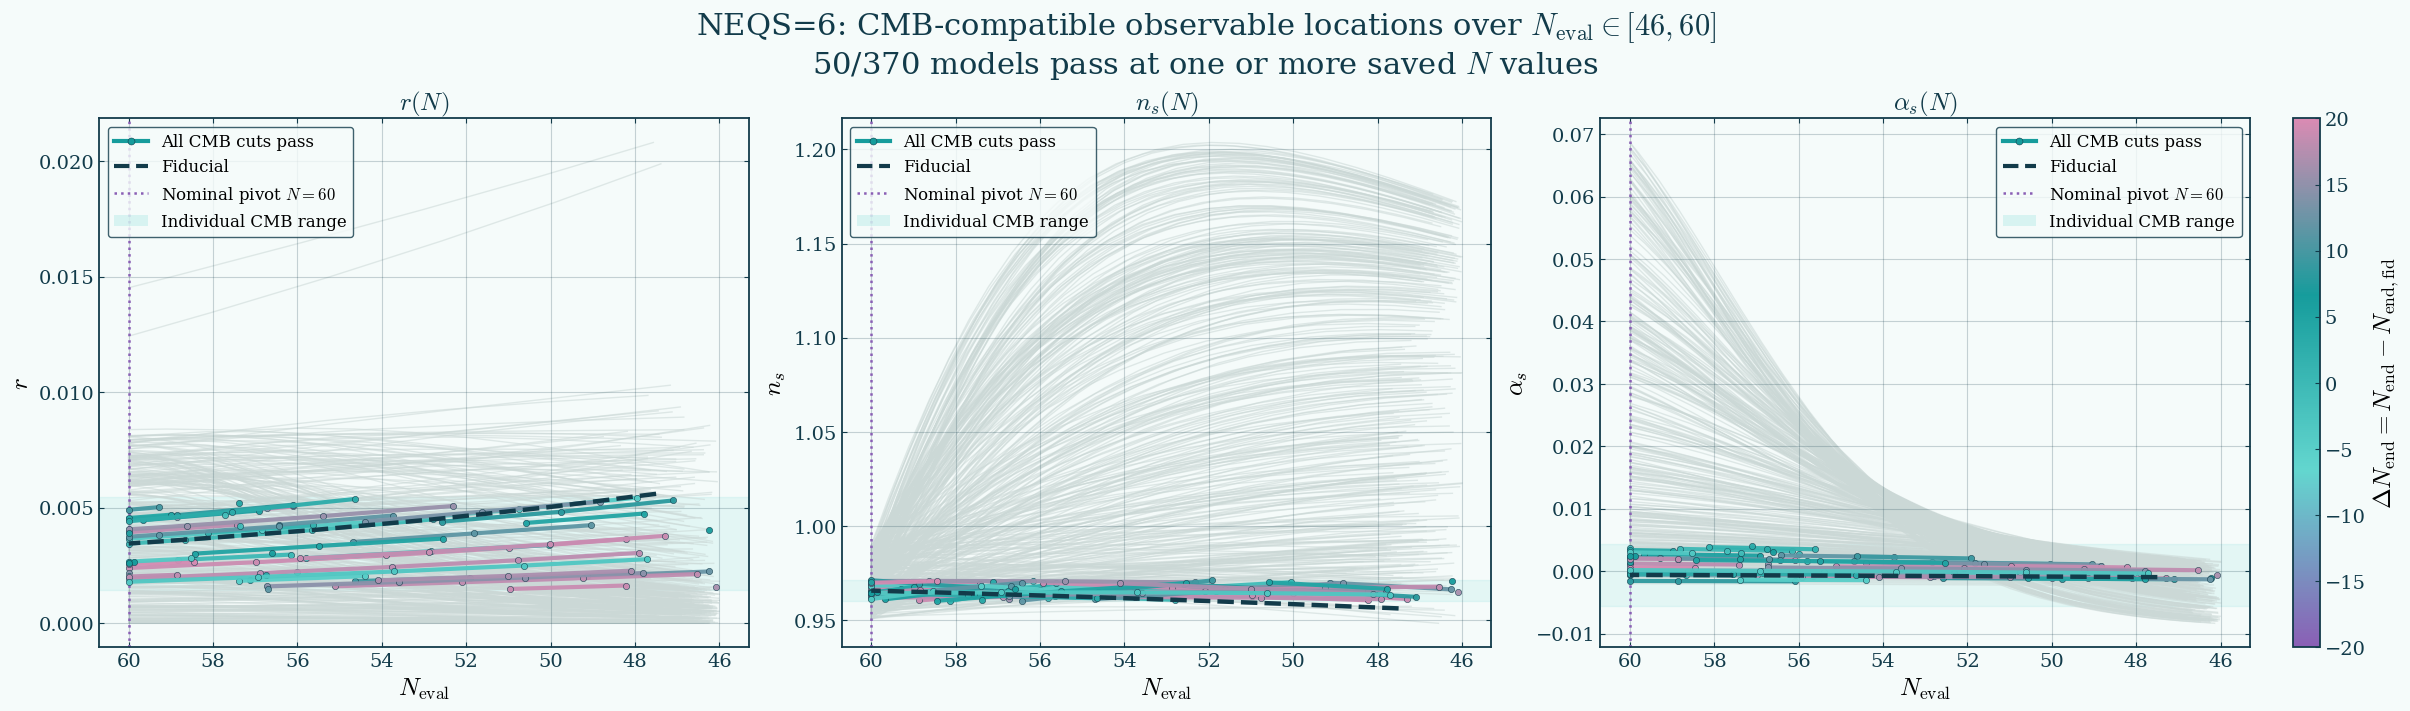

Figure saved to:
paper_higgs_neqs6_cmb_compatible_observables_N46_to_60_deltaNendmax_20.pdf

CMB model summary:
   model_index                                             outdir  \
0            0  /Users/epmeador/Desktop/research/rwarthur/infl...   
1            1  /Users/epmeador/Desktop/research/rwarthur/infl...   
2            2  /Users/epmeador/Desktop/research/rwarthur/infl...   
3            3  /Users/epmeador/Desktop/research/rwarthur/infl...   
4            4  /Users/epmeador/Desktop/research/rwarthur/infl...   

   deltaN_from_base  passes_cmb_somewhere  N_pass_min  N_pass_max  \
0          0.000000                  True   52.794833   60.000000   
1         18.118784                  True   57.422853   60.000000   
2         -2.212253                 False         NaN         NaN   
3         -4.462020                 False         NaN         NaN   
4         -0.008239                  True   56.162138   58.819969   

   deltaN_piv_pass_min  deltaN_piv_pass_max  number_of_pas

In [25]:
# ============================================================
# r(N), n_s(N), and alpha_s(N) for models passing
# |Delta N_end| <= DELTA_N_MAX
#
# One-sided nuisance interval:
#       50 <= N_eval <= 60
#       -10 <= delta N_piv <= 0
#
# A model is CMB-compatible if there is at least one saved N
# where r, n_s, and alpha_s all pass simultaneously.
#
# Uses saved path points directly:
#       no interpolation
#       no new integration

from matplotlib.patches import Patch


# ============================================================
# Calculate observable curves for one saved model
# ============================================================
def observables_from_saved_path(
    model,
    N_min=N_EVAL_MIN,
    N_max=N_EVAL_MAX,
):
    """
    Load one saved trajectory and calculate r, n_s, and alpha_s
    directly at its saved N values.

    No interpolation is performed.
    """

    if "path_file" in model:
        path_file = model["path_file"]
        data = np.loadtxt(path_file)

    elif "outdir" in model:
        data, path_file = load_path_from_outdir(
            model["outdir"],
            NEQS=NEQS,
        )

    else:
        raise KeyError(
            "Model contains neither 'path_file' nor 'outdir'."
        )

    data = np.asarray(
        data,
        dtype=float,
    )

    if data.ndim != 2:
        raise ValueError(
            f"Path data must be two-dimensional: {path_file}"
        )

    if data.shape[1] < NEQS + 1:
        raise ValueError(
            f"Path has {data.shape[1]} columns, but at least "
            f"{NEQS + 1} are required: {path_file}"
        )

    # First NEQS columns contain:
    # phi, H, epsilon, sigma, lambda2, lambda3
    states = data[:, :NEQS]

    # Column NEQS contains N
    N_values = data[:, NEQS]

    # Keep only finite states inside the nuisance interval
    keep = (
        np.isfinite(N_values)
        & np.all(
            np.isfinite(states),
            axis=1,
        )
        & (N_values >= N_min)
        & (N_values <= N_max)
    )

    N_values = N_values[keep]
    states = states[keep]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough saved points between "
            f"N={N_min:g} and N={N_max:g}: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Verify that N is monotonic
    # --------------------------------------------------------
    dN = np.diff(N_values)

    if np.all(dN >= 0):
        # Already increasing
        pass

    elif np.all(dN <= 0):
        # Decreasing, so reverse both N and the corresponding states
        N_values = N_values[::-1]
        states = states[::-1]

    else:
        raise ValueError(
            f"N is non-monotonic in path: {path_file}"
        )

    # Duplicate N values are harmless for plotting, but print
    # a warning because they may matter for later interpolation.
    if np.any(np.diff(N_values) == 0):
        print(
            f"WARNING: duplicate N values found in: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Calculate observables at every saved state
    # --------------------------------------------------------
    r_values = np.asarray(
        [
            calc_r(state)
            for state in states
        ],
        dtype=float,
    )

    ns_values = np.asarray(
        [
            calc_ns(state)
            for state in states
        ],
        dtype=float,
    )

    alpha_values = np.asarray(
        [
            calc_alpha_s(state)
            for state in states
        ],
        dtype=float,
    )

    finite_observables = (
        np.isfinite(r_values)
        & np.isfinite(ns_values)
        & np.isfinite(alpha_values)
    )

    N_values = N_values[finite_observables]
    r_values = r_values[finite_observables]
    ns_values = ns_values[finite_observables]
    alpha_values = alpha_values[finite_observables]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough finite observable values: "
            f"{path_file}"
        )

    return {
        "N": N_values,

        "deltaN_piv": (
            N_values
            - N_PIVOT_NOMINAL
        ),

        "r": r_values,
        "n_s": ns_values,
        "alpha_s": alpha_values,

        "path_file": path_file,
        "outdir": model.get(
            "outdir"
        ),

        "original_N_end": float(
            model["original_N_end"]
        ),

        "deltaN_from_base": float(
            model["deltaN_from_base"]
        ),
    }


# ============================================================
# Process every model passing the Delta N_end cut
# ============================================================
observable_curves = []
observable_failures = []

for model_index, model in enumerate(
    passed_models
):
    try:
        curves = observables_from_saved_path(
            model
        )

        curves["model_index"] = model_index

        observable_curves.append(
            curves
        )

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:

        observable_failures.append({
            "model_index": model_index,
            "outdir": model.get(
                "outdir"
            ),
            "error": str(exc),
        })


print("\n" + "=" * 72)
print("OBSERVABLE CURVES")
print("=" * 72)

print(
    f"Models passing Delta N_end cut : "
    f"{len(passed_models)}"
)

print(
    f"Observable curves produced     : "
    f"{len(observable_curves)}"
)

print(
    f"Failed observable calculations : "
    f"{len(observable_failures)}"
)

print(
    f"N interval                    : "
    f"[{N_EVAL_MIN:g}, {N_EVAL_MAX:g}]"
)

print(
    f"delta N_piv interval           : "
    f"[{N_EVAL_MIN - N_PIVOT_NOMINAL:g}, "
    f"{N_EVAL_MAX - N_PIVOT_NOMINAL:g}]"
)

print("=" * 72)


if observable_failures:
    print("\nFirst failures:")

    for failure in observable_failures[:10]:
        print(
            f"  model {failure['model_index']}: "
            f"{failure['error']}"
        )


if not observable_curves:
    raise RuntimeError(
        "No observable curves were produced."
    )


# ============================================================
# Identify CMB-compatible N locations
# ============================================================
cmb_passing_models = []
cmb_failing_models = []

for curves in observable_curves:

    # Individual observable masks
    r_pass_mask = (
        (curves["r"] >= R_MIN_CMB)
        & (curves["r"] <= R_MAX_CMB)
    )

    ns_pass_mask = (
        (curves["n_s"] >= NS_MIN_CMB)
        & (curves["n_s"] <= NS_MAX_CMB)
    )

    alpha_pass_mask = (
        (curves["alpha_s"] >= ALPHA_MIN_CMB)
        & (curves["alpha_s"] <= ALPHA_MAX_CMB)
    )

    # All observables must pass at the same saved N point
    cmb_pass_mask = (
        r_pass_mask
        & ns_pass_mask
        & alpha_pass_mask
    )

    # Store all masks in the model dictionary
    curves["r_pass_mask"] = r_pass_mask
    curves["ns_pass_mask"] = ns_pass_mask
    curves["alpha_pass_mask"] = alpha_pass_mask
    curves["cmb_pass_mask"] = cmb_pass_mask

    curves["passes_cmb_somewhere"] = bool(
        np.any(cmb_pass_mask)
    )

    if curves["passes_cmb_somewhere"]:

        passing_N = curves["N"][
            cmb_pass_mask
        ]

        passing_deltaN_piv = curves[
            "deltaN_piv"
        ][cmb_pass_mask]

        curves["N_pass_min"] = float(
            np.min(passing_N)
        )

        curves["N_pass_max"] = float(
            np.max(passing_N)
        )

        curves["deltaN_piv_pass_min"] = float(
            np.min(passing_deltaN_piv)
        )

        curves["deltaN_piv_pass_max"] = float(
            np.max(passing_deltaN_piv)
        )

        curves["number_of_passing_points"] = int(
            np.sum(cmb_pass_mask)
        )

        curves["fraction_of_saved_points_passing"] = float(
            np.mean(cmb_pass_mask)
        )

        cmb_passing_models.append(
            curves
        )

    else:
        curves["N_pass_min"] = np.nan
        curves["N_pass_max"] = np.nan

        curves["deltaN_piv_pass_min"] = np.nan
        curves["deltaN_piv_pass_max"] = np.nan

        curves["number_of_passing_points"] = 0
        curves["fraction_of_saved_points_passing"] = 0.0

        cmb_failing_models.append(
            curves
        )


# ============================================================
# CMB compatibility summary
# ============================================================
print("\n" + "=" * 72)
print("CMB COMPATIBILITY OVER THE NUISANCE INTERVAL")
print("=" * 72)

print(
    f"Models entering CMB test       : "
    f"{len(observable_curves)}"
)

print(
    f"Models passing at some N       : "
    f"{len(cmb_passing_models)}"
)

print(
    f"Models passing at no saved N   : "
    f"{len(cmb_failing_models)}"
)

print(
    f"r interval                     : "
    f"[{R_MIN_CMB:g}, {R_MAX_CMB:g}]"
)

print(
    f"n_s interval                   : "
    f"[{NS_MIN_CMB:g}, {NS_MAX_CMB:g}]"
)

print(
    f"alpha_s interval               : "
    f"[{ALPHA_MIN_CMB:g}, "
    f"{ALPHA_MAX_CMB:g}]"
)

print("=" * 72)


# Print the first 20 passing models
for curves in cmb_passing_models[:20]:

    print(
        f"model={curves['model_index']:4d} | "
        f"N pass=["
        f"{curves['N_pass_min']:.4f}, "
        f"{curves['N_pass_max']:.4f}] | "
        f"deltaN_piv pass=["
        f"{curves['deltaN_piv_pass_min']:.4f}, "
        f"{curves['deltaN_piv_pass_max']:.4f}] | "
        f"points={curves['number_of_passing_points']}"
    )


# ============================================================
# Fiducial model
# ============================================================
base_model = {
    "outdir": base_row["outdir"],
    "original_N_end": base_N_end,
    "deltaN_from_base": 0.0,
}

base_observables = observables_from_saved_path(
    base_model
)

#This part is for the plotting scheme
# ============================================================
# Mermaid-themed plot colors
# ============================================================
mermaid_dark = "#123B4A"
mermaid_teal = "#169C9C"
mermaid_aqua = "#63D6CF"
mermaid_purple = "#8A5FB5"
mermaid_pink = "#D98BB3"
mermaid_sand = "#E8DCC4"
mermaid_gray = "#CBD8D6"
mermaid_background = "#F5FBFA"

# The color of each passing trajectory still represents
# Delta N_end relative to the fiducial model.
#LinearSegmentedColormap.from_list: 
#creates a custom, smoothly-varying color map from a list of colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "mermaid",
    [
        mermaid_purple,
        mermaid_aqua,
        mermaid_teal,
        mermaid_pink,
    ],
)

# Fixed limits make the color meaning consistent between plots
norm = mcolors.TwoSlopeNorm(
    vmin=-DELTA_N_MAX,
    vcenter=0.0,
    vmax=DELTA_N_MAX,
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_r, ax_ns, ax_alpha = axes

#patch.set_facecolor() is a Matplotlib method used to change the background fill color of a 2D artist object
fig.patch.set_facecolor(
    mermaid_background
)

for axis in axes:
    axis.set_facecolor(
        mermaid_background
    )


# ------------------------------------------------------------
# Individual CMB allowed bands
# ------------------------------------------------------------
ax_r.axhspan(
    R_MIN_CMB,
    R_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_ns.axhspan(
    NS_MIN_CMB,
    NS_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_alpha.axhspan(
    ALPHA_MIN_CMB,
    ALPHA_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)


# ------------------------------------------------------------
# Plot every complete trajectory faintly
# ------------------------------------------------------------
for curves in observable_curves:

    ax_r.plot(
        curves["N"],
        curves["r"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )

    ax_ns.plot(
        curves["N"],
        curves["n_s"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )

    ax_alpha.plot(
        curves["N"],
        curves["alpha_s"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )


# ------------------------------------------------------------
# Highlight saved N locations where all cuts pass together
# ------------------------------------------------------------
for curves in cmb_passing_models:

    pass_mask = curves["cmb_pass_mask"]

    color = cmap(
        norm(
            curves["deltaN_from_base"]
        )
    )

    # Failing locations become NaN.
    # Matplotlib only draws passing portions.
    r_passing = np.where(
        pass_mask,
        curves["r"],
        np.nan,
    )

    ns_passing = np.where(
        pass_mask,
        curves["n_s"],
        np.nan,
    )

    alpha_passing = np.where(
        pass_mask,
        curves["alpha_s"],
        np.nan,
    )

    ax_r.plot(
        curves["N"],
        r_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_ns.plot(
        curves["N"],
        ns_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_alpha.plot(
        curves["N"],
        alpha_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )


# ------------------------------------------------------------
# Fiducial model
# ------------------------------------------------------------
fiducial_style = {
    "color": mermaid_dark,
    "lw": 3.2,
    "ls": "--",
    "zorder": 5,
}

ax_r.plot(
    base_observables["N"],
    base_observables["r"],
    **fiducial_style,
)

ax_ns.plot(
    base_observables["N"],
    base_observables["n_s"],
    **fiducial_style,
)

ax_alpha.plot(
    base_observables["N"],
    base_observables["alpha_s"],
    **fiducial_style,
)


# ============================================================
# Titles and axis labels
# ============================================================
ax_r.set_title(
    r"$r(N)$",
    color=mermaid_dark,
)

ax_ns.set_title(
    r"$n_s(N)$",
    color=mermaid_dark,
)

ax_alpha.set_title(
    r"$\alpha_s(N)$",
    color=mermaid_dark,
)

ax_r.set_ylabel(
    r"$r$"
)

ax_ns.set_ylabel(
    r"$n_s$"
)

ax_alpha.set_ylabel(
    r"$\alpha_s$"
)


# ============================================================
# Custom legend
# ============================================================
passing_handle = Line2D(
    [0],
    [0],
    color=mermaid_teal,
    lw=3.0,
    marker="o",
    markersize=5,
    markeredgecolor=mermaid_dark,
    markeredgewidth=0.4,
    label="All CMB cuts pass",
)

fiducial_handle = Line2D(
    [0],
    [0],
    color=mermaid_dark,
    lw=3.0,
    ls="--",
    label="Fiducial",
)

pivot_handle = Line2D(
    [0],
    [0],
    color=mermaid_purple,
    lw=1.8,
    ls=":",
    label=rf"Nominal pivot $N={N_PIVOT_NOMINAL:g}$",
)

cmb_band_handle = Patch(
    facecolor=mermaid_aqua,
    alpha=0.20,
    label="Individual CMB range",
)


# ============================================================
# Shared axis styling
# ============================================================
for axis in axes:

    axis.set_xlabel(
        r"$N_{\rm eval}$"
    )

    axis.axvline(
        N_PIVOT_NOMINAL,
        color=mermaid_purple,
        ls=":",
        lw=1.8,
        zorder=2,
    )

    axis.grid(
        True,
        alpha=0.22,
        color=mermaid_dark,
    )

    # N decreases toward the end of inflation.
    # Display N=60 on the left and N=50 on the right.
    axis.invert_xaxis()

    axis.tick_params(
        colors=mermaid_dark
    )

    for spine in axis.spines.values():
        spine.set_color(
            mermaid_dark
        )

    axis.legend(
        handles=[
            passing_handle,
            fiducial_handle,
            pivot_handle,
            cmb_band_handle,
        ],
        loc="best",
        frameon=True,
        facecolor=mermaid_background,
        edgecolor=mermaid_dark,
    )


# ============================================================
# Shared Delta N_end colorbar
# ============================================================
scalar_mappable = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=axes.ravel().tolist(),
    pad=0.02,
)

colorbar.set_label(
    r"$\Delta N_{\rm end}"
    r"=N_{\rm end}-N_{\rm end,fid}$"
)

colorbar.ax.tick_params(
    colors=mermaid_dark
)

colorbar.outline.set_edgecolor(
    mermaid_dark
)


# ============================================================
# Figure title and output
# ============================================================
fig.suptitle(
    rf"NEQS={NEQS}: CMB-compatible observable locations over "
    rf"$N_{{\rm eval}}\in[{N_EVAL_MIN:g},{N_EVAL_MAX:g}]$"
    "\n"
    rf"{len(cmb_passing_models)}/{len(observable_curves)} models "
    rf"pass at one or more saved $N$ values",
    color=mermaid_dark,
)


output_name = (
    f"paper_higgs_neqs{NEQS}_"
    f"cmb_compatible_observables_"
    f"N{N_EVAL_MIN:g}_to_{N_EVAL_MAX:g}_"
    f"deltaNendmax_{DELTA_N_MAX:g}.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(
    f"Figure saved to:\n{output_name}"
)


# ============================================================
# Build a model-level CMB summary DataFrame
# ============================================================
cmb_summary_records = []

for curves in observable_curves:

    cmb_summary_records.append({
        "model_index": curves["model_index"],

        "outdir": curves["outdir"],

        "deltaN_from_base": (
            curves["deltaN_from_base"]
        ),

        "passes_cmb_somewhere": (
            curves["passes_cmb_somewhere"]
        ),

        "N_pass_min": curves["N_pass_min"],
        "N_pass_max": curves["N_pass_max"],

        "deltaN_piv_pass_min": (
            curves["deltaN_piv_pass_min"]
        ),

        "deltaN_piv_pass_max": (
            curves["deltaN_piv_pass_max"]
        ),

        "number_of_passing_points": (
            curves["number_of_passing_points"]
        ),

        "fraction_of_saved_points_passing": (
            curves[
                "fraction_of_saved_points_passing"
            ]
        ),
    })


cmb_model_summary = pd.DataFrame(
    cmb_summary_records
)

print("\nCMB model summary:")
print(
    cmb_model_summary.head()
)


# Optional: display only models that pass somewhere
cmb_passing_summary = cmb_model_summary.loc[
    cmb_model_summary[
        "passes_cmb_somewhere"
    ]
].copy()

print(
    f"\nPassing model rows: "
    f"{len(cmb_passing_summary)}"
)


# Plot 6: Valid CMB Models Observable Curves


OBSERVABLE CURVES
Models passing Delta N_end cut : 370
Observable curves produced     : 370
Failed observable calculations : 0
N interval                    : [46, 60]
delta N_piv interval           : [-14, 0]

CMB COMPATIBILITY OVER THE NUISANCE INTERVAL
Models entering CMB test       : 370
Models passing at some N       : 50
Models passing at no saved N   : 320
r interval                     : [0.00145419, 0.00545419]
n_s interval                   : [0.960178, 0.971178]
alpha_s interval               : [-0.00559647, 0.00440353]
model=   0 | N pass=[52.7948, 60.0000] | deltaN_piv pass=[-7.2052, 0.0000] | points=4
model=   1 | N pass=[57.4229, 60.0000] | deltaN_piv pass=[-2.5771, 0.0000] | points=2
model=   4 | N pass=[56.1621, 58.8200] | deltaN_piv pass=[-3.8379, -1.1800] | points=2
model=  18 | N pass=[46.0819, 46.0819] | deltaN_piv pass=[-13.9181, -13.9181] | points=1
model=  37 | N pass=[46.2395, 46.2395] | deltaN_piv pass=[-13.7605, -13.7605] | points=1
model=  51 | N pass=[48.2

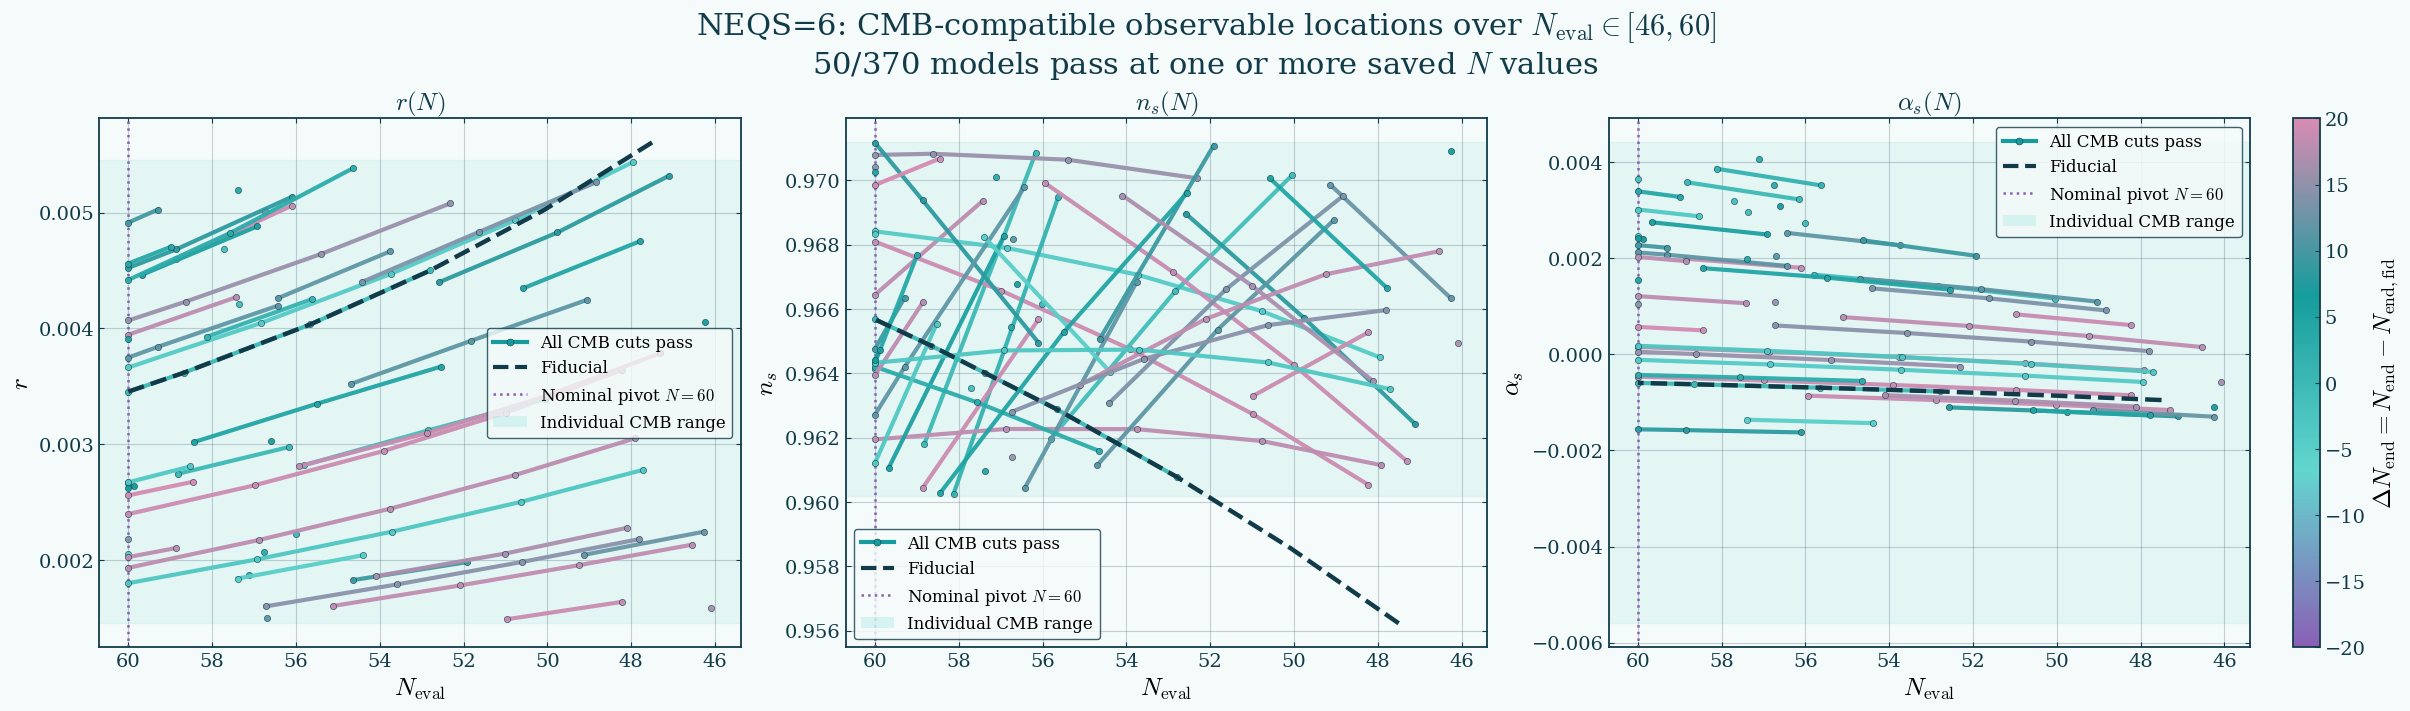

Figure saved to:
paper_higgs_neqs6_cmb_compatible_observables_N46_to_60_deltaNendmax_20.pdf

CMB model summary:
   model_index                                             outdir  \
0            0  /Users/epmeador/Desktop/research/rwarthur/infl...   
1            1  /Users/epmeador/Desktop/research/rwarthur/infl...   
2            2  /Users/epmeador/Desktop/research/rwarthur/infl...   
3            3  /Users/epmeador/Desktop/research/rwarthur/infl...   
4            4  /Users/epmeador/Desktop/research/rwarthur/infl...   

   deltaN_from_base  passes_cmb_somewhere  N_pass_min  N_pass_max  \
0          0.000000                  True   52.794833   60.000000   
1         18.118784                  True   57.422853   60.000000   
2         -2.212253                 False         NaN         NaN   
3         -4.462020                 False         NaN         NaN   
4         -0.008239                  True   56.162138   58.819969   

   deltaN_piv_pass_min  deltaN_piv_pass_max  number_of_pas

In [26]:
# ============================================================
# r(N), n_s(N), and alpha_s(N) for models passing
# |Delta N_end| <= DELTA_N_MAX
#
# One-sided nuisance interval:
#       50 <= N_eval <= 60
#       -10 <= delta N_piv <= 0
#
# A model is CMB-compatible if there is at least one saved N
# where r, n_s, and alpha_s all pass simultaneously.
#
# Uses saved path points directly:
#       no interpolation
#       no new integration

from matplotlib.patches import Patch


# ============================================================
# Calculate observable curves for one saved model
# ============================================================
def observables_from_saved_path(
    model,
    N_min=N_EVAL_MIN,
    N_max=N_EVAL_MAX,
):
    """
    Load one saved trajectory and calculate r, n_s, and alpha_s
    directly at its saved N values.

    No interpolation is performed.
    """

    if "path_file" in model:
        path_file = model["path_file"]
        data = np.loadtxt(path_file)

    elif "outdir" in model:
        data, path_file = load_path_from_outdir(
            model["outdir"],
            NEQS=NEQS,
        )

    else:
        raise KeyError(
            "Model contains neither 'path_file' nor 'outdir'."
        )

    data = np.asarray(
        data,
        dtype=float,
    )

    if data.ndim != 2:
        raise ValueError(
            f"Path data must be two-dimensional: {path_file}"
        )

    if data.shape[1] < NEQS + 1:
        raise ValueError(
            f"Path has {data.shape[1]} columns, but at least "
            f"{NEQS + 1} are required: {path_file}"
        )

    # First NEQS columns contain:
    # phi, H, epsilon, sigma, lambda2, lambda3
    states = data[:, :NEQS]

    # Column NEQS contains N
    N_values = data[:, NEQS]

    # Keep only finite states inside the nuisance interval
    keep = (
        np.isfinite(N_values)
        & np.all(
            np.isfinite(states),
            axis=1,
        )
        & (N_values >= N_min)
        & (N_values <= N_max)
    )

    N_values = N_values[keep]
    states = states[keep]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough saved points between "
            f"N={N_min:g} and N={N_max:g}: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Verify that N is monotonic
    # --------------------------------------------------------
    dN = np.diff(N_values)

    if np.all(dN >= 0):
        # Already increasing
        pass

    elif np.all(dN <= 0):
        # Decreasing, so reverse both N and the corresponding states
        N_values = N_values[::-1]
        states = states[::-1]

    else:
        raise ValueError(
            f"N is non-monotonic in path: {path_file}"
        )

    # Duplicate N values are harmless for plotting, but print
    # a warning because they may matter for later interpolation.
    if np.any(np.diff(N_values) == 0):
        print(
            f"WARNING: duplicate N values found in: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Calculate observables at every saved state
    # --------------------------------------------------------
    r_values = np.asarray(
        [
            calc_r(state)
            for state in states
        ],
        dtype=float,
    )

    ns_values = np.asarray(
        [
            calc_ns(state)
            for state in states
        ],
        dtype=float,
    )

    alpha_values = np.asarray(
        [
            calc_alpha_s(state)
            for state in states
        ],
        dtype=float,
    )

    finite_observables = (
        np.isfinite(r_values)
        & np.isfinite(ns_values)
        & np.isfinite(alpha_values)
    )

    N_values = N_values[finite_observables]
    r_values = r_values[finite_observables]
    ns_values = ns_values[finite_observables]
    alpha_values = alpha_values[finite_observables]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough finite observable values: "
            f"{path_file}"
        )

    return {
        "N": N_values,

        "deltaN_piv": (
            N_values
            - N_PIVOT_NOMINAL
        ),

        "r": r_values,
        "n_s": ns_values,
        "alpha_s": alpha_values,

        "path_file": path_file,
        "outdir": model.get(
            "outdir"
        ),

        "original_N_end": float(
            model["original_N_end"]
        ),

        "deltaN_from_base": float(
            model["deltaN_from_base"]
        ),
    }


# ============================================================
# Process every model passing the Delta N_end cut
# ============================================================
observable_curves = []
observable_failures = []

for model_index, model in enumerate(
    passed_models
):
    try:
        curves = observables_from_saved_path(
            model
        )

        curves["model_index"] = model_index

        observable_curves.append(
            curves
        )

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:

        observable_failures.append({
            "model_index": model_index,
            "outdir": model.get(
                "outdir"
            ),
            "error": str(exc),
        })


print("\n" + "=" * 72)
print("OBSERVABLE CURVES")
print("=" * 72)

print(
    f"Models passing Delta N_end cut : "
    f"{len(passed_models)}"
)

print(
    f"Observable curves produced     : "
    f"{len(observable_curves)}"
)

print(
    f"Failed observable calculations : "
    f"{len(observable_failures)}"
)

print(
    f"N interval                    : "
    f"[{N_EVAL_MIN:g}, {N_EVAL_MAX:g}]"
)

print(
    f"delta N_piv interval           : "
    f"[{N_EVAL_MIN - N_PIVOT_NOMINAL:g}, "
    f"{N_EVAL_MAX - N_PIVOT_NOMINAL:g}]"
)

print("=" * 72)


if observable_failures:
    print("\nFirst failures:")

    for failure in observable_failures[:10]:
        print(
            f"  model {failure['model_index']}: "
            f"{failure['error']}"
        )


if not observable_curves:
    raise RuntimeError(
        "No observable curves were produced."
    )


# ============================================================
# Identify CMB-compatible N locations
# ============================================================
cmb_passing_models = []
cmb_failing_models = []

for curves in observable_curves:

    # Individual observable masks
    r_pass_mask = (
        (curves["r"] >= R_MIN_CMB)
        & (curves["r"] <= R_MAX_CMB)
    )

    ns_pass_mask = (
        (curves["n_s"] >= NS_MIN_CMB)
        & (curves["n_s"] <= NS_MAX_CMB)
    )

    alpha_pass_mask = (
        (curves["alpha_s"] >= ALPHA_MIN_CMB)
        & (curves["alpha_s"] <= ALPHA_MAX_CMB)
    )

    # All observables must pass at the same saved N point
    cmb_pass_mask = (
        r_pass_mask
        & ns_pass_mask
        & alpha_pass_mask
    )

    # Store all masks in the model dictionary
    curves["r_pass_mask"] = r_pass_mask
    curves["ns_pass_mask"] = ns_pass_mask
    curves["alpha_pass_mask"] = alpha_pass_mask
    curves["cmb_pass_mask"] = cmb_pass_mask

    curves["passes_cmb_somewhere"] = bool(
        np.any(cmb_pass_mask)
    )

    if curves["passes_cmb_somewhere"]:

        passing_N = curves["N"][
            cmb_pass_mask
        ]

        passing_deltaN_piv = curves[
            "deltaN_piv"
        ][cmb_pass_mask]

        curves["N_pass_min"] = float(
            np.min(passing_N)
        )

        curves["N_pass_max"] = float(
            np.max(passing_N)
        )

        curves["deltaN_piv_pass_min"] = float(
            np.min(passing_deltaN_piv)
        )

        curves["deltaN_piv_pass_max"] = float(
            np.max(passing_deltaN_piv)
        )

        curves["number_of_passing_points"] = int(
            np.sum(cmb_pass_mask)
        )

        curves["fraction_of_saved_points_passing"] = float(
            np.mean(cmb_pass_mask)
        )

        cmb_passing_models.append(
            curves
        )

    else:
        curves["N_pass_min"] = np.nan
        curves["N_pass_max"] = np.nan

        curves["deltaN_piv_pass_min"] = np.nan
        curves["deltaN_piv_pass_max"] = np.nan

        curves["number_of_passing_points"] = 0
        curves["fraction_of_saved_points_passing"] = 0.0

        cmb_failing_models.append(
            curves
        )


# ============================================================
# CMB compatibility summary
# ============================================================
print("\n" + "=" * 72)
print("CMB COMPATIBILITY OVER THE NUISANCE INTERVAL")
print("=" * 72)

print(
    f"Models entering CMB test       : "
    f"{len(observable_curves)}"
)

print(
    f"Models passing at some N       : "
    f"{len(cmb_passing_models)}"
)

print(
    f"Models passing at no saved N   : "
    f"{len(cmb_failing_models)}"
)

print(
    f"r interval                     : "
    f"[{R_MIN_CMB:g}, {R_MAX_CMB:g}]"
)

print(
    f"n_s interval                   : "
    f"[{NS_MIN_CMB:g}, {NS_MAX_CMB:g}]"
)

print(
    f"alpha_s interval               : "
    f"[{ALPHA_MIN_CMB:g}, "
    f"{ALPHA_MAX_CMB:g}]"
)

print("=" * 72)


# Print the first 20 passing models
for curves in cmb_passing_models[:20]:

    print(
        f"model={curves['model_index']:4d} | "
        f"N pass=["
        f"{curves['N_pass_min']:.4f}, "
        f"{curves['N_pass_max']:.4f}] | "
        f"deltaN_piv pass=["
        f"{curves['deltaN_piv_pass_min']:.4f}, "
        f"{curves['deltaN_piv_pass_max']:.4f}] | "
        f"points={curves['number_of_passing_points']}"
    )


# ============================================================
# Fiducial model
# ============================================================
base_model = {
    "outdir": base_row["outdir"],
    "original_N_end": base_N_end,
    "deltaN_from_base": 0.0,
}

base_observables = observables_from_saved_path(
    base_model
)

#This part is for the plotting scheme
# ============================================================
# Mermaid-themed plot colors
# ============================================================
mermaid_dark = "#123B4A"
mermaid_teal = "#169C9C"
mermaid_aqua = "#63D6CF"
mermaid_purple = "#8A5FB5"
mermaid_pink = "#D98BB3"
mermaid_sand = "#E8DCC4"
mermaid_gray = "#CBD8D6"
mermaid_background = "#F5FBFA"

# The color of each passing trajectory still represents
# Delta N_end relative to the fiducial model.
#LinearSegmentedColormap.from_list: 
#creates a custom, smoothly-varying color map from a list of colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "mermaid",
    [
        mermaid_purple,
        mermaid_aqua,
        mermaid_teal,
        mermaid_pink,
    ],
)

# Fixed limits make the color meaning consistent between plots
norm = mcolors.TwoSlopeNorm(
    vmin=-DELTA_N_MAX,
    vcenter=0.0,
    vmax=DELTA_N_MAX,
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_r, ax_ns, ax_alpha = axes

#patch.set_facecolor() is a Matplotlib method used to change the background fill color of a 2D artist object
fig.patch.set_facecolor(
    mermaid_background
)

for axis in axes:
    axis.set_facecolor(
        mermaid_background
    )


# ------------------------------------------------------------
# Individual CMB allowed bands
# ------------------------------------------------------------
ax_r.axhspan(
    R_MIN_CMB,
    R_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_ns.axhspan(
    NS_MIN_CMB,
    NS_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_alpha.axhspan(
    ALPHA_MIN_CMB,
    ALPHA_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

# # ------------------------------------------------------------
# # Plot ONLY the full trajectories of CMB-passing models
# # ------------------------------------------------------------
# for curves in cmb_passing_models:

#     color = cmap(
#         norm(
#             curves["deltaN_from_base"]
#         )
#     )

#     ax_r.plot(
#         curves["N"],
#         curves["r"],
#         color=color,
#         lw=2.0,
#         alpha=0.9,
#         zorder=3,
#     )

#     ax_ns.plot(
#         curves["N"],
#         curves["n_s"],
#         color=color,
#         lw=2.0,
#         alpha=0.9,
#         zorder=3,
#     )

#     ax_alpha.plot(
#         curves["N"],
#         curves["alpha_s"],
#         color=color,
#         lw=2.0,
#         alpha=0.9,
#         zorder=3,
#     )

# ------------------------------------------------------------
# Highlight saved N locations where all cuts pass together
# ------------------------------------------------------------
for curves in cmb_passing_models:

    pass_mask = curves["cmb_pass_mask"]

    color = cmap(
        norm(
            curves["deltaN_from_base"]
        )
    )

    # Failing locations become NaN.
    # Matplotlib only draws passing portions.
    r_passing = np.where(
        pass_mask,
        curves["r"],
        np.nan,
    )

    ns_passing = np.where(
        pass_mask,
        curves["n_s"],
        np.nan,
    )

    alpha_passing = np.where(
        pass_mask,
        curves["alpha_s"],
        np.nan,
    )

    ax_r.plot(
        curves["N"],
        r_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_ns.plot(
        curves["N"],
        ns_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_alpha.plot(
        curves["N"],
        alpha_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )


# ------------------------------------------------------------
# Fiducial model
# ------------------------------------------------------------
fiducial_style = {
    "color": mermaid_dark,
    "lw": 3.2,
    "ls": "--",
    "zorder": 5,
}

ax_r.plot(
    base_observables["N"],
    base_observables["r"],
    **fiducial_style,
)

ax_ns.plot(
    base_observables["N"],
    base_observables["n_s"],
    **fiducial_style,
)

ax_alpha.plot(
    base_observables["N"],
    base_observables["alpha_s"],
    **fiducial_style,
)


# ============================================================
# Titles and axis labels
# ============================================================
ax_r.set_title(
    r"$r(N)$",
    color=mermaid_dark,
)

ax_ns.set_title(
    r"$n_s(N)$",
    color=mermaid_dark,
)

ax_alpha.set_title(
    r"$\alpha_s(N)$",
    color=mermaid_dark,
)

ax_r.set_ylabel(
    r"$r$"
)

ax_ns.set_ylabel(
    r"$n_s$"
)

ax_alpha.set_ylabel(
    r"$\alpha_s$"
)


# ============================================================
# Custom legend
# ============================================================
passing_handle = Line2D(
    [0],
    [0],
    color=mermaid_teal,
    lw=3.0,
    marker="o",
    markersize=5,
    markeredgecolor=mermaid_dark,
    markeredgewidth=0.4,
    label="All CMB cuts pass",
)

fiducial_handle = Line2D(
    [0],
    [0],
    color=mermaid_dark,
    lw=3.0,
    ls="--",
    label="Fiducial",
)

pivot_handle = Line2D(
    [0],
    [0],
    color=mermaid_purple,
    lw=1.8,
    ls=":",
    label=rf"Nominal pivot $N={N_PIVOT_NOMINAL:g}$",
)

cmb_band_handle = Patch(
    facecolor=mermaid_aqua,
    alpha=0.20,
    label="Individual CMB range",
)


# ============================================================
# Shared axis styling
# ============================================================
for axis in axes:

    axis.set_xlabel(
        r"$N_{\rm eval}$"
    )

    axis.axvline(
        N_PIVOT_NOMINAL,
        color=mermaid_purple,
        ls=":",
        lw=1.8,
        zorder=2,
    )

    axis.grid(
        True,
        alpha=0.22,
        color=mermaid_dark,
    )

    # N decreases toward the end of inflation.
    # Display N=60 on the left and N=50 on the right.
    axis.invert_xaxis()

    axis.tick_params(
        colors=mermaid_dark
    )

    for spine in axis.spines.values():
        spine.set_color(
            mermaid_dark
        )

    axis.legend(
        handles=[
            passing_handle,
            fiducial_handle,
            pivot_handle,
            cmb_band_handle,
        ],
        loc="best",
        frameon=True,
        facecolor=mermaid_background,
        edgecolor=mermaid_dark,
    )


# ============================================================
# Shared Delta N_end colorbar
# ============================================================
scalar_mappable = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=axes.ravel().tolist(),
    pad=0.02,
)

colorbar.set_label(
    r"$\Delta N_{\rm end}"
    r"=N_{\rm end}-N_{\rm end,fid}$"
)

colorbar.ax.tick_params(
    colors=mermaid_dark
)

colorbar.outline.set_edgecolor(
    mermaid_dark
)


# ============================================================
# Figure title and output
# ============================================================
fig.suptitle(
    rf"NEQS={NEQS}: CMB-compatible observable locations over "
    rf"$N_{{\rm eval}}\in[{N_EVAL_MIN:g},{N_EVAL_MAX:g}]$"
    "\n"
    rf"{len(cmb_passing_models)}/{len(observable_curves)} models "
    rf"pass at one or more saved $N$ values",
    color=mermaid_dark,
)


output_name = (
    f"paper_higgs_neqs{NEQS}_"
    f"cmb_compatible_observables_"
    f"N{N_EVAL_MIN:g}_to_{N_EVAL_MAX:g}_"
    f"deltaNendmax_{DELTA_N_MAX:g}.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(
    f"Figure saved to:\n{output_name}"
)


# ============================================================
# Build a model-level CMB summary DataFrame
# ============================================================
cmb_summary_records = []

for curves in observable_curves:

    cmb_summary_records.append({
        "model_index": curves["model_index"],

        "outdir": curves["outdir"],

        "deltaN_from_base": (
            curves["deltaN_from_base"]
        ),

        "passes_cmb_somewhere": (
            curves["passes_cmb_somewhere"]
        ),

        "N_pass_min": curves["N_pass_min"],
        "N_pass_max": curves["N_pass_max"],

        "deltaN_piv_pass_min": (
            curves["deltaN_piv_pass_min"]
        ),

        "deltaN_piv_pass_max": (
            curves["deltaN_piv_pass_max"]
        ),

        "number_of_passing_points": (
            curves["number_of_passing_points"]
        ),

        "fraction_of_saved_points_passing": (
            curves[
                "fraction_of_saved_points_passing"
            ]
        ),
    })


cmb_model_summary = pd.DataFrame(
    cmb_summary_records
)

print("\nCMB model summary:")
print(
    cmb_model_summary.head()
)


# Optional: display only models that pass somewhere
cmb_passing_summary = cmb_model_summary.loc[
    cmb_model_summary[
        "passes_cmb_somewhere"
    ]
].copy()

print(
    f"\nPassing model rows: "
    f"{len(cmb_passing_summary)}"
)


# Plot 7: $\Omega_{GW}(k)$ for a Valid Model Today

In [27]:
from pathlib import Path

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d


def plot_one_model_omegaGW_mergedTF(
    model_index,
    deltaN_ranges_df,
    NEQS=6,
    h=0.675,
    tf_file=None,
    save_name=None,
    show=True,
):
    """
    Propagate one model's primordial tensor power spectrum using the
    merged Kite + Saikawa-Shirai gravitational-wave transfer function.

    The merged transfer function uses the convention

        T_Omega(k) = Omega_GW(k) / P_T(k)

    so that

        Omega_GW(k)    = T_Omega(k) * P_T(k)

    and

        Omega_GW h^2   = h^2 * T_Omega(k) * P_T(k).

    The tensor spectrum is horizontally shifted according to

        k_shifted = k * exp(-deltaN_piv)

    while preserving the original physical (k, P_T) pairing along
    the inflationary trajectory.

    Curves shown:
        deltaN_min
        nominal deltaN = 0
        deltaN_max
    """

    # ============================================================
    # Default merged-transfer-function path
    # ============================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    else:

        tf_file = Path(tf_file)


    if not tf_file.exists():
        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )


    # ============================================================
    # Helper: preserve original physical k-P pairing
    # ============================================================

    def ensure_increasing_k(k, P, name):

        k = np.asarray(k, dtype=float)
        P = np.asarray(P, dtype=float)

        if len(k) != len(P):
            raise ValueError(
                f"{name}: k and data arrays have different lengths."
            )

        if len(k) < 2:
            raise ValueError(
                f"{name}: fewer than two valid data points."
            )

        dk = np.diff(k)

        if np.all(dk > 0):

            # Already increasing
            return k, P

        if np.all(dk < 0):

            # Reverse both arrays together
            print(
                f"{name}: reversing strictly decreasing k array."
            )

            return k[::-1], P[::-1]

        raise ValueError(
            f"{name}: k is not monotonic. "
            "The data were not sorted automatically."
        )


    # ============================================================
    # 1. Get model's allowed deltaN range
    # ============================================================

    matches = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ]

    if matches.empty:
        raise ValueError(
            f"No entry found for model_index={model_index}."
        )

    row = matches.iloc[0]

    if not bool(row["passes_cmb_somewhere"]):

        print(
            f"Model {model_index} has no CMB-compatible N range."
        )

        return None


    deltaN_min = float(row["deltaN_min"])
    deltaN_max = float(row["deltaN_max"])

    outdir = row["outdir"]


    print("\n" + "=" * 65)
    print(f"Model {model_index}")
    print(f"deltaN_min     = {deltaN_min:.6f}")
    print(f"deltaN_nominal = {0.0:.6f}")
    print(f"deltaN_max     = {deltaN_max:.6f}")
    print("=" * 65)


    # ============================================================
    # 2. Load primordial tensor spectrum
    # ============================================================

    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(
        tensor_file
    )


    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )

    # Original spectrum file is in h/Mpc.
    # Convert to Mpc^-1 to match merged TF.
    k_raw = (
        k_raw * h
    )


    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )


    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[
        good_tensor
    ]

    Pt_raw = Pt_raw[
        good_tensor
    ]


    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )


    # ============================================================
    # 3. Load merged transfer function
    #
    # Columns:
    #
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # ============================================================

    tf_data = np.loadtxt(
        tf_file
    )


    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[
        good_tf
    ]

    tf_f = tf_f[
        good_tf
    ]

    tf_T = tf_T[
        good_tf
    ]


    # Make sure k and T remain paired correctly.
    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Merged transfer function",
    )


    # ============================================================
    # 4. Interpolate transfer function in log(k)-log(T)
    # ============================================================

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )


    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]


    print(
        "\nraw tensor k range:",
        k_raw.min(),
        k_raw.max(),
    )

    print(
        "merged TF k range:",
        kmin_tf,
        kmax_tf,
    )

    print(
        "merged TF convention:"
    )

    print(
        "    T(k) = Omega_GW / P_T"
    )


    # ============================================================
    # 5. Shift tensor spectrum and propagate
    # ============================================================

    def calculate_shifted_omega(deltaN):

        # --------------------------------------------------------
        # Shift physical scale assignment
        # --------------------------------------------------------

        k_shifted = (
            k_raw
            * np.exp(-deltaN)
        )


        # --------------------------------------------------------
        # Keep only modes covered by the transfer function
        # --------------------------------------------------------

        overlap = (
            (k_shifted >= kmin_tf)
            & (k_shifted <= kmax_tf)
        )


        k_use = k_shifted[
            overlap
        ]

        # Important:
        #
        # deltaN changes the k-label assigned to each trajectory
        # point, but does NOT change the primordial tensor
        # amplitude associated with that point.
        #
        # Therefore we keep the same P_T values paired with their
        # shifted k locations.

        Pt_use = Pt_raw[
            overlap
        ]


        if len(k_use) < 5:

            raise ValueError(
                f"deltaN={deltaN:.4f}: only {len(k_use)} points "
                "overlap the merged transfer-function range."
            )


        # --------------------------------------------------------
        # Evaluate merged transfer function
        # --------------------------------------------------------

        T_use = np.exp(
            logT_interp(
                np.log(k_use)
            )
        )


        valid = (
            np.isfinite(T_use)
            & (T_use > 0)
        )


        k_use = k_use[
            valid
        ]

        Pt_use = Pt_use[
            valid
        ]

        T_use = T_use[
            valid
        ]


        if len(k_use) < 5:

            raise ValueError(
                f"deltaN={deltaN:.4f}: fewer than five valid "
                "transferred points remain."
            )


        # ========================================================
        # IMPORTANT CONVENTION CHANGE
        #
        # Merged TF:
        #
        #     T(k) = Omega_GW / P_T
        #
        # therefore
        #
        #     Omega_GW = T(k) * P_T
        #
        # and
        #
        #     Omega_GW h^2 = h^2 * Omega_GW
        #
        # ========================================================

        OmegaGW = (
            T_use
            * Pt_use
        )

        OmegaGW_h2 = (
            h**2
            * OmegaGW
        )


        print(
            f"deltaN={deltaN:8.4f} | "
            f"shift={np.exp(-deltaN):.4e} | "
            f"points={len(k_use)} | "
            f"k=[{k_use.min():.3e}, {k_use.max():.3e}]"
        )


        return (
            k_use,
            Pt_use,
            T_use,
            OmegaGW_h2,
            OmegaGW,
        )


    # ============================================================
    # 6. Calculate three deltaN cases
    # ============================================================

    (
        k_min,
        Pt_min,
        T_min,
        omega_h2_min,
        omega_min,
    ) = calculate_shifted_omega(
        deltaN_min
    )


    (
        k_nom,
        Pt_nom,
        T_nom,
        omega_h2_nom,
        omega_nom,
    ) = calculate_shifted_omega(
        0.0
    )


    (
        k_max,
        Pt_max,
        T_max,
        omega_h2_max,
        omega_max,
    ) = calculate_shifted_omega(
        deltaN_max
    )


    # ============================================================
    # 7. Plot
    # ============================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        constrained_layout=True,
    )


    ax_h2, ax_plain = axes


    # ------------------------------------------------------------
    # Omega_GW h^2
    # ------------------------------------------------------------

    ax_h2.loglog(
        k_min,
        omega_h2_min,
        lw=2.0,
        label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
    )

    ax_h2.loglog(
        k_nom,
        omega_h2_nom,
        color="black",
        lw=2.5,
        linestyle=":",
        label=r"Nominal, $\delta N_{\rm piv}=0$",
    )

    ax_h2.loglog(
        k_max,
        omega_h2_max,
        lw=2.0,
        linestyle="--",
        label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
    )


    # ------------------------------------------------------------
    # Omega_GW
    # ------------------------------------------------------------

    ax_plain.loglog(
        k_min,
        omega_min,
        lw=2.0,
        label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
    )

    ax_plain.loglog(
        k_nom,
        omega_nom,
        color="black",
        lw=2.5,
        linestyle=":",
        label=r"Nominal, $\delta N_{\rm piv}=0$",
    )

    ax_plain.loglog(
        k_max,
        omega_max,
        lw=2.0,
        linestyle="--",
        label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
    )


    # ============================================================
    # Labels
    # ============================================================

    ax_h2.set_title(
        r"$\Omega_{\rm GW}h^2$"
    )

    ax_plain.set_title(
        r"$\Omega_{\rm GW}$"
    )


    ax_h2.set_ylabel(
        r"$\Omega_{\rm GW}h^2(k)$"
    )

    ax_plain.set_ylabel(
        r"$\Omega_{\rm GW}(k)$"
    )


    for ax in axes:

        ax.set_xlabel(
            r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
        )

        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()

        ax.tick_params(
            axis="y",
            which="minor",
            length=4,
        )

        ax.legend(
            frameon=False,
            loc="best",
        )


    fig.suptitle(
        rf"Model {model_index}: transferred tensor spectrum"
    )


    # ============================================================
    # Save
    # ============================================================

    if save_name is None:

        save_name = (
            f"model_{model_index}_"
            "omegaGW_mergedTF_nominal_and_boundaries.png"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )


    if show:
        plt.show()
    else:
        plt.close(fig)


    print(
        f"\nSaved figure: {save_name}"
    )


    # ============================================================
    # Return useful arrays
    # ============================================================

    return {

        "model_index": model_index,

        "deltaN_min": deltaN_min,
        "deltaN_max": deltaN_max,

        # Transfer-function metadata
        "tf_file": str(tf_file),
        "tf_k_min": kmin_tf,
        "tf_k_max": kmax_tf,

        # deltaN min
        "k_deltaN_min": k_min,
        "Pt_deltaN_min": Pt_min,
        "T_deltaN_min": T_min,
        "OmegaGW_h2_deltaN_min": omega_h2_min,
        "OmegaGW_deltaN_min": omega_min,

        # nominal
        "k_nominal": k_nom,
        "Pt_nominal": Pt_nom,
        "T_nominal": T_nom,
        "OmegaGW_h2_nominal": omega_h2_nom,
        "OmegaGW_nominal": omega_nom,

        # deltaN max
        "k_deltaN_max": k_max,
        "Pt_deltaN_max": Pt_max,
        "T_deltaN_max": T_max,
        "OmegaGW_h2_deltaN_max": omega_h2_max,
        "OmegaGW_deltaN_max": omega_max,
    }


Model 0
deltaN_min     = -7.205167
deltaN_nominal = 0.000000
deltaN_max     = 0.000000

raw tensor k range: 5.259165640659423e-06 6.236133974999995e+18
merged TF k range: 0.0001 7.178159862110405e+18
merged TF convention:
    T(k) = Omega_GW / P_T
deltaN= -7.2052 | shift=1.3464e+03 | points=115 | k=[7.081e-03, 6.043e+18]
deltaN=  0.0000 | shift=1.0000e+00 | points=125 | k=[1.976e-04, 6.236e+18]
deltaN=  0.0000 | shift=1.0000e+00 | points=125 | k=[1.976e-04, 6.236e+18]


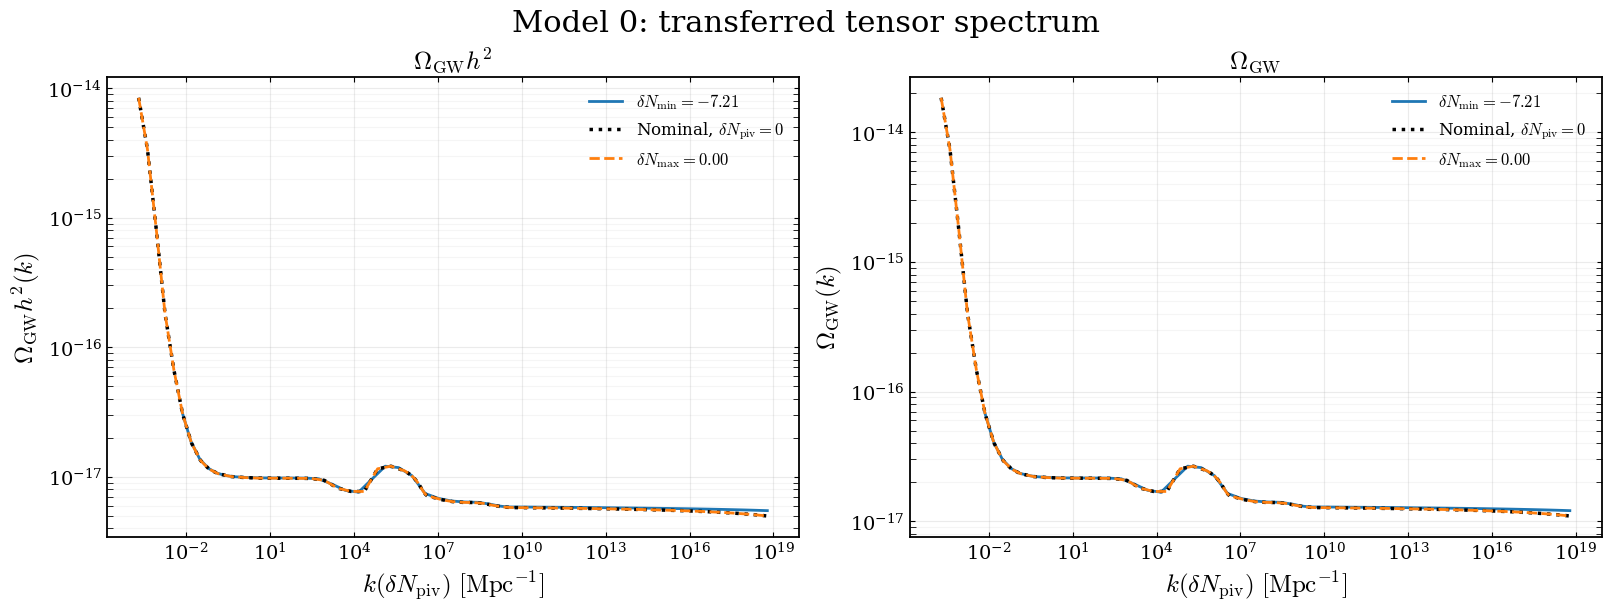


Saved figure: model_0_omegaGW_mergedTF_nominal_and_boundaries.png


In [28]:
result = plot_one_model_omegaGW_mergedTF(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    NEQS=6,
    h=0.675,
)

## Plot 8: Allowed $\delta N_{piv}$ intervals

In [33]:

def ensure_increasing_k(k, values, name="data"):
    """
    Preserve the original k-value pairing.

    - Leave increasing data unchanged.
    - Reverse both arrays if strictly decreasing.
    - Refuse to reorder non-monotonic data.
    """

    k = np.asarray(k, dtype=float)
    values = np.asarray(values, dtype=float)

    if len(k) != len(values):
        raise ValueError(f"{name}: arrays have different lengths.")

    dk = np.diff(k)

    if np.all(dk > 0):
        return k, values

    if np.all(dk < 0):
        return k[::-1], values[::-1]

    raise ValueError(
        f"{name}: k is not monotonic. "
        "Data were not sorted automatically."
    )
    
    

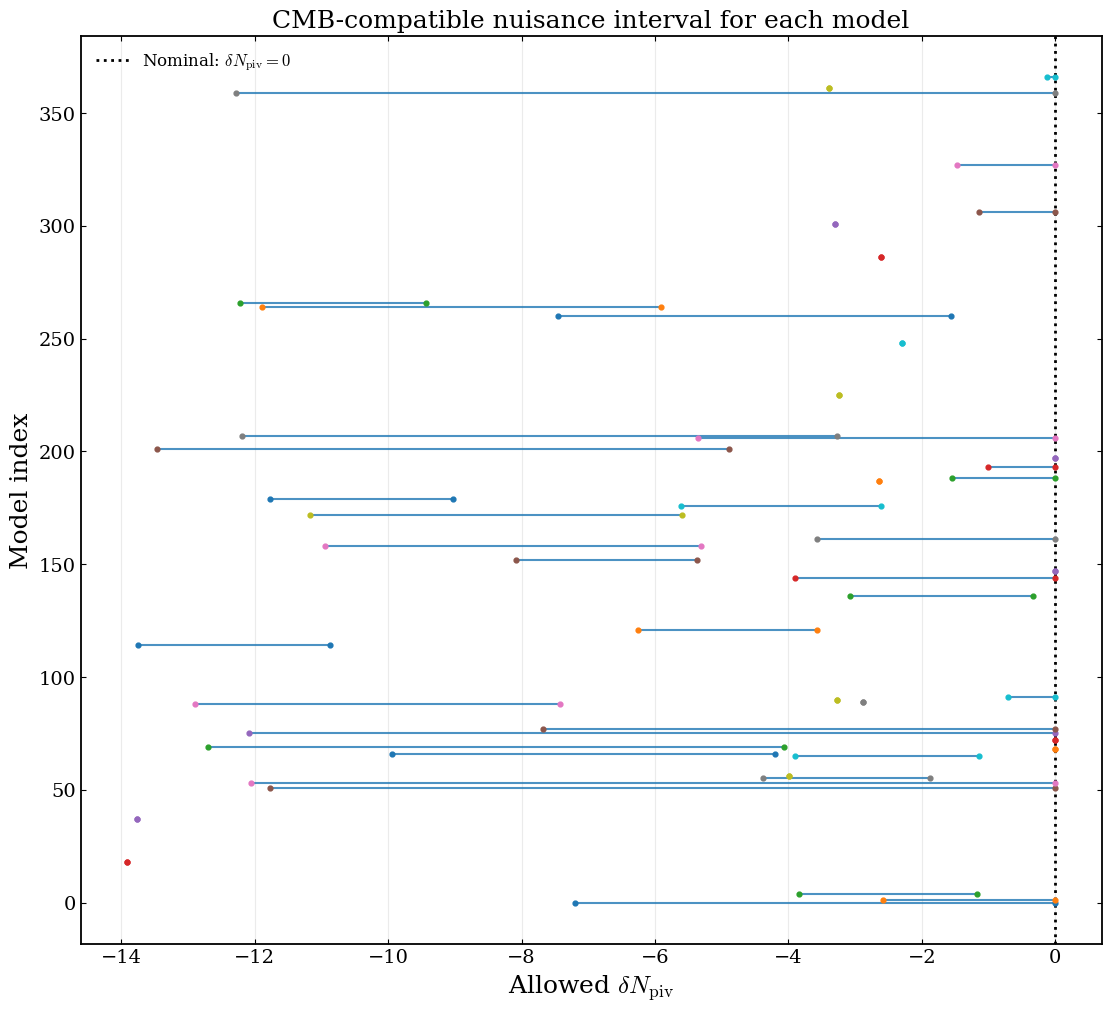

Models plotted: 50
Saved: allowed_deltaN_intervals.png


In [34]:
def plot_deltaN_intervals(
    deltaN_ranges_df,
    save_name="allowed_deltaN_intervals.png",
    show=True,
):
    """
    Plot each model's CMB-compatible deltaN_piv interval.

    Solid horizontal lines show the allowed interval for each
    model. The two endpoints are marked with points.
    """

    df = deltaN_ranges_df.copy()

    # Only models that pass somewhere
    df = df.loc[
        df["passes_cmb_somewhere"]
    ].copy()

    # Put models in model-index order
    df = df.sort_values(
        "model_index"
    )

    fig, ax = plt.subplots(
        figsize=(11, 10),
        constrained_layout=True,
    )

    for _, row in df.iterrows():

        model_index = int(
            row["model_index"]
        )

        deltaN_min = float(
            row["deltaN_min"]
        )

        deltaN_max = float(
            row["deltaN_max"]
        )

        # Draw the allowed interval
        ax.hlines(
            y=model_index,
            xmin=deltaN_min,
            xmax=deltaN_max,
            linewidth=1.5,
            linestyle="-",
            alpha=0.8,
        )

        # Mark the two boundaries
        ax.scatter(
            [deltaN_min, deltaN_max],
            [model_index, model_index],
            s=12,
            zorder=3,
        )

    # Nominal pivot location
    ax.axvline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=2.0,
        label=r"Nominal: $\delta N_{\rm piv}=0$",
    )

    ax.set_xlabel(
        r"Allowed $\delta N_{\rm piv}$"
    )

    ax.set_ylabel(
        "Model index"
    )

    ax.set_title(
        r"CMB-compatible nuisance interval for each model"
    )

    ax.grid(
        True,
        axis="x",
        which="major",
        alpha=0.25,
    )

    ax.legend(
        frameon=False,
        loc="best",
    )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    print(
        f"Models plotted: {len(df)}"
    )

    print(
        f"Saved: {save_name}"
    )

    return df


dN_intervals = plot_deltaN_intervals(
    deltaN_ranges_df
)



A dashed interval means the passing saved points were not one consecutive block. Solid means continuous across the saved points, but these should all be continuous. Another name for this kind of plot is a forest plot! So a horizontal line sigment per model spanning that model's $\delta N$ range. There is honestly not much a pattern to this. Let's check that the base model based for safety lol

In [35]:
fiducial_rows = deltaN_ranges_df.loc[
    np.isclose(
        deltaN_ranges_df["deltaN_from_base"],
        0.0,
        atol=1e-8,
    )
]

print(fiducial_rows[[
    "model_index",
    "deltaN_from_base",
    "passes_cmb_somewhere",
    "deltaN_min",
    "deltaN_max",
]])

   model_index  deltaN_from_base  passes_cmb_somewhere  deltaN_min  deltaN_max
0            0               0.0                  True   -7.205167         0.0


# Plot 9: $\Omega_{GW} (k)$ For CMB Passing Models 

So, for every CMB passing model, and for every saved $N_{eval}$ point where the model passes, we plot a shifted $\Omega_{GW}$ or $\Omega_{GW}h^2$ curve, whose points are colored by $\delta N_{piv}$. Now, we are showing every allowed realization, not just one representative curve per model. Not really treating it like a nuisiance parameter. 

In [36]:
def plot_all_allowed_omegaGW_mergedTF(
    cmb_passing_models,
    NEQS=6,
    h=0.675,
    plot_h2=True,
    tf_file=None,
    save_name=None,
):
    """
    Plot every CMB-allowed Omega_GW realization using the merged
    Kite + Saikawa-Shirai transfer function.

    Each allowed saved N_eval gives

        deltaN_piv = N_eval - 60

    and therefore

        k_shifted = k * exp(-deltaN_piv).

    The merged transfer function uses

        T_Omega(k) = Omega_GW(k) / P_T(k),

    so

        Omega_GW(k)    = T_Omega(k) * P_T(k)

    and

        Omega_GW h^2   = h^2 * Omega_GW.

    Curve color represents deltaN_piv.
    """

    # ========================================================
    # Default merged TF file
    # ========================================================

    if tf_file is None:
        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )
    else:
        tf_file = Path(tf_file)

    if not tf_file.exists():
        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )

    # ========================================================
    # Fiducial model
    # ========================================================

    fiducial_model_index = [
        c["model_index"]
        for c in cmb_passing_models
        if np.isclose(
            c["deltaN_from_base"],
            0.0,
            atol=1e-8,
        )
    ][0]

    # ========================================================
    # Prepare merged transfer function
    #
    # File columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # ========================================================

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_f = tf_f[good_tf]
    tf_T = tf_T[good_tf]

    # --------------------------------------------------------
    # Ensure monotonic k
    # --------------------------------------------------------

    dktf = np.diff(
        tf_k
    )

    if np.all(dktf > 0):
        pass

    elif np.all(dktf < 0):

        tf_k = tf_k[::-1]
        tf_f = tf_f[::-1]
        tf_T = tf_T[::-1]

    else:

        raise ValueError(
            "Transfer-function k array is non-monotonic."
        )

    # --------------------------------------------------------
    # Log-log interpolation
    # --------------------------------------------------------

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]

    print("\nMerged transfer function:")
    print("file:", tf_file)
    print("k range:", kmin_tf, kmax_tf)
    print("convention: T(k) = Omega_GW / P_T")

    # ========================================================
    # Collect all allowed deltaN_piv values
    # ========================================================

    all_allowed_deltaN = np.concatenate([
        curves["deltaN_piv"][
            curves["cmb_pass_mask"]
        ]
        for curves in cmb_passing_models
    ])

    deltaN_color_min = np.min(
        all_allowed_deltaN
    )

    deltaN_color_max = np.max(
        all_allowed_deltaN
    )

    # --------------------------------------------------------
    # Diverging color map
    # --------------------------------------------------------

    cmap = plt.get_cmap(
        "coolwarm"
    )

    norm = mcolors.TwoSlopeNorm(
        vmin=deltaN_color_min,
        vcenter=(
            (deltaN_color_max + deltaN_color_min)
            / 2.0
        ),
        vmax=deltaN_color_max,
    )

    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8),
        constrained_layout=True,
    )

    total_curves = 0

    # ========================================================
    # Loop through passing models
    # ========================================================

    for curves in cmb_passing_models:

        model_index = curves[
            "model_index"
        ]

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )

        # ----------------------------------------------------
        # Tensor spectrum
        # ----------------------------------------------------

        k_raw = np.asarray(
            tensor_data[:, 0],
            dtype=float,
        )

        # h/Mpc -> Mpc^-1
        k_raw = (
            k_raw
            * h
        )

        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )

        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[
            good
        ]

        Pt_raw = Pt_raw[
            good
        ]

        # ----------------------------------------------------
        # Preserve physical k-P pairing
        # ----------------------------------------------------

        dk = np.diff(
            k_raw
        )

        if np.all(dk > 0):
            pass

        elif np.all(dk < 0):

            k_raw = k_raw[::-1]
            Pt_raw = Pt_raw[::-1]

        else:

            raise ValueError(
                f"Model {model_index}: "
                "tensor k grid is non-monotonic."
            )

        # ====================================================
        # Allowed N / deltaN points
        # ====================================================

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_N = curves["N"][
            pass_mask
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][pass_mask]

        # ====================================================
        # Every allowed realization
        # ====================================================

        for N_eval, deltaN in zip(
            allowed_N,
            allowed_deltaN,
        ):

            # -----------------------------------------------
            # Shift k
            # -----------------------------------------------

            k_shifted = (
                k_raw
                * np.exp(
                    -deltaN
                )
            )

            # -----------------------------------------------
            # Transfer-function overlap
            # -----------------------------------------------

            overlap = (
                (k_shifted >= kmin_tf)
                & (k_shifted <= kmax_tf)
            )

            k_use = (
                k_shifted[
                    overlap
                ]
            )

            Pt_use = (
                Pt_raw[
                    overlap
                ]
            )

            if len(k_use) < 5:
                continue

            # -----------------------------------------------
            # Evaluate merged TF
            # -----------------------------------------------

            T_use = np.exp(
                logT_interp(
                    np.log(
                        k_use
                    )
                )
            )

            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[
                valid
            ]

            Pt_use = Pt_use[
                valid
            ]

            T_use = T_use[
                valid
            ]

            if len(k_use) < 5:
                continue

            # ====================================================
            # Omega_GW
            #
            # merged TF convention:
            #
            #     T(k) = Omega_GW / P_T
            #
            # therefore:
            #
            #     Omega_GW = T(k) * P_T
            #
            #     Omega_GW h^2 = h^2 Omega_GW
            # ====================================================

            OmegaGW = (
                T_use
                * Pt_use
            )

            OmegaGW_h2 = (
                h**2
                * OmegaGW
            )

            if plot_h2:

                yplot = (
                    OmegaGW_h2
                )

            else:

                yplot = (
                    OmegaGW
                )

            # -----------------------------------------------
            # Color by deltaN_piv
            # -----------------------------------------------

            color = cmap(
                norm(deltaN)
            )

            # -----------------------------------------------
            # Fiducial model
            # -----------------------------------------------

            if (
                model_index == fiducial_model_index
                and np.isclose(
                    deltaN,
                    0.0,
                    atol=1e-8,
                )
            ):

                ax.loglog(
                    k_use,
                    yplot,
                    color="black",
                    lw=3.0,
                    ls="--",
                    alpha=1.0,
                    zorder=10,
                    label="Fiducial, deltaN_piv=0",
                )

            else:

                ax.loglog(
                    k_use,
                    yplot,
                    color=color,
                    lw=1.4,
                    alpha=0.45,
                )

            total_curves += 1

    # ========================================================
    # Colorbar
    # ========================================================

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        r"$\delta N_{\rm piv}"
        r"=N_{\rm eval}-60$"
    )

    # ========================================================
    # Styling
    # ========================================================

    ax.set_xlabel(
        r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
    )

    if plot_h2:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}h^2(k)$"
        )

        ax.set_title(
            r"All CMB-allowed $\Omega_{\rm GW}h^2$ realizations"
        )

    else:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}(k)$"
        )

        ax.set_title(
            r"All CMB-allowed $\Omega_{\rm GW}$ realizations"
        )

    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )

    ax.grid(
        True,
        which="minor",
        alpha=0.10,
    )

    # --------------------------------------------------------
    # Keep your custom y ticks
    # --------------------------------------------------------

    yticks = np.geomspace(
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        8,
    )

    ax.set_yticks(
        yticks
    )

    ax.set_yticklabels(
        [
            f"{y:.1e}"
            for y in yticks
        ]
    )

    # ========================================================
    # Title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: "
        rf"{len(cmb_passing_models)} CMB-compatible models, "
        rf"{total_curves} allowed pivot realizations"
    )

    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        suffix = (
            "h2"
            if plot_h2
            else "plain"
        )

        save_name = (
            f"all_CMB_allowed_"
            f"OmegaGW_{suffix}_"
            f"mergedTF_"
            f"colored_by_deltaNpiv_"
            f"neqs{NEQS}.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    # ========================================================
    # Diagnostics
    # ========================================================

    print(
        f"Passing models plotted : "
        f"{len(cmb_passing_models)}"
    )

    print(
        f"Total OmegaGW curves   : "
        f"{total_curves}"
    )

    print(
        f"deltaN_piv range       : "
        f"[{deltaN_color_min:.4f}, "
        f"{deltaN_color_max:.4f}]"
    )

    print(
        f"Merged TF range        : "
        f"[{kmin_tf:.4e}, "
        f"{kmax_tf:.4e}] Mpc^-1"
    )

    print(
        f"Saved figure           : "
        f"{save_name}"
    )


Merged transfer function:
file: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range: 0.0001 7.178159862110405e+18
convention: T(k) = Omega_GW / P_T


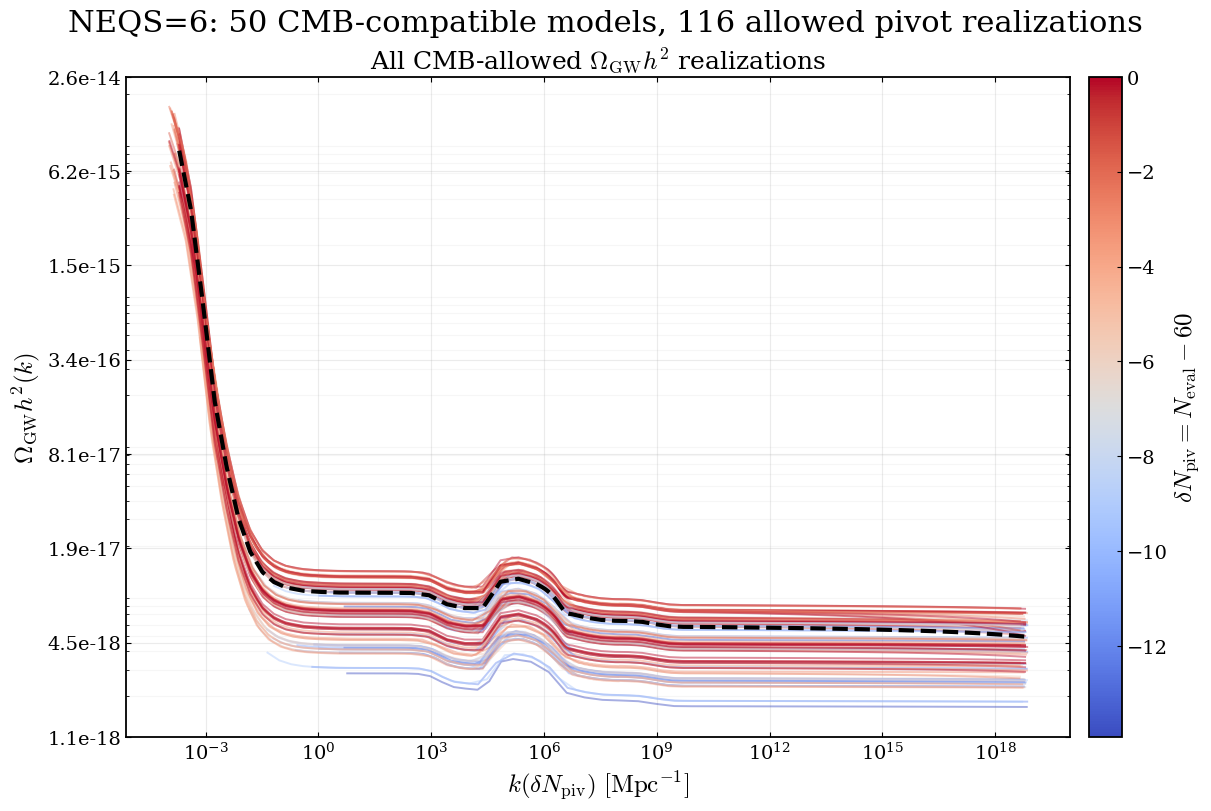

Passing models plotted : 50
Total OmegaGW curves   : 116
deltaN_piv range       : [-13.9181, 0.0000]
Merged TF range        : [1.0000e-04, 7.1782e+18] Mpc^-1
Saved figure           : all_CMB_allowed_OmegaGW_h2_mergedTF_colored_by_deltaNpiv_neqs6.pdf

Merged transfer function:
file: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range: 0.0001 7.178159862110405e+18
convention: T(k) = Omega_GW / P_T


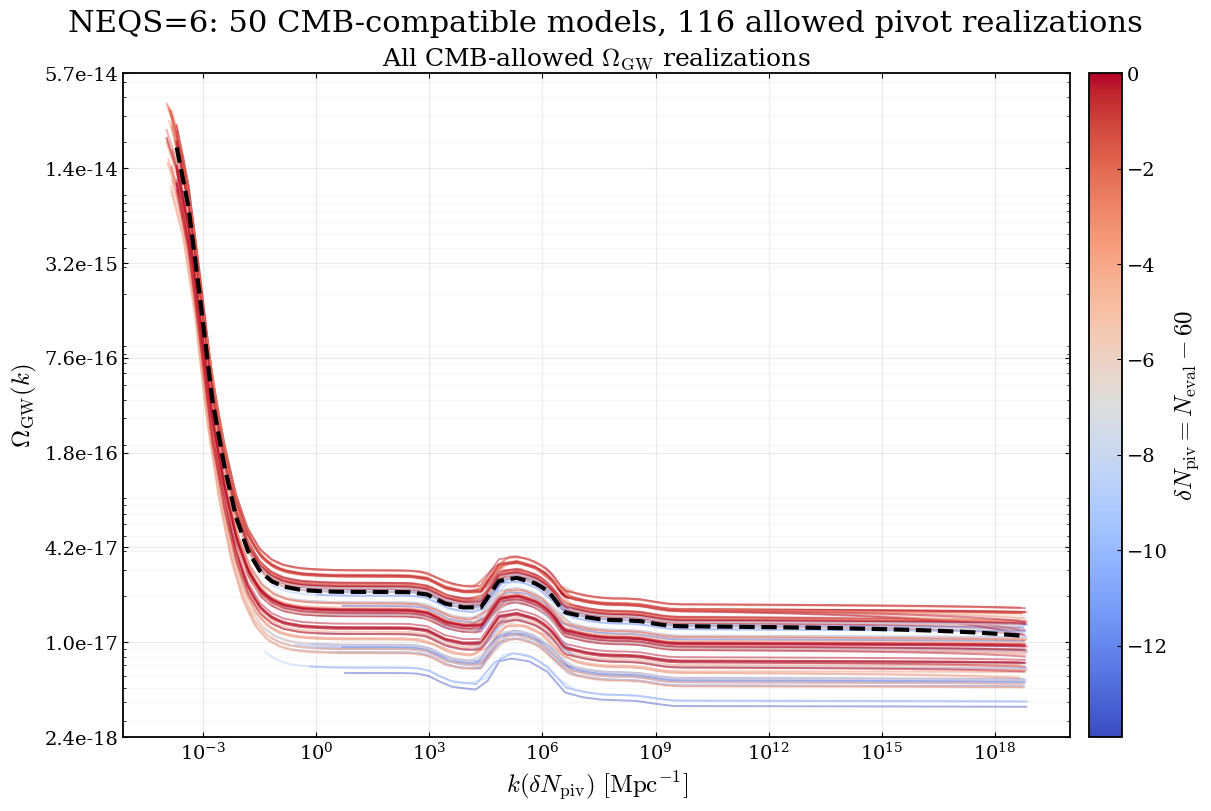

Passing models plotted : 50
Total OmegaGW curves   : 116
deltaN_piv range       : [-13.9181, 0.0000]
Merged TF range        : [1.0000e-04, 7.1782e+18] Mpc^-1
Saved figure           : all_CMB_allowed_OmegaGW_plain_mergedTF_colored_by_deltaNpiv_neqs6.pdf


In [37]:
plot_all_allowed_omegaGW_mergedTF(
    cmb_passing_models=cmb_passing_models,
    NEQS=6,
    h=0.675,
    plot_h2=True,
)

plot_all_allowed_omegaGW_mergedTF(
    cmb_passing_models=cmb_passing_models,
    NEQS=6,
    h=0.675,
    plot_h2=False,
)

Okay so this counts the number of CMB compatible models, and for a given model I could have an array of $\delta N$ value so we mark those as well. Rather, we are plotting the full ensemble of CMB allowed models, where each curve corresponds to the specific allowed pivot shift. The color bar scheme is per model. We also highlight the fiducial model, which is evaluated at $\delta N_{piv} = 0$. The title records the numbers of CMB compatible models and the total allowed realizations due to the $\delta N$ shift.


# Fiducial Measurement

In [39]:
def define_fiducial_measurements(
    deltaN_ranges_df,
    k_int,
    k_ast,
    NEQS=6,
    h=0.675,
    SN_int=10.0,
    SN_ast=10.0,
    deltaN_true=0.0,
    tf_file=None,
):
    """
    Define the mock measurements used in the likelihood forecast.

    The true model is the fiducial model satisfying:

        deltaN_from_base = 0

    The default mock truth uses:

        deltaN_true = 0

    Returns the fiducial Omega_GW amplitude and local spectral slope
    at k_int and k_ast, along with assumed measurement uncertainties.
    """

    
    if tf_file is None:
        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )
    else:
        tf_file = Path(tf_file)

    if not tf_file.exists():
        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )
    
    
    # --------------------------------------------------------
    # 1. Identify the true fiducial model
    # --------------------------------------------------------
    fiducial_matches = deltaN_ranges_df.loc[
        np.isclose(
            deltaN_ranges_df["deltaN_from_base"], #good deltaN_from_base = N_end - base_N_end
            0.0,
            atol=1e-8,
        )
    ]

    if fiducial_matches.empty:
        raise ValueError(
            "No fiducial model with deltaN_from_base = 0 was found."
        )

    if len(fiducial_matches) > 1: #better not be more than 1 I would say
        raise ValueError(
            "More than one model has deltaN_from_base = 0."
        )

    fiducial_row = fiducial_matches.iloc[0]

    model_index = int(fiducial_row["model_index"])
    deltaN_min = float(fiducial_row["deltaN_min"])
    deltaN_max = float(fiducial_row["deltaN_max"])
    outdir = fiducial_row["outdir"]

    # Check that the assumed true shift is CMB allowed
    if not (deltaN_min <= deltaN_true <= deltaN_max):
        raise ValueError(
            f"deltaN_true={deltaN_true:.4f} is outside the fiducial "
            f"CMB-compatible interval "
            f"[{deltaN_min:.4f}, {deltaN_max:.4f}]."
        )

    # --------------------------------------------------------
    # 2. Load the fiducial tensor spectrum
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(tensor_file)

    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]
    
    ## NO SHIFT IS EVER APPLIED!! THIS IS SUPPOSED TO BE THE NOMINAL UNSHIFTED SPEC FOR OUR BASE MODEL

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name="fiducial tensor spectrum",
    )

    # --------------------------------------------------------
    # 3. Prepare the merged transfer function
    #
    # Columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # --------------------------------------------------------

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_f = tf_f[good_tf]
    tf_T = tf_T[good_tf]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="merged transfer function",
    )

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )


 # --------------------------------------------------------
# 4. Keep the fiducial spectrum unshifted
# --------------------------------------------------------

    overlap = (
        (k_raw >= tf_k[0])
        & (k_raw <= tf_k[-1])
    )

    k_use = k_raw[overlap]
    Pt_use = Pt_raw[overlap]

    # --------------------------------------------------------
    # 4b. Apply the transfer function
    # --------------------------------------------------------
    T_use = np.exp(
        logT_interp(
            np.log(k_use)
        )
    )

    valid = (
        np.isfinite(k_use)
        & np.isfinite(Pt_use)
        & np.isfinite(T_use)
        & (k_use > 0)
        & (Pt_use > 0)
        & (T_use > 0)
    )

    k_use = k_use[valid]
    Pt_use = Pt_use[valid]
    T_use = T_use[valid]

    OmegaGW = (
    T_use
    * Pt_use
)

    OmegaGW_h2 = (
        h**2
        * OmegaGW
    )


    # --------------------------------------------------------
    # 5. Interpolate the observable spectrum
    # --------------------------------------------------------
    logOmega_interp = interp1d(
        np.log(k_use),
        np.log(OmegaGW),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    def omega_at_k(k_target):
        value = np.exp(
            logOmega_interp(
                np.log(k_target)
            )
        )

        if not np.isfinite(value):
            raise ValueError(
                f"k={k_target:.4e} Mpc^-1 lies outside the "
                "fiducial transferred-spectrum range."
            )

        return float(value)

    # --------------------------------------------------------
    # 6. Local observable slope:
    #       n_Omega = d ln(Omega_GW) / d ln(k)
    # --------------------------------------------------------
    logk = np.log(k_use)
    logOmega = np.log(OmegaGW)

    nOmega_values = np.gradient(
        logOmega,
        logk,
    ) #this uses central differences in interior and onsesided diff at endpoints

    nOmega_interp = interp1d(
        logk,
        nOmega_values,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )
    
#     nOmega_interp = logOmega_interp.derivative()


    def nOmega_at_k(k_target):
        value = nOmega_interp(
            np.log(k_target)
        )

        if not np.isfinite(value):
            raise ValueError(
                f"Cannot evaluate n_Omega at "
                f"k={k_target:.4e} Mpc^-1."
            )

        return float(value)

    # --------------------------------------------------------
    # 7. Mock measurements from the fiducial prediction
    # --------------------------------------------------------
    Omega_meas_int = omega_at_k(k_int)
    Omega_meas_ast = omega_at_k(k_ast)

    n_meas_int = nOmega_at_k(k_int)
    n_meas_ast = nOmega_at_k(k_ast)

    # Fixed experimental uncertainties
    sigma_Omega_int = (
        Omega_meas_int
        / SN_int
    )

    sigma_Omega_ast = (
        Omega_meas_ast
        / SN_ast
    )

    # --------------------------------------------------------
    # 8. Store everything
    # --------------------------------------------------------
    fiducial_measurements = {
        "model_index": model_index,
        "outdir": outdir,
        "deltaN_true": deltaN_true,
        "deltaN_min": deltaN_min,
        "deltaN_max": deltaN_max,

        "k_int": float(k_int),
        "Omega_meas_int": Omega_meas_int,
        "n_meas_int": n_meas_int,
        "SN_int": float(SN_int),
        "sigma_Omega_int": sigma_Omega_int,

        "k_ast": float(k_ast),
        "Omega_meas_ast": Omega_meas_ast,
        "n_meas_ast": n_meas_ast,
        "SN_ast": float(SN_ast),
        "sigma_Omega_ast": sigma_Omega_ast,

        "k_spectrum": k_use,
        "OmegaGW_spectrum": OmegaGW,
        "OmegaGW_h2_spectrum": OmegaGW_h2,
        "nOmega_spectrum": nOmega_values,
    }

    print("\nFiducial mock measurements")
    print("=" * 65)
    print(f"Fiducial model index : {model_index}")
    print(f"True deltaN          : {deltaN_true:.6f}")
    print(
        f"Allowed deltaN       : "
        f"[{deltaN_min:.6f}, {deltaN_max:.6f}]"
    )

    print("\nInterferometer scale")
    print(f"k_int                : {k_int:.6e} Mpc^-1")
    print(f"Omega_meas_int       : {Omega_meas_int:.6e}")
    print(f"n_meas_int           : {n_meas_int:.6e}")
    print(f"sigma_Omega_int      : {sigma_Omega_int:.6e}")

    print("\nAstrometry scale")
    print(f"k_ast                : {k_ast:.6e} Mpc^-1")
    print(f"Omega_meas_ast       : {Omega_meas_ast:.6e}")
    print(f"n_meas_ast           : {n_meas_ast:.6e}")
    print(f"sigma_Omega_ast      : {sigma_Omega_ast:.6e}")
    print("=" * 65)

    return fiducial_measurements


fiducial_data = define_fiducial_measurements(
    deltaN_ranges_df=deltaN_ranges_df,
    k_int=1.6e14,
    k_ast=2.05e7,
    NEQS=6,
    h=0.675,
    tf_file=(
        "/Users/epmeador/Desktop/research/rwarthur/"
        "inflation_gravitywaves/inflation_code/"
        "InflationModels/merged_transfer_function/"
        "merged_gw_transfer_function_extended.dat"
    ),
)

Omega_meas_int = fiducial_data["Omega_meas_int"]
Omega_meas_ast = fiducial_data["Omega_meas_ast"]

n_meas_int = fiducial_data["n_meas_int"]
n_meas_ast = fiducial_data["n_meas_ast"]




Fiducial mock measurements
Fiducial model index : 0
True deltaN          : 0.000000
Allowed deltaN       : [-7.205167, 0.000000]

Interferometer scale
k_int                : 1.600000e+14 Mpc^-1
Omega_meas_int       : 1.229407e-17
n_meas_int           : -5.004021e-03
sigma_Omega_int      : 1.229407e-18

Astrometry scale
k_ast                : 2.050000e+07 Mpc^-1
Omega_meas_ast       : 1.439827e-17
n_meas_ast           : -3.921393e-02
sigma_Omega_ast      : 1.439827e-18


# Plot 10: CMB + Interferometer Scales

Of all the CMB allowed realizations, which ones are also consistent with the fiducial model's mock interferometer measurement at $k_{int}$ within $2\sigma$? How many models do we lose?

In [40]:
def plot_all_allowed_omegaGW(
    cmb_passing_models,
    fiducial_measurements,
    NEQS=6,
    h=0.675,
    plot_h2=False,
    tf_file=None,
    save_name=None,
):
    """
    Plot every CMB-allowed Omega_GW realization using the merged
    Kite + Saikawa-Shirai transfer function.

    All CMB-compatible realizations are shown in one color.

    A realization is highlighted if its Omega_GW(k_int)
    agrees with the fiducial mock interferometer measurement
    within 2 sigma:

        |Omega_model(k_int) - Omega_fid(k_int)|
            <= 2 * sigma_Omega_int

    The fiducial base model at deltaN_piv = 0 is shown
    as a black dashed curve.

    Merged transfer-function convention:

        T_Omega(k) = Omega_GW(k) / P_T(k)

    so that

        Omega_GW(k)  = T_Omega(k) * P_T(k)

        Omega_GW h^2 = h^2 * Omega_GW(k)
    """

    # ========================================================
    # 0. Merged transfer-function file
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    else:

        tf_file = Path(tf_file)

    if not tf_file.exists():

        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )


    # ========================================================
    # Fiducial interferometer measurement
    # ========================================================

    fiducial_model_index = int(
        fiducial_measurements["model_index"]
    )

    k_int = float(
        fiducial_measurements["k_int"]
    )

    Omega_fid_int = float(
        fiducial_measurements["Omega_meas_int"]
    )

    sigma_Omega_int = float(
        fiducial_measurements["sigma_Omega_int"]
    )


    # --------------------------------------------------------
    # 2-sigma acceptable interval at k_int
    # --------------------------------------------------------

    Omega_int_min = (
        Omega_fid_int
        - 2.0 * sigma_Omega_int
    )

    Omega_int_max = (
        Omega_fid_int
        + 2.0 * sigma_Omega_int
    )


    # ========================================================
    # Prepare merged transfer function
    #
    # Columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # ========================================================

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[
        good_tf
    ]

    tf_f = tf_f[
        good_tf
    ]

    tf_T = tf_T[
        good_tf
    ]


    # --------------------------------------------------------
    # Ensure monotonic k
    # --------------------------------------------------------

    dktf = np.diff(
        tf_k
    )

    if np.all(dktf > 0):

        pass

    elif np.all(dktf < 0):

        tf_k = tf_k[::-1]
        tf_f = tf_f[::-1]
        tf_T = tf_T[::-1]

    else:

        raise ValueError(
            "Transfer-function k array is non-monotonic."
        )


    # --------------------------------------------------------
    # Log-log interpolation
    # --------------------------------------------------------

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]


    print("\nMerged transfer function")
    print(f"file       : {tf_file}")
    print(
        f"k range    : "
        f"{kmin_tf:.6e} -> {kmax_tf:.6e} Mpc^-1"
    )
    print(
        "convention : T(k) = Omega_GW / P_T"
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8),
        constrained_layout=True,
    )


    # --------------------------------------------------------
    # Colors
    # --------------------------------------------------------

    cmb_color = "#9AA6B2"
    compatible_color = "#169C9C"
    fiducial_color = "black"


    # --------------------------------------------------------
    # Counters
    # --------------------------------------------------------

    total_curves = 0
    compatible_curves = 0

    compatible_model_indices = set()


    # ========================================================
    # Loop through CMB-passing models
    # ========================================================

    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )


        # ----------------------------------------------------
        # Tensor spectrum
        # ----------------------------------------------------

        k_raw = np.asarray(
            tensor_data[:, 0],
            dtype=float,
        )

        # h/Mpc -> Mpc^-1
        k_raw = (
            k_raw
            * h
        )


        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[
            good
        ]

        Pt_raw = Pt_raw[
            good
        ]


        # ----------------------------------------------------
        # Preserve physical k-P pairing
        # ----------------------------------------------------

        dk = np.diff(
            k_raw
        )

        if np.all(dk > 0):

            pass

        elif np.all(dk < 0):

            k_raw = k_raw[::-1]
            Pt_raw = Pt_raw[::-1]

        else:

            raise ValueError(
                f"Model {model_index}: "
                "tensor k grid is non-monotonic."
            )


        # ====================================================
        # CMB-allowed deltaN realizations
        # ====================================================

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_N = curves["N"][
            pass_mask
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][
            pass_mask
        ]


        # ====================================================
        # Loop over every realization
        # ====================================================

        for N_eval, deltaN in zip(
            allowed_N,
            allowed_deltaN,
        ):

            # ------------------------------------------------
            # Shift k
            # ------------------------------------------------

            k_shifted = (
                k_raw
                * np.exp(
                    -deltaN
                )
            )


            # ------------------------------------------------
            # Transfer-function overlap
            # ------------------------------------------------

            overlap = (
                (k_shifted >= kmin_tf)
                & (k_shifted <= kmax_tf)
            )

            k_use = (
                k_shifted[
                    overlap
                ]
            )

            Pt_use = (
                Pt_raw[
                    overlap
                ]
            )


            if len(k_use) < 5:

                continue


            # ------------------------------------------------
            # Evaluate merged transfer function
            # ------------------------------------------------

            T_use = np.exp(
                logT_interp(
                    np.log(
                        k_use
                    )
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[
                valid
            ]

            Pt_use = Pt_use[
                valid
            ]

            T_use = T_use[
                valid
            ]


            if len(k_use) < 5:

                continue


            # =================================================
            # Omega_GW
            #
            # Merged TF:
            #
            #     T(k) = Omega_GW / P_T
            #
            # therefore:
            #
            #     Omega_GW = T(k) * P_T
            #
            #     Omega_GW h^2 = h^2 * Omega_GW
            # =================================================

            OmegaGW = (
                T_use
                * Pt_use
            )

            OmegaGW_h2 = (
                h**2
                * OmegaGW
            )


            # =================================================
            # Evaluate this realization at k_int
            # =================================================

            if not (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                continue


            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                kind="linear",
                bounds_error=False,
                fill_value=np.nan,
            )


            Omega_at_k_int = np.exp(
                logOmega_interp(
                    np.log(k_int)
                )
            )


            if not np.isfinite(
                Omega_at_k_int
            ):

                continue


            # =================================================
            # 2-sigma interferometer compatibility
            # =================================================

            passes_interferometer = (
                (Omega_at_k_int >= Omega_int_min)
                & (Omega_at_k_int <= Omega_int_max)
            )


            # =================================================
            # Choose y-axis quantity
            # =================================================

            if plot_h2:

                yplot = (
                    OmegaGW_h2
                )

            else:

                yplot = (
                    OmegaGW
                )


            # =================================================
            # Plotting style
            # =================================================

            is_fiducial = (
                model_index
                == fiducial_model_index
                and np.isclose(
                    deltaN,
                    0.0,
                    atol=1e-8,
                )
            )


            if is_fiducial:

                ax.loglog(
                    k_use,
                    yplot,
                    color=fiducial_color,
                    lw=3.0,
                    ls="--",
                    alpha=1.0,
                    zorder=5,
                )


            elif passes_interferometer:

                ax.loglog(
                    k_use,
                    yplot,
                    color=compatible_color,
                    lw=2.0,
                    alpha=0.85,
                    zorder=3,
                )

                compatible_curves += 1

                compatible_model_indices.add(
                    model_index
                )


            else:

                ax.loglog(
                    k_use,
                    yplot,
                    color=cmb_color,
                    lw=1.0,
                    alpha=0.30,
                    zorder=1,
                )


            total_curves += 1


    # ========================================================
    # Mark interferometer scale
    # ========================================================

    ax.axvline(
        k_int,
        color="black",
        ls=":",
        lw=1.5,
        alpha=0.7,
    )


    # ========================================================
    # Fiducial 2-sigma measurement
    # ========================================================

    if plot_h2:

        Omega_fid_plot = (
            Omega_fid_int
            * h**2
        )

        sigma_plot = (
            sigma_Omega_int
            * h**2
        )

    else:

        Omega_fid_plot = (
            Omega_fid_int
        )

        sigma_plot = (
            sigma_Omega_int
        )


    ax.errorbar(
        k_int,
        Omega_fid_plot,
        yerr=2.0 * sigma_plot,
        fmt="o",
        color="black",
        markersize=7,
        capsize=5,
        zorder=10,
    )


    # ========================================================
    # Legend
    # ========================================================

    cmb_handle = Line2D(
        [0],
        [0],
        color=cmb_color,
        lw=2.0,
        alpha=0.7,
        label="CMB-compatible realization",
    )

    compatible_handle = Line2D(
        [0],
        [0],
        color=compatible_color,
        lw=2.5,
        label=(
            r"CMB + interferometer "
            r"($2\sigma$)"
        ),
    )

    fiducial_handle = Line2D(
        [0],
        [0],
        color=fiducial_color,
        lw=3.0,
        ls="--",
        label=(
            r"Fiducial, "
            r"$\delta N_{\rm piv}=0$"
        ),
    )

    measurement_handle = Line2D(
        [0],
        [0],
        color="black",
        marker="o",
        linestyle=":",
        lw=1.5,
        label=(
            r"Fiducial $k_{\rm int}$ "
            r"measurement"
        ),
    )


    ax.legend(
        handles=[
            cmb_handle,
            compatible_handle,
            fiducial_handle,
            measurement_handle,
        ],
        frameon=False,
        loc="best",
    )


    # ========================================================
    # Axis labels
    # ========================================================

    ax.set_xlabel(
        r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
    )


    if plot_h2:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}h^2(k)$"
        )

        ax.set_title(
            r"CMB-allowed $\Omega_{\rm GW}h^2$ realizations"
        )

    else:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}(k)$"
        )

        ax.set_title(
            r"CMB-allowed $\Omega_{\rm GW}$ realizations"
        )


    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )

    ax.grid(
        True,
        which="minor",
        alpha=0.10,
    )


    yticks = np.geomspace(
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        8,
    )

    ax.set_yticks(
        yticks
    )

    ax.set_yticklabels(
        [
            f"{y:.1e}"
            for y in yticks
        ]
    )


    # ========================================================
    # Title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: "
        rf"{len(cmb_passing_models)} CMB-compatible models, "
        rf"{total_curves} allowed realizations"
        "\n"
        rf"{len(compatible_model_indices)} models "
        rf"have at least one realization within "
        rf"$2\sigma$ at $k_{{\rm int}}$"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        suffix = (
            "h2"
            if plot_h2
            else "plain"
        )

        save_name = (
            f"CMB_and_interferometer_"
            f"OmegaGW_{suffix}_"
            f"mergedTF_"
            f"neqs{NEQS}.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


    # ========================================================
    # Summary
    # ========================================================

    print("\n" + "=" * 70)
    print("INTERFEROMETER 2-SIGMA COMPATIBILITY")
    print("=" * 70)

    print(
        f"Fiducial Omega(k_int)    : "
        f"{Omega_fid_int:.6e}"
    )

    print(
        f"1-sigma uncertainty      : "
        f"{sigma_Omega_int:.6e}"
    )

    print(
        f"2-sigma interval         : "
        f"[{Omega_int_min:.6e}, "
        f"{Omega_int_max:.6e}]"
    )

    print(
        f"CMB-compatible models    : "
        f"{len(cmb_passing_models)}"
    )

    print(
        f"Allowed realizations     : "
        f"{total_curves}"
    )

    print(
        f"2-sigma realizations     : "
        f"{compatible_curves}"
    )

    print(
        f"Models passing 2-sigma   : "
        f"{len(compatible_model_indices)}"
    )

    print(
        "Passing model indices    : "
        f"{sorted(compatible_model_indices)}"
    )

    print(
        f"Merged TF range          : "
        f"[{kmin_tf:.6e}, "
        f"{kmax_tf:.6e}] Mpc^-1"
    )

    print("=" * 70)


    return {
        "total_realizations": total_curves,
        "compatible_realizations": compatible_curves,
        "compatible_model_indices": sorted(
            compatible_model_indices
        ),
        "Omega_fid_int": Omega_fid_int,
        "sigma_Omega_int": sigma_Omega_int,
        "Omega_int_min": Omega_int_min,
        "Omega_int_max": Omega_int_max,
    }


Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


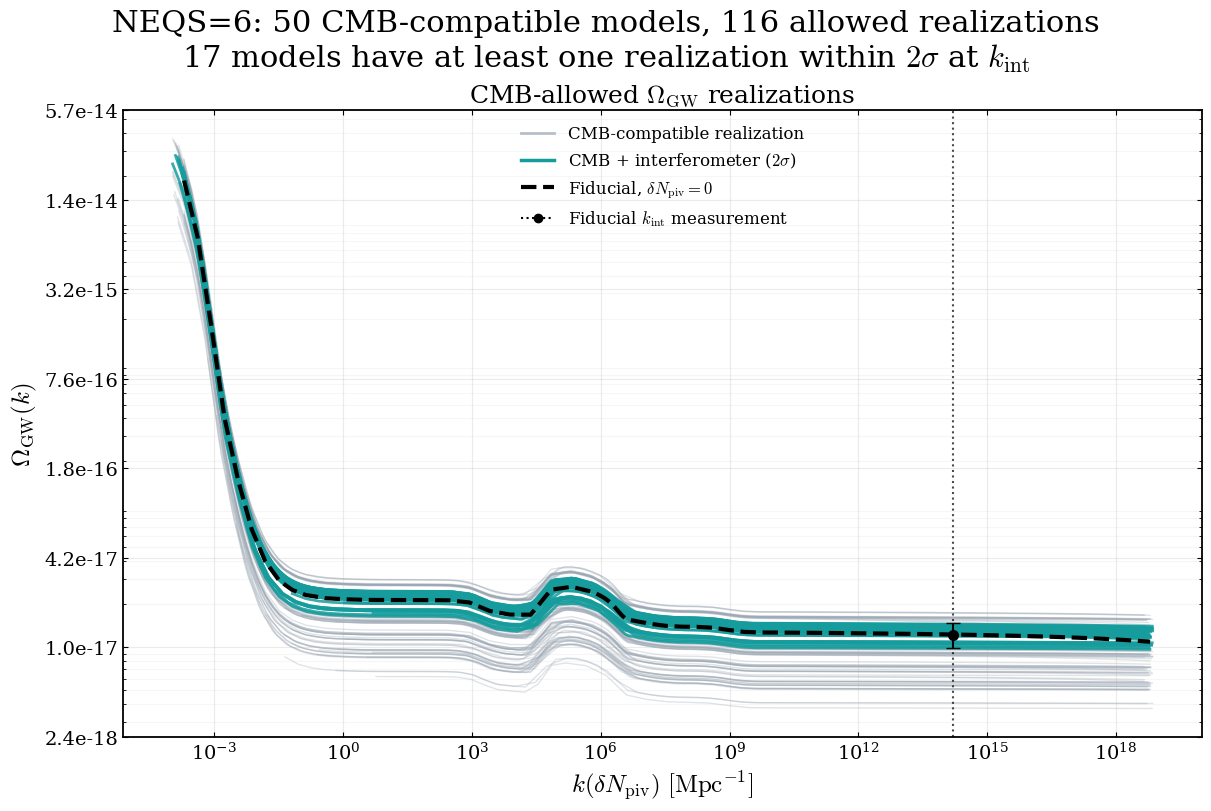


INTERFEROMETER 2-SIGMA COMPATIBILITY
Fiducial Omega(k_int)    : 1.229407e-17
1-sigma uncertainty      : 1.229407e-18
2-sigma interval         : [9.835259e-18, 1.475289e-17]
CMB-compatible models    : 50
Allowed realizations     : 116
2-sigma realizations     : 40
Models passing 2-sigma   : 17
Passing model indices    : [0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266, 327, 361]
Merged TF range          : [1.000000e-04, 7.178160e+18] Mpc^-1

Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


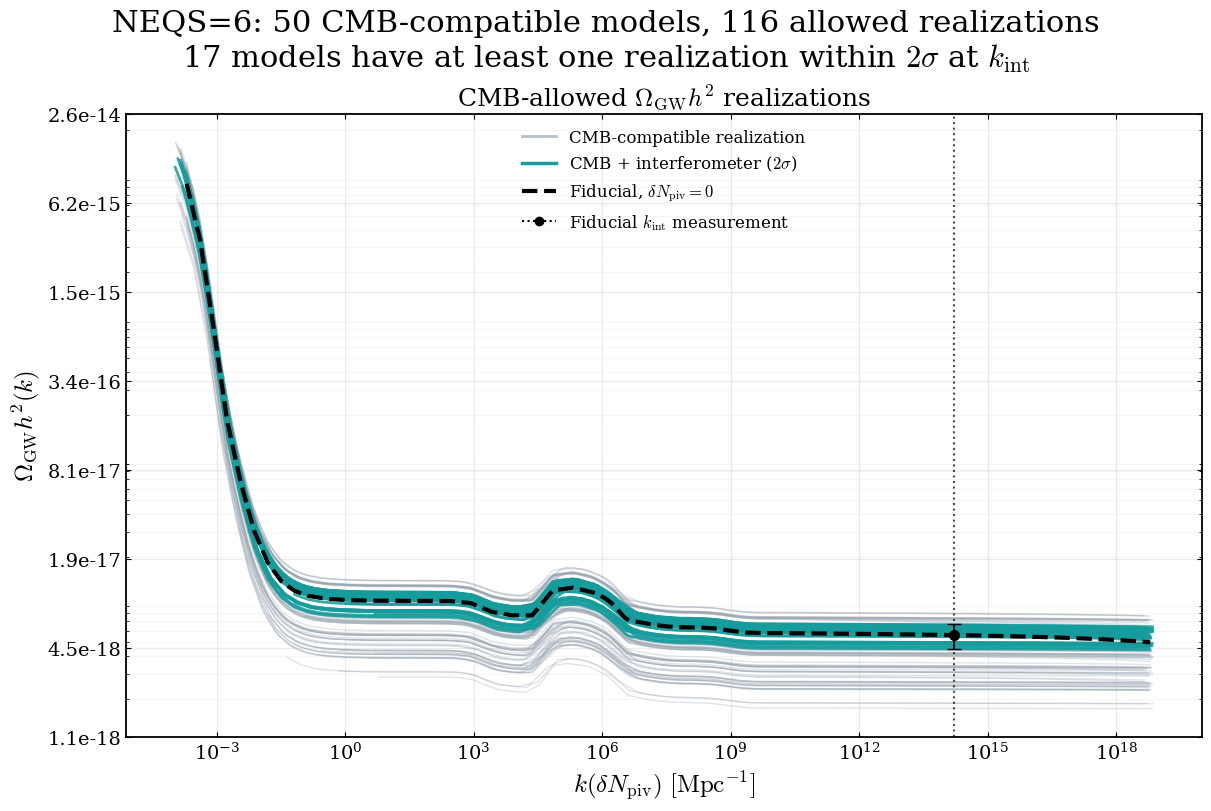


INTERFEROMETER 2-SIGMA COMPATIBILITY
Fiducial Omega(k_int)    : 1.229407e-17
1-sigma uncertainty      : 1.229407e-18
2-sigma interval         : [9.835259e-18, 1.475289e-17]
CMB-compatible models    : 50
Allowed realizations     : 116
2-sigma realizations     : 40
Models passing 2-sigma   : 17
Passing model indices    : [0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266, 327, 361]
Merged TF range          : [1.000000e-04, 7.178160e+18] Mpc^-1


In [41]:
results = plot_all_allowed_omegaGW(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=False,
)

results = plot_all_allowed_omegaGW(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=True,
)

# Plot 11: CMB + Interferometry + Astrometry ($2 \sigma$)

In [42]:
def plot_all_allowed_omegaGW_int_ast(
    cmb_passing_models,
    fiducial_measurements,
    NEQS=6,
    h=0.675,
    plot_h2=False,
    tf_file=None,
    save_name=None,
):
    """
    Plot every CMB-allowed Omega_GW realization using the merged
    Kite + Saikawa-Shirai transfer function.

    Colors:

        gray:
            CMB-compatible only

        teal:
            CMB-compatible AND within 2 sigma of the
            fiducial interferometer measurement

        purple:
            CMB-compatible AND within 2 sigma of BOTH
            the fiducial interferometer measurement
            and fiducial astrometry measurement

        black dashed:
            fiducial base model at deltaN_piv = 0

    Merged transfer-function convention:

        T_Omega(k) = Omega_GW(k) / P_T(k)

    so that

        Omega_GW(k) = T_Omega(k) * P_T(k)

        Omega_GW h^2 = h^2 * Omega_GW(k)

    Also returns a per-model survival table containing:

        - number of CMB-allowed deltaN_piv realizations
        - number passing interferometer 2 sigma
        - number passing joint interferometer + astrometry 2 sigma
        - corresponding survival fractions
    """

    # ========================================================
    # 0. Merged transfer-function file
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    else:

        tf_file = Path(tf_file)

    if not tf_file.exists():

        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )


    # ========================================================
    # Fiducial measurements
    # ========================================================

    fiducial_model_index = int(
        fiducial_measurements["model_index"]
    )


    # --------------------------------------------------------
    # Interferometer
    # --------------------------------------------------------

    k_int = float(
        fiducial_measurements["k_int"]
    )

    Omega_fid_int = float(
        fiducial_measurements["Omega_meas_int"]
    )

    sigma_Omega_int = float(
        fiducial_measurements["sigma_Omega_int"]
    )

    Omega_int_min = (
        Omega_fid_int
        - 2.0 * sigma_Omega_int
    )

    Omega_int_max = (
        Omega_fid_int
        + 2.0 * sigma_Omega_int
    )


    # --------------------------------------------------------
    # Astrometry
    # --------------------------------------------------------

    k_ast = float(
        fiducial_measurements["k_ast"]
    )

    Omega_fid_ast = float(
        fiducial_measurements["Omega_meas_ast"]
    )

    sigma_Omega_ast = float(
        fiducial_measurements["sigma_Omega_ast"]
    )

    Omega_ast_min = (
        Omega_fid_ast
        - 2.0 * sigma_Omega_ast
    )

    Omega_ast_max = (
        Omega_fid_ast
        + 2.0 * sigma_Omega_ast
    )


    # ========================================================
    # Prepare merged transfer function
    #
    # Columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # ========================================================

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[
        good_tf
    ]

    tf_f = tf_f[
        good_tf
    ]

    tf_T = tf_T[
        good_tf
    ]


    # --------------------------------------------------------
    # Ensure monotonic k
    # --------------------------------------------------------

    dktf = np.diff(
        tf_k
    )

    if np.all(dktf > 0):

        pass

    elif np.all(dktf < 0):

        tf_k = tf_k[::-1]
        tf_f = tf_f[::-1]
        tf_T = tf_T[::-1]

    else:

        raise ValueError(
            "Transfer-function k array is non-monotonic."
        )


    # --------------------------------------------------------
    # Log-log interpolation
    # --------------------------------------------------------

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]


    print("\nMerged transfer function")
    print(f"file       : {tf_file}")
    print(
        f"k range    : "
        f"{kmin_tf:.6e} -> {kmax_tf:.6e} Mpc^-1"
    )
    print(
        "convention : T(k) = Omega_GW / P_T"
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8),
        constrained_layout=True,
    )


    # ========================================================
    # Colors
    # ========================================================

    cmb_color = "#AAB4BE"
    interferometer_color = "#169C9C"
    astrometry_color = "#8A5FB5"
    fiducial_color = "black"


    # ========================================================
    # Global counters
    # ========================================================

    total_curves = 0

    interferometer_curves = 0

    joint_curves = 0


    interferometer_model_indices = set()

    joint_model_indices = set()


    model_summary_records = []


    # ========================================================
    # Loop through CMB-passing models
    # ========================================================

    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        # ====================================================
        # Reset per-model counters
        # ====================================================

        model_total = 0

        model_int_pass = 0

        model_joint_pass = 0


        # ----------------------------------------------------
        # Load tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )


        k_raw = np.asarray(
            tensor_data[:, 0],
            dtype=float,
        )

        # h/Mpc -> Mpc^-1
        k_raw = (
            k_raw
            * h
        )


        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[
            good
        ]

        Pt_raw = Pt_raw[
            good
        ]


        # ----------------------------------------------------
        # Preserve physical k-P pairing
        # ----------------------------------------------------

        dk = np.diff(
            k_raw
        )

        if np.all(dk > 0):

            pass

        elif np.all(dk < 0):

            k_raw = k_raw[::-1]

            Pt_raw = Pt_raw[::-1]

        else:

            raise ValueError(
                f"Model {model_index}: "
                "tensor k grid is non-monotonic."
            )


        # ====================================================
        # CMB-compatible realizations
        # ====================================================

        pass_mask = curves[
            "cmb_pass_mask"
        ]


        allowed_N = curves["N"][
            pass_mask
        ]


        allowed_deltaN = curves[
            "deltaN_piv"
        ][
            pass_mask
        ]


        # ====================================================
        # Loop through every allowed realization
        # ====================================================

        for N_eval, deltaN in zip(
            allowed_N,
            allowed_deltaN,
        ):


            # ------------------------------------------------
            # Shift k
            # ------------------------------------------------

            k_shifted = (
                k_raw
                * np.exp(
                    -deltaN
                )
            )


            # ------------------------------------------------
            # Transfer-function overlap
            # ------------------------------------------------

            overlap = (
                (k_shifted >= kmin_tf)
                & (k_shifted <= kmax_tf)
            )


            k_use = k_shifted[
                overlap
            ]


            Pt_use = Pt_raw[
                overlap
            ]


            if len(k_use) < 5:

                continue


            # ------------------------------------------------
            # Evaluate merged transfer function
            # ------------------------------------------------

            T_use = np.exp(
                logT_interp(
                    np.log(
                        k_use
                    )
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )


            k_use = k_use[
                valid
            ]


            Pt_use = Pt_use[
                valid
            ]


            T_use = T_use[
                valid
            ]


            if len(k_use) < 5:

                continue


            # =================================================
            # Omega_GW
            #
            # merged TF:
            #
            #     T(k) = Omega_GW / P_T
            #
            # therefore:
            #
            #     Omega_GW = T(k) * P_T
            #
            #     Omega_GW h^2 = h^2 Omega_GW
            # =================================================

            OmegaGW = (
                T_use
                * Pt_use
            )


            OmegaGW_h2 = (
                h**2
                * OmegaGW
            )


            # =================================================
            # Interpolate this realization
            # =================================================

            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                kind="linear",
                bounds_error=False,
                fill_value=np.nan,
            )


            # =================================================
            # Evaluate at interferometer scale
            # =================================================

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_k_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_k_int = np.nan


            passes_interferometer = (
                np.isfinite(
                    Omega_at_k_int
                )
                and
                Omega_int_min
                <= Omega_at_k_int
                <= Omega_int_max
            )


            # =================================================
            # Evaluate at astrometry scale
            # =================================================

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_k_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_k_ast = np.nan


            passes_astrometry = (
                np.isfinite(
                    Omega_at_k_ast
                )
                and
                Omega_ast_min
                <= Omega_at_k_ast
                <= Omega_ast_max
            )


            # =================================================
            # Joint compatibility
            # =================================================

            passes_joint = (
                passes_interferometer
                and
                passes_astrometry
            )


            # =================================================
            # Choose y-axis
            # =================================================

            if plot_h2:

                yplot = OmegaGW_h2

            else:

                yplot = OmegaGW


            # =================================================
            # Fiducial realization
            # =================================================

            is_fiducial = (
                model_index
                == fiducial_model_index
                and
                np.isclose(
                    deltaN,
                    0.0,
                    atol=1e-8,
                )
            )


            # =================================================
            # Plot
            # =================================================

            if is_fiducial:

                ax.loglog(
                    k_use,
                    yplot,
                    color=fiducial_color,
                    lw=3.0,
                    ls="--",
                    alpha=1.0,
                    zorder=10,
                )


            elif passes_joint:

                ax.loglog(
                    k_use,
                    yplot,
                    color=astrometry_color,
                    lw=2.2,
                    alpha=0.90,
                    zorder=4,
                )


            elif passes_interferometer:

                ax.loglog(
                    k_use,
                    yplot,
                    color=interferometer_color,
                    lw=1.8,
                    alpha=0.80,
                    zorder=3,
                )


            else:

                ax.loglog(
                    k_use,
                    yplot,
                    color=cmb_color,
                    lw=1.0,
                    alpha=0.25,
                    zorder=1,
                )


            # =================================================
            # Global counts
            # =================================================

            total_curves += 1


            if passes_interferometer:

                interferometer_curves += 1

                interferometer_model_indices.add(
                    model_index
                )


            if passes_joint:

                joint_curves += 1

                joint_model_indices.add(
                    model_index
                )


            # =================================================
            # Per-model counts
            # =================================================

            model_total += 1


            if passes_interferometer:

                model_int_pass += 1


            if passes_joint:

                model_joint_pass += 1


        # ====================================================
        # Store per-model summary
        # ====================================================

        model_summary_records.append({

            "model_index":
                model_index,

            "allowed_deltaN_realizations":
                model_total,

            "interferometer_2sigma":
                model_int_pass,

            "joint_int_ast_2sigma":
                model_joint_pass,

            "fraction_interferometer": (
                model_int_pass
                / model_total
                if model_total > 0
                else np.nan
            ),

            "fraction_joint": (
                model_joint_pass
                / model_total
                if model_total > 0
                else np.nan
            ),
        })


    # ========================================================
    # Fiducial measurement markers
    # ========================================================

    if plot_h2:

        Omega_fid_int_plot = (
            Omega_fid_int
            * h**2
        )

        sigma_int_plot = (
            sigma_Omega_int
            * h**2
        )


        Omega_fid_ast_plot = (
            Omega_fid_ast
            * h**2
        )

        sigma_ast_plot = (
            sigma_Omega_ast
            * h**2
        )


    else:

        Omega_fid_int_plot = (
            Omega_fid_int
        )

        sigma_int_plot = (
            sigma_Omega_int
        )


        Omega_fid_ast_plot = (
            Omega_fid_ast
        )

        sigma_ast_plot = (
            sigma_Omega_ast
        )


    # --------------------------------------------------------
    # Interferometer mock measurement
    # --------------------------------------------------------

    ax.errorbar(
        k_int,
        Omega_fid_int_plot,
        yerr=2.0 * sigma_int_plot,
        fmt="o",
        color=interferometer_color,
        markersize=7,
        capsize=5,
        zorder=12,
    )


    # --------------------------------------------------------
    # Astrometry mock measurement
    # --------------------------------------------------------

    ax.errorbar(
        k_ast,
        Omega_fid_ast_plot,
        yerr=2.0 * sigma_ast_plot,
        fmt="s",
        color=astrometry_color,
        markersize=7,
        capsize=5,
        zorder=12,
    )


    # ========================================================
    # Legend
    # ========================================================

    cmb_handle = Line2D(
        [0],
        [0],
        color=cmb_color,
        lw=2.0,
        label="CMB compatible",
    )


    int_handle = Line2D(
        [0],
        [0],
        color=interferometer_color,
        lw=2.5,
        label=(
            r"CMB + interferometer "
            r"($2\sigma$)"
        ),
    )


    ast_handle = Line2D(
        [0],
        [0],
        color=astrometry_color,
        lw=2.5,
        label=(
            r"CMB + interferometer + astrometry "
            r"($2\sigma$)"
        ),
    )


    fid_handle = Line2D(
        [0],
        [0],
        color=fiducial_color,
        lw=3.0,
        ls="--",
        label=(
            r"Fiducial, "
            r"$\delta N_{\rm piv}=0$"
        ),
    )


    ax.legend(
        handles=[
            cmb_handle,
            int_handle,
            ast_handle,
            fid_handle,
        ],
        frameon=False,
        loc="best",
    )


    # ========================================================
    # Axes
    # ========================================================

    ax.set_xlabel(
        r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
    )


    if plot_h2:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}h^2(k)$"
        )

        ax.set_title(
            r"CMB + interferometer + astrometry constraints "
            r"on $\Omega_{\rm GW}h^2$"
        )


    else:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}(k)$"
        )

        ax.set_title(
            r"CMB + interferometer + astrometry constraints "
            r"on $\Omega_{\rm GW}$"
        )


    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )


    ax.grid(
        True,
        which="minor",
        alpha=0.10,
    )


    yticks = np.geomspace(
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        8,
    )

    ax.set_yticks(
        yticks
    )

    ax.set_yticklabels(
        [
            f"{y:.1e}"
            for y in yticks
        ]
    )


    # ========================================================
    # Title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: "
        rf"{total_curves} CMB-allowed realizations"
        "\n"
        rf"{len(interferometer_model_indices)} models pass interferometer; "
        rf"{len(joint_model_indices)} pass interferometer + astrometry"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        suffix = (
            "h2"
            if plot_h2
            else "plain"
        )


        save_name = (
            f"CMB_int_ast_"
            f"OmegaGW_{suffix}_"
            f"mergedTF_"
            f"neqs{NEQS}_2sig.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    # ========================================================
    # Build compact per-model survival table
    # ========================================================

    model_survival_table = pd.DataFrame(
        model_summary_records
    )


    model_survival_table[
        "fraction_interferometer"
    ] = model_survival_table[
        "fraction_interferometer"
    ].round(3)


    model_survival_table[
        "fraction_joint"
    ] = model_survival_table[
        "fraction_joint"
    ].round(3)


    # ========================================================
    # Print summary
    # ========================================================

    print("\n" + "=" * 72)

    print(
        "CMB + INTERFEROMETER + ASTROMETRY"
    )

    print("=" * 72)


    print(
        f"CMB-compatible models          : "
        f"{len(cmb_passing_models)}"
    )


    print(
        f"CMB-compatible realizations    : "
        f"{total_curves}"
    )


    print(
        f"Interferometer 2sigma curves   : "
        f"{interferometer_curves}"
    )


    print(
        f"Interferometer 2sigma models   : "
        f"{len(interferometer_model_indices)}"
    )


    print(
        f"Joint int + ast 2sigma curves  : "
        f"{joint_curves}"
    )


    print(
        f"Joint int + ast 2sigma models  : "
        f"{len(joint_model_indices)}"
    )


    print(
        "\nInterferometer-compatible models:"
    )

    print(
        sorted(
            interferometer_model_indices
        )
    )


    print(
        "\nInterferometer + astrometry compatible models:"
    )

    print(
        sorted(
            joint_model_indices
        )
    )


    print(
        f"\nMerged TF range               : "
        f"[{kmin_tf:.6e}, "
        f"{kmax_tf:.6e}] Mpc^-1"
    )


    # ========================================================
    # Return everything
    # ========================================================

    return {

        "total_realizations":
            total_curves,

        "interferometer_realizations":
            interferometer_curves,

        "joint_realizations":
            joint_curves,

        "interferometer_model_indices":
            sorted(
                interferometer_model_indices
            ),

        "joint_model_indices":
            sorted(
                joint_model_indices
            ),

        "Omega_int_min":
            Omega_int_min,

        "Omega_int_max":
            Omega_int_max,

        "Omega_ast_min":
            Omega_ast_min,

        "Omega_ast_max":
            Omega_ast_max,

        "model_survival_table":
            model_survival_table,
    }


Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


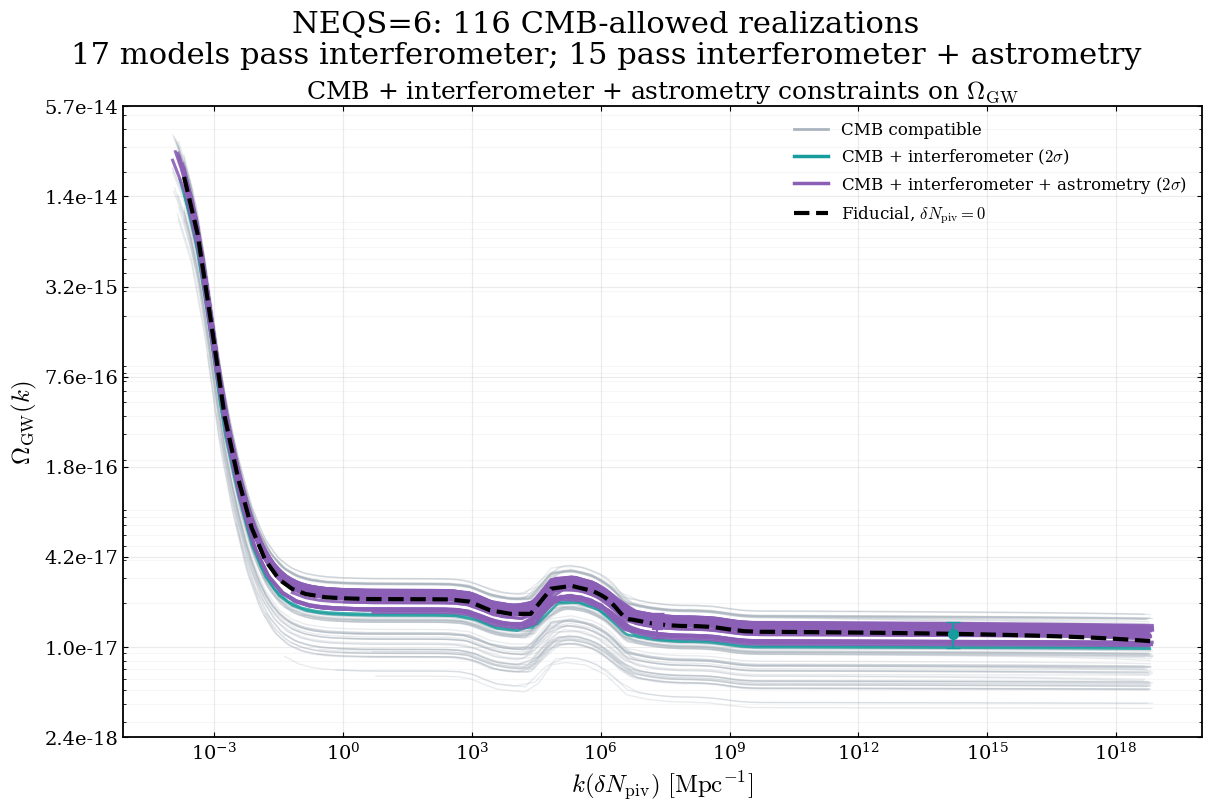


CMB + INTERFEROMETER + ASTROMETRY
CMB-compatible models          : 50
CMB-compatible realizations    : 116
Interferometer 2sigma curves   : 41
Interferometer 2sigma models   : 17
Joint int + ast 2sigma curves  : 39
Joint int + ast 2sigma models  : 15

Interferometer-compatible models:
[0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266, 327, 361]

Interferometer + astrometry compatible models:
[0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266]

Merged TF range               : [1.000000e-04, 7.178160e+18] Mpc^-1

Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


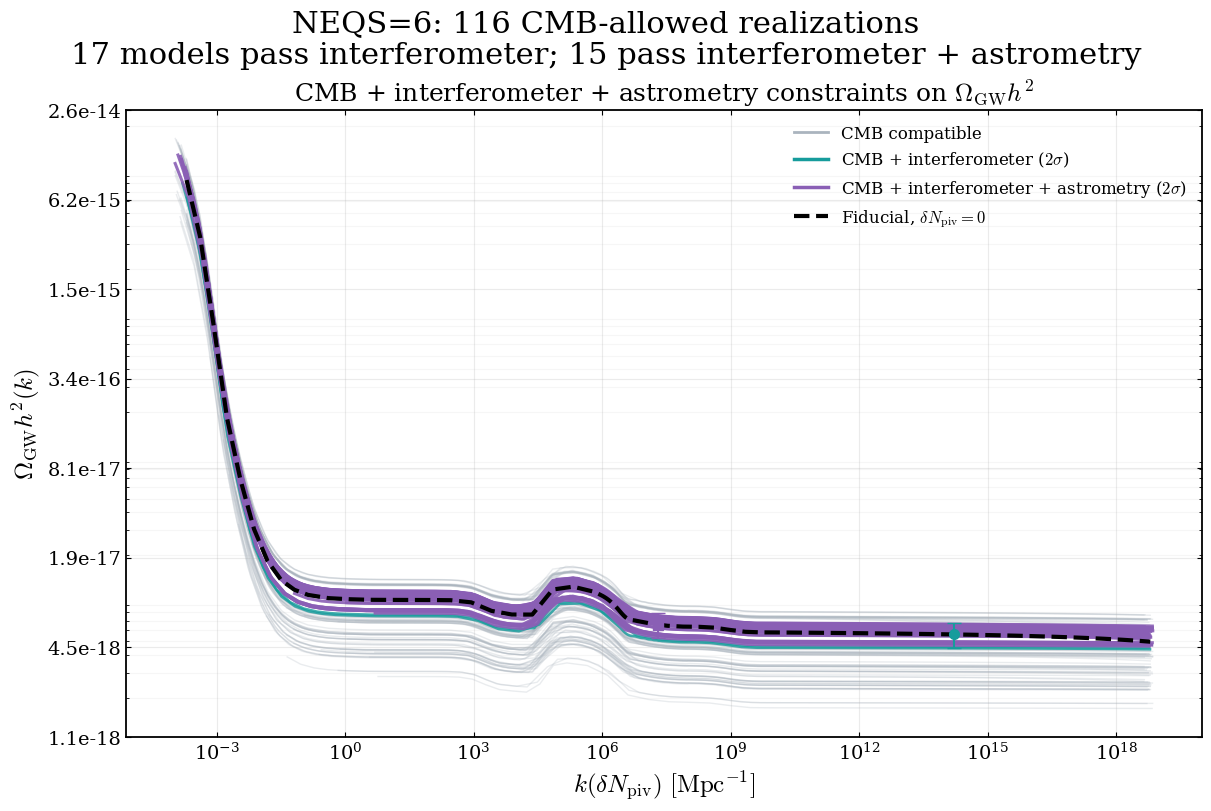


CMB + INTERFEROMETER + ASTROMETRY
CMB-compatible models          : 50
CMB-compatible realizations    : 116
Interferometer 2sigma curves   : 41
Interferometer 2sigma models   : 17
Joint int + ast 2sigma curves  : 39
Joint int + ast 2sigma models  : 15

Interferometer-compatible models:
[0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266, 327, 361]

Interferometer + astrometry compatible models:
[0, 1, 37, 53, 55, 77, 88, 121, 158, 161, 172, 187, 197, 260, 266]

Merged TF range               : [1.000000e-04, 7.178160e+18] Mpc^-1


In [43]:
joint_result = plot_all_allowed_omegaGW_int_ast(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=False,
)

joint_result = plot_all_allowed_omegaGW_int_ast(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=True,
)

The above numbers tell me which models drop out for the $2 \sigma$ case. As you can see, most of the models that are interferometry compatible are also astrometry compatible as well.

One surviving realization is enough to include the model. The set is not tracking how many times a value gets added just that it exists at the appropriate scale. A model only needs one favorable pivot-mapping choice out of its whole uncertainty range to count as compatible. If a model is excluded it means there is not a possible pivot shift for which the model matches.Fraction joint in the survival table gives me what fraction of a model's realizations survive.

# Plot 12: CMB + Interferometry + Astrometry ($1 \sigma$)

In [44]:
def plot_all_allowed_omegaGW_int_ast_1sig(
    cmb_passing_models,
    fiducial_measurements,
    NEQS=6,
    h=0.675,
    plot_h2=False,
    tf_file=None,
    save_name=None,
):
    """
    Plot every CMB-allowed Omega_GW realization using the merged
    Kite + Saikawa-Shirai transfer function.

    Colors:

        gray:
            CMB-compatible only

        teal:
            CMB-compatible AND within 1 sigma of the
            fiducial interferometer measurement

        purple:
            CMB-compatible AND within 1 sigma of BOTH
            the fiducial interferometer measurement
            and fiducial astrometry measurement

        black dashed:
            fiducial base model at deltaN_piv = 0

    Merged transfer-function convention:

        T_Omega(k) = Omega_GW(k) / P_T(k)

    so that

        Omega_GW(k) = T_Omega(k) * P_T(k)

        Omega_GW h^2 = h^2 * Omega_GW(k)

    Also returns a per-model survival table containing:

        - number of CMB-allowed deltaN_piv realizations
        - number passing interferometer 1 sigma
        - number passing joint interferometer + astrometry 1 sigma
        - corresponding survival fractions
    """

    # ========================================================
    # 0. Merged transfer-function file
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    else:

        tf_file = Path(tf_file)

    if not tf_file.exists():

        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )


    # ========================================================
    # Fiducial measurements
    # ========================================================

    fiducial_model_index = int(
        fiducial_measurements["model_index"]
    )


    # --------------------------------------------------------
    # Interferometer
    # --------------------------------------------------------

    k_int = float(
        fiducial_measurements["k_int"]
    )

    Omega_fid_int = float(
        fiducial_measurements["Omega_meas_int"]
    )

    sigma_Omega_int = float(
        fiducial_measurements["sigma_Omega_int"]
    )

    Omega_int_min = (
        Omega_fid_int
        - 1.0 * sigma_Omega_int
    )

    Omega_int_max = (
        Omega_fid_int
        + 1.0 * sigma_Omega_int
    )


    # --------------------------------------------------------
    # Astrometry
    # --------------------------------------------------------

    k_ast = float(
        fiducial_measurements["k_ast"]
    )

    Omega_fid_ast = float(
        fiducial_measurements["Omega_meas_ast"]
    )

    sigma_Omega_ast = float(
        fiducial_measurements["sigma_Omega_ast"]
    )

    Omega_ast_min = (
        Omega_fid_ast
        - 1.0 * sigma_Omega_ast
    )

    Omega_ast_max = (
        Omega_fid_ast
        + 1.0 * sigma_Omega_ast
    )


    # ========================================================
    # Prepare merged transfer function
    #
    # Columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # ========================================================

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_f = np.asarray(
        tf_data[:, 1],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_f)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_f > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[
        good_tf
    ]

    tf_f = tf_f[
        good_tf
    ]

    tf_T = tf_T[
        good_tf
    ]


    # --------------------------------------------------------
    # Ensure monotonic k
    # --------------------------------------------------------

    dktf = np.diff(
        tf_k
    )

    if np.all(dktf > 0):

        pass

    elif np.all(dktf < 0):

        tf_k = tf_k[::-1]
        tf_f = tf_f[::-1]
        tf_T = tf_T[::-1]

    else:

        raise ValueError(
            "Transfer-function k array is non-monotonic."
        )


    # --------------------------------------------------------
    # Log-log interpolation
    # --------------------------------------------------------

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]


    print("\nMerged transfer function")
    print(f"file       : {tf_file}")
    print(
        f"k range    : "
        f"{kmin_tf:.6e} -> {kmax_tf:.6e} Mpc^-1"
    )
    print(
        "convention : T(k) = Omega_GW / P_T"
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8),
        constrained_layout=True,
    )


    # ========================================================
    # Colors
    # ========================================================

    cmb_color = "#AAB4BE"

    interferometer_color = "#169C9C"

    astrometry_color = "#8A5FB5"

    fiducial_color = "black"


    # ========================================================
    # Global counters
    # ========================================================

    total_curves = 0

    interferometer_curves = 0

    joint_curves = 0


    interferometer_model_indices = set()

    joint_model_indices = set()


    model_summary_records = []


    # ========================================================
    # Loop through CMB-passing models
    # ========================================================

    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        # ====================================================
        # Reset per-model counters
        # ====================================================

        model_total = 0

        model_int_pass = 0

        model_joint_pass = 0


        # ----------------------------------------------------
        # Load tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )


        k_raw = np.asarray(
            tensor_data[:, 0],
            dtype=float,
        )

        # h/Mpc -> Mpc^-1
        k_raw = (
            k_raw
            * h
        )


        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[
            good
        ]

        Pt_raw = Pt_raw[
            good
        ]


        # ----------------------------------------------------
        # Preserve physical k-P pairing
        # ----------------------------------------------------

        dk = np.diff(
            k_raw
        )

        if np.all(dk > 0):

            pass

        elif np.all(dk < 0):

            k_raw = k_raw[::-1]

            Pt_raw = Pt_raw[::-1]

        else:

            raise ValueError(
                f"Model {model_index}: "
                "tensor k grid is non-monotonic."
            )


        # ====================================================
        # CMB-compatible realizations
        # ====================================================

        pass_mask = curves[
            "cmb_pass_mask"
        ]


        allowed_N = curves["N"][
            pass_mask
        ]


        allowed_deltaN = curves[
            "deltaN_piv"
        ][
            pass_mask
        ]


        # ====================================================
        # Loop through every allowed realization
        # ====================================================

        for N_eval, deltaN in zip(
            allowed_N,
            allowed_deltaN,
        ):


            # ------------------------------------------------
            # Shift k
            # ------------------------------------------------

            k_shifted = (
                k_raw
                * np.exp(
                    -deltaN
                )
            )


            # ------------------------------------------------
            # Transfer-function overlap
            # ------------------------------------------------

            overlap = (
                (k_shifted >= kmin_tf)
                & (k_shifted <= kmax_tf)
            )


            k_use = k_shifted[
                overlap
            ]


            Pt_use = Pt_raw[
                overlap
            ]


            if len(k_use) < 5:

                continue


            # ------------------------------------------------
            # Evaluate merged transfer function
            # ------------------------------------------------

            T_use = np.exp(
                logT_interp(
                    np.log(
                        k_use
                    )
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )


            k_use = k_use[
                valid
            ]


            Pt_use = Pt_use[
                valid
            ]


            T_use = T_use[
                valid
            ]


            if len(k_use) < 5:

                continue


            # =================================================
            # Omega_GW
            #
            # merged TF:
            #
            #     T(k) = Omega_GW / P_T
            #
            # therefore:
            #
            #     Omega_GW = T(k) * P_T
            #
            #     Omega_GW h^2 = h^2 Omega_GW
            # =================================================

            OmegaGW = (
                T_use
                * Pt_use
            )


            OmegaGW_h2 = (
                h**2
                * OmegaGW
            )


            # =================================================
            # Interpolate this realization
            # =================================================

            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                kind="linear",
                bounds_error=False,
                fill_value=np.nan,
            )


            # =================================================
            # Evaluate at interferometer scale
            # =================================================

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_k_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_k_int = np.nan


            passes_interferometer = (
                np.isfinite(
                    Omega_at_k_int
                )
                and
                Omega_int_min
                <= Omega_at_k_int
                <= Omega_int_max
            )


            # =================================================
            # Evaluate at astrometry scale
            # =================================================

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_k_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_k_ast = np.nan


            passes_astrometry = (
                np.isfinite(
                    Omega_at_k_ast
                )
                and
                Omega_ast_min
                <= Omega_at_k_ast
                <= Omega_ast_max
            )


            # =================================================
            # Joint compatibility
            # =================================================

            passes_joint = (
                passes_interferometer
                and
                passes_astrometry
            )


            # =================================================
            # Choose y-axis
            # =================================================

            if plot_h2:

                yplot = OmegaGW_h2

            else:

                yplot = OmegaGW


            # =================================================
            # Fiducial realization
            # =================================================

            is_fiducial = (
                model_index
                == fiducial_model_index
                and
                np.isclose(
                    deltaN,
                    0.0,
                    atol=1e-8,
                )
            )


            # =================================================
            # Plot
            # =================================================

            if is_fiducial:

                ax.loglog(
                    k_use,
                    yplot,
                    color=fiducial_color,
                    lw=3.0,
                    ls="--",
                    alpha=1.0,
                    zorder=10,
                )


            elif passes_joint:

                ax.loglog(
                    k_use,
                    yplot,
                    color=astrometry_color,
                    lw=2.2,
                    alpha=0.90,
                    zorder=4,
                )


            elif passes_interferometer:

                ax.loglog(
                    k_use,
                    yplot,
                    color=interferometer_color,
                    lw=1.8,
                    alpha=0.80,
                    zorder=3,
                )


            else:

                ax.loglog(
                    k_use,
                    yplot,
                    color=cmb_color,
                    lw=1.0,
                    alpha=0.25,
                    zorder=1,
                )


            # =================================================
            # Global counts
            # =================================================

            total_curves += 1


            if passes_interferometer:

                interferometer_curves += 1

                interferometer_model_indices.add(
                    model_index
                )


            if passes_joint:

                joint_curves += 1

                joint_model_indices.add(
                    model_index
                )


            # =================================================
            # Per-model counts
            # =================================================

            model_total += 1


            if passes_interferometer:

                model_int_pass += 1


            if passes_joint:

                model_joint_pass += 1


        # ====================================================
        # Store per-model summary
        # ====================================================

        model_summary_records.append({

            "model_index":
                model_index,

            "allowed_deltaN_realizations":
                model_total,

            "interferometer_1sigma":
                model_int_pass,

            "joint_int_ast_1sigma":
                model_joint_pass,

            "fraction_interferometer": (
                model_int_pass
                / model_total
                if model_total > 0
                else np.nan
            ),

            "fraction_joint": (
                model_joint_pass
                / model_total
                if model_total > 0
                else np.nan
            ),
        })


    # ========================================================
    # Fiducial measurement markers
    # ========================================================

    if plot_h2:

        Omega_fid_int_plot = (
            Omega_fid_int
            * h**2
        )

        sigma_int_plot = (
            sigma_Omega_int
            * h**2
        )


        Omega_fid_ast_plot = (
            Omega_fid_ast
            * h**2
        )

        sigma_ast_plot = (
            sigma_Omega_ast
            * h**2
        )


    else:

        Omega_fid_int_plot = (
            Omega_fid_int
        )

        sigma_int_plot = (
            sigma_Omega_int
        )


        Omega_fid_ast_plot = (
            Omega_fid_ast
        )

        sigma_ast_plot = (
            sigma_Omega_ast
        )


    # --------------------------------------------------------
    # Interferometer mock measurement: 1 sigma
    # --------------------------------------------------------

    ax.errorbar(
        k_int,
        Omega_fid_int_plot,
        yerr=1.0 * sigma_int_plot,
        fmt="o",
        color=interferometer_color,
        markersize=7,
        capsize=5,
        zorder=12,
    )


    # --------------------------------------------------------
    # Astrometry mock measurement: 1 sigma
    # --------------------------------------------------------

    ax.errorbar(
        k_ast,
        Omega_fid_ast_plot,
        yerr=1.0 * sigma_ast_plot,
        fmt="s",
        color=astrometry_color,
        markersize=7,
        capsize=5,
        zorder=12,
    )


    # ========================================================
    # Legend
    # ========================================================

    cmb_handle = Line2D(
        [0],
        [0],
        color=cmb_color,
        lw=2.0,
        label="CMB compatible",
    )


    int_handle = Line2D(
        [0],
        [0],
        color=interferometer_color,
        lw=2.5,
        label=(
            r"CMB + interferometer "
            r"($1\sigma$)"
        ),
    )


    ast_handle = Line2D(
        [0],
        [0],
        color=astrometry_color,
        lw=2.5,
        label=(
            r"CMB + interferometer + astrometry "
            r"($1\sigma$)"
        ),
    )


    fid_handle = Line2D(
        [0],
        [0],
        color=fiducial_color,
        lw=3.0,
        ls="--",
        label=(
            r"Fiducial, "
            r"$\delta N_{\rm piv}=0$"
        ),
    )


    ax.legend(
        handles=[
            cmb_handle,
            int_handle,
            ast_handle,
            fid_handle,
        ],
        frameon=False,
        loc="best",
    )


    # ========================================================
    # Axes
    # ========================================================

    ax.set_xlabel(
        r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
    )


    if plot_h2:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}h^2(k)$"
        )

        ax.set_title(
            r"CMB + interferometer + astrometry constraints "
            r"on $\Omega_{\rm GW}h^2$"
        )


    else:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}(k)$"
        )

        ax.set_title(
            r"CMB + interferometer + astrometry constraints "
            r"on $\Omega_{\rm GW}$"
        )


    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )


    ax.grid(
        True,
        which="minor",
        alpha=0.10,
    )


    yticks = np.geomspace(
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        8,
    )

    ax.set_yticks(
        yticks
    )

    ax.set_yticklabels(
        [
            f"{y:.1e}"
            for y in yticks
        ]
    )


    # ========================================================
    # Title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: "
        rf"{total_curves} CMB-allowed realizations"
        "\n"
        rf"{len(interferometer_model_indices)} models pass interferometer; "
        rf"{len(joint_model_indices)} pass interferometer + astrometry"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        suffix = (
            "h2"
            if plot_h2
            else "plain"
        )


        save_name = (
            f"CMB_int_ast_"
            f"OmegaGW_{suffix}_"
            f"mergedTF_"
            f"neqs{NEQS}_1sig.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    # ========================================================
    # Build compact per-model survival table
    # ========================================================

    model_survival_table = pd.DataFrame(
        model_summary_records
    )


    model_survival_table[
        "fraction_interferometer"
    ] = model_survival_table[
        "fraction_interferometer"
    ].round(3)


    model_survival_table[
        "fraction_joint"
    ] = model_survival_table[
        "fraction_joint"
    ].round(3)


    # ========================================================
    # Print summary
    # ========================================================

    print("\n" + "=" * 72)

    print(
        "CMB + INTERFEROMETER + ASTROMETRY"
    )

    print("=" * 72)


    print(
        f"CMB-compatible models          : "
        f"{len(cmb_passing_models)}"
    )


    print(
        f"CMB-compatible realizations    : "
        f"{total_curves}"
    )


    print(
        f"Interferometer 1sigma curves   : "
        f"{interferometer_curves}"
    )


    print(
        f"Interferometer 1sigma models   : "
        f"{len(interferometer_model_indices)}"
    )


    print(
        f"Joint int + ast 1sigma curves  : "
        f"{joint_curves}"
    )


    print(
        f"Joint int + ast 1sigma models  : "
        f"{len(joint_model_indices)}"
    )


    print(
        "\nInterferometer-compatible models:"
    )

    print(
        sorted(
            interferometer_model_indices
        )
    )


    print(
        "\nInterferometer + astrometry compatible models:"
    )

    print(
        sorted(
            joint_model_indices
        )
    )


    print(
        f"\nMerged TF range               : "
        f"[{kmin_tf:.6e}, "
        f"{kmax_tf:.6e}] Mpc^-1"
    )


    # ========================================================
    # Return everything
    # ========================================================

    return {

        "total_realizations":
            total_curves,

        "interferometer_realizations":
            interferometer_curves,

        "joint_realizations":
            joint_curves,

        "interferometer_model_indices":
            sorted(
                interferometer_model_indices
            ),

        "joint_model_indices":
            sorted(
                joint_model_indices
            ),

        "Omega_int_min":
            Omega_int_min,

        "Omega_int_max":
            Omega_int_max,

        "Omega_ast_min":
            Omega_ast_min,

        "Omega_ast_max":
            Omega_ast_max,

        "model_survival_table":
            model_survival_table,
    }


Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


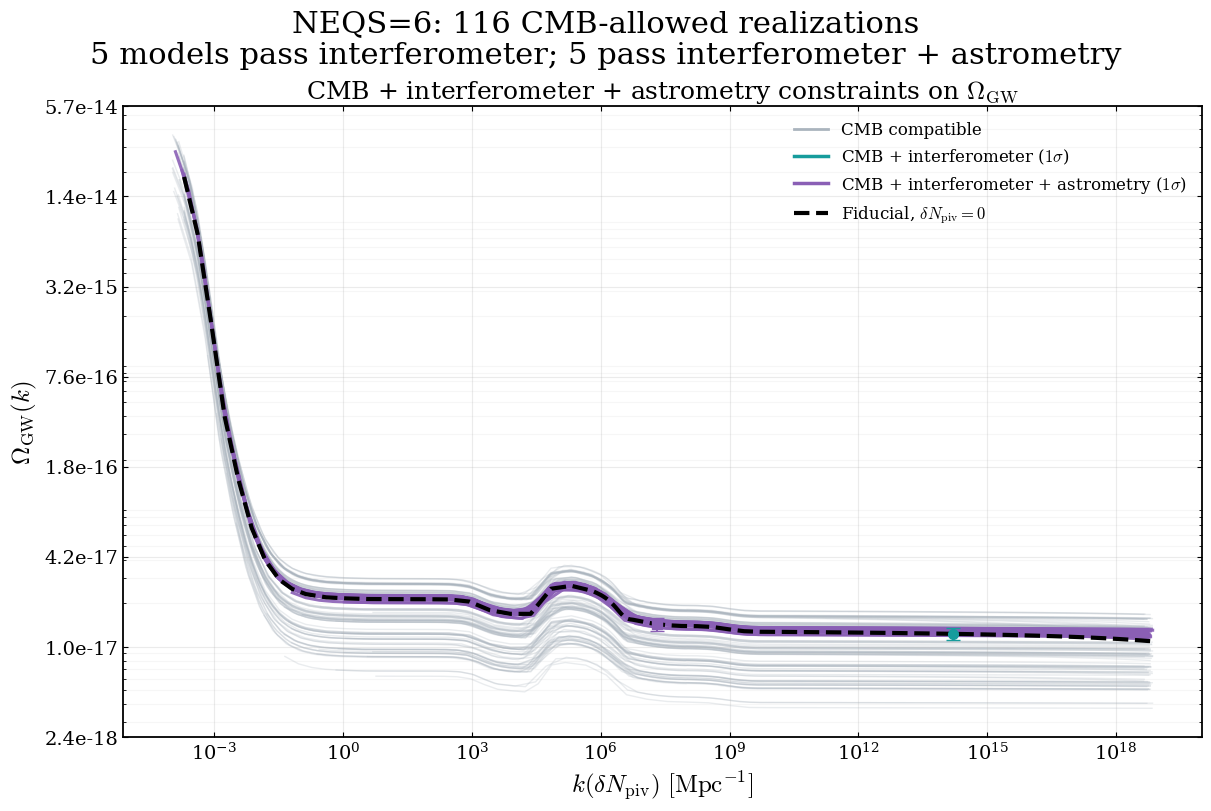


CMB + INTERFEROMETER + ASTROMETRY
CMB-compatible models          : 50
CMB-compatible realizations    : 116
Interferometer 1sigma curves   : 17
Interferometer 1sigma models   : 5
Joint int + ast 1sigma curves  : 17
Joint int + ast 1sigma models  : 5

Interferometer-compatible models:
[0, 53, 88, 172, 266]

Interferometer + astrometry compatible models:
[0, 53, 88, 172, 266]

Merged TF range               : [1.000000e-04, 7.178160e+18] Mpc^-1

Merged transfer function
file       : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function_extended.dat
k range    : 1.000000e-04 -> 7.178160e+18 Mpc^-1
convention : T(k) = Omega_GW / P_T


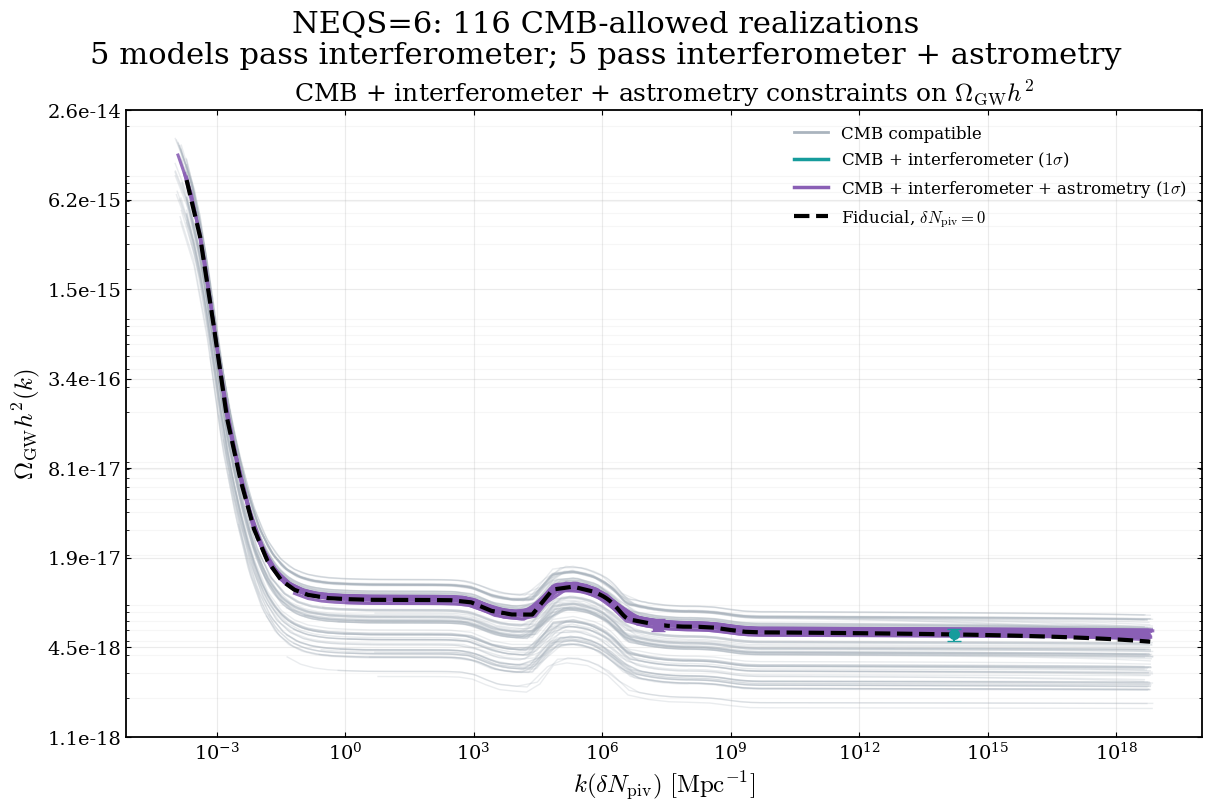


CMB + INTERFEROMETER + ASTROMETRY
CMB-compatible models          : 50
CMB-compatible realizations    : 116
Interferometer 1sigma curves   : 17
Interferometer 1sigma models   : 5
Joint int + ast 1sigma curves  : 17
Joint int + ast 1sigma models  : 5

Interferometer-compatible models:
[0, 53, 88, 172, 266]

Interferometer + astrometry compatible models:
[0, 53, 88, 172, 266]

Merged TF range               : [1.000000e-04, 7.178160e+18] Mpc^-1


In [45]:
joint_result_1sig = plot_all_allowed_omegaGW_int_ast_1sig(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=False,
)

joint_result_1sig = plot_all_allowed_omegaGW_int_ast_1sig(
    cmb_passing_models=cmb_passing_models,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    h=0.675,
    plot_h2=True,
)

# Paper Method/Discussion: $n_T$


This should plot the distribution of nT after successive constraints.

# Plot 13: nT ($k_{ast}$)

In [53]:
def nT_from_Pt(k, Pt, k_target):
    """
    n_T = d ln(P_t) / d ln(k)
    evaluated at k_target.
    """

    good = (
        np.isfinite(k)
        & np.isfinite(Pt)
        & (k > 0)
        & (Pt > 0)
    )

    k = k[good]
    Pt = Pt[good]

    if len(k) < 3:
        return np.nan

    order = np.argsort(k)
    k = k[order]
    Pt = Pt[order]

    if not (k[0] <= k_target <= k[-1]):
        return np.nan

    ln_k = np.log(k)
    ln_Pt = np.log(Pt)

    nT = np.gradient(
        ln_Pt,
        ln_k
    )

    return np.interp(
        np.log(k_target),
        ln_k,
        nT,
    )

In [54]:
def plot_nT_survival_histograms_kast_joint(
    cmb_passing_models,
    fiducial_data,
    k_cmb=0.05,
    NEQS=6,
    h=0.675,
    tf_file=None,
    bins=30,
):
    """
    Plot n_T distributions after successive constraints:

        1. CMB
        2. CMB + interferometer
        3. CMB + interferometer + astrometry

    n_T is evaluated at the scale associated with each
    observational tier.
    """

    # ========================================================
    # Transfer function
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )


    tf_data = np.loadtxt(tf_file)

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good]
    tf_T = tf_T[good]


    order = np.argsort(tf_k)

    tf_k = tf_k[order]
    tf_T = tf_T[order]


    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        bounds_error=False,
        fill_value=np.nan,
    )


    # ========================================================
    # Measurement information
    # ========================================================

    k_int = float(
        fiducial_data["k_int"]
    )

    k_ast = float(
        fiducial_data["k_ast"]
    )


    Omega_int = float(
        fiducial_data["Omega_meas_int"]
    )

    sigma_int = float(
        fiducial_data["sigma_Omega_int"]
    )


    Omega_ast = float(
        fiducial_data["Omega_meas_ast"]
    )

    sigma_ast = float(
        fiducial_data["sigma_Omega_ast"]
    )


    int_min = Omega_int - 2 * sigma_int
    int_max = Omega_int + 2 * sigma_int

    ast_min = Omega_ast - 2 * sigma_ast
    ast_max = Omega_ast + 2 * sigma_ast


    # ========================================================
    # nT samples
    # ========================================================

    nT_cmb = []
    nT_int = []
    nT_joint = []


    # ========================================================
    # Loop over CMB-compatible models
    # ========================================================

    for curves in cmb_passing_models:

        # ----------------------------------------------------
        # Tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )


        tensor_data = np.loadtxt(
            tensor_file
        )


        # h/Mpc -> Mpc^-1
        k_raw = (
            np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )
            * h
        )


        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[good]
        Pt_raw = Pt_raw[good]


        order = np.argsort(k_raw)

        k_raw = k_raw[order]
        Pt_raw = Pt_raw[order]


        # ----------------------------------------------------
        # CMB-compatible deltaN realizations
        # ----------------------------------------------------

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][pass_mask]


        # ====================================================
        # Loop over realizations
        # ====================================================

        for deltaN in allowed_deltaN:

            k_shifted = (
                k_raw
                * np.exp(-deltaN)
            )


            # =================================================
            # 1. CMB
            # =================================================

            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_cmb,
            )

            if np.isfinite(nT):

                nT_cmb.append(
                    nT
                )


            # =================================================
            # Need Omega_GW to determine later survival
            # =================================================

            overlap = (
                (k_shifted >= tf_k[0])
                & (k_shifted <= tf_k[-1])
            )

            k_use = k_shifted[overlap]
            Pt_use = Pt_raw[overlap]


            if len(k_use) < 3:
                continue


            T_use = np.exp(
                logT_interp(
                    np.log(k_use)
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]


            if len(k_use) < 3:
                continue


            OmegaGW = (
                T_use
                * Pt_use
            )


            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                bounds_error=False,
                fill_value=np.nan,
            )


            # =================================================
            # 2. Interferometer cut
            # =================================================

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_int = np.nan


            passes_int = (
                np.isfinite(Omega_at_int)
                and
                int_min
                <= Omega_at_int
                <= int_max
            )


            if not passes_int:
                continue


            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_int,
            )

            if np.isfinite(nT):

                nT_int.append(
                    nT
                )


            # =================================================
            # 3. Astrometry cut
            # =================================================

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_ast = np.nan


            passes_ast = (
                np.isfinite(Omega_at_ast)
                and
                ast_min
                <= Omega_at_ast
                <= ast_max
            )


            if not passes_ast:
                continue


            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_ast,
            )

            if np.isfinite(nT):

                nT_joint.append(
                    nT
                )


    # ========================================================
    # Arrays
    # ========================================================

    nT_cmb = np.asarray(nT_cmb)
    nT_int = np.asarray(nT_int)
    nT_joint = np.asarray(nT_joint)


    # ========================================================
    # Plot
    # ========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 4.5),
        constrained_layout=True,
    )


    values = [
        nT_cmb,
        nT_int,
        nT_joint,
    ]


    titles = [

        (
            "CMB compatible\n"
            f"k = {k_cmb:.2e} Mpc$^{{-1}}$"
        ),

        (
            "CMB + interferometer\n"
            f"k = {k_int:.2e} Mpc$^{{-1}}$"
        ),

        (
            "CMB + interferometer + astrometry\n"
            f"k = {k_ast:.2e} Mpc$^{{-1}}$"
        ),
    ]


    for ax, sample, title in zip(
        axes,
        values,
        titles,
    ):

        ax.hist(
            sample,
            bins=bins,
            color="royalblue",
            edgecolor="black",
            alpha=0.9,
        )


        ax.set_title(
            title
        )


        ax.set_xlabel(
            r"$n_T$"
        )


        ax.ticklabel_format(
            axis="x",
            style="sci",
            scilimits=(0, 0),
            useMathText=True,
        )


        ax.xaxis.set_major_locator(
            plt.MaxNLocator(5)
        )


        ax.grid(
            alpha=0.2
        )


    axes[0].set_ylabel(
        "Number of realizations"
    )


    plt.show()


    return (
        nT_cmb,
        nT_int,
        nT_joint,
    )

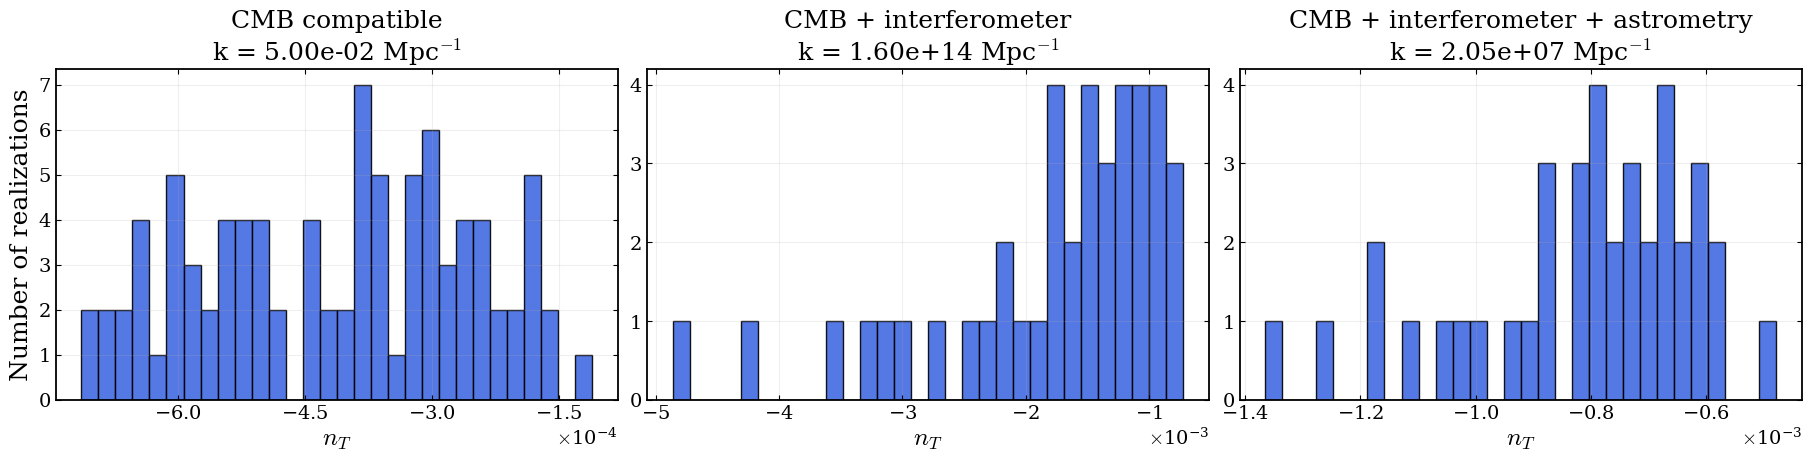

In [55]:
nT_cmb, nT_int, nT_joint_kast = plot_nT_survival_histograms_kast_joint(
    cmb_passing_models,
    fiducial_data,
    k_cmb=0.05,
    NEQS=6,
    h=0.675,
    bins=30,
)


So above I should be seeing every CMB compatible shifted realization. The second contains only those passing realizations whose Omega at kint falls inside 2sigma interval. This third is then only those interferometer survivors that fall insides astrometry 2sigma. This tells us what happens to the allowed tilt distribution  as additional scales constrain the inflationary history.


 **CMB tier**
 
nT_cmb:
    nT(k_cmb)

**CMB + interferometer tier**

nT_int:
    nT(k_int)

**CMB + interferometer + astrometry tier**

nT_joint:
    nT(k_ast)
    
    
We can do the same thing and look only at kint.

# Plot 14: nT ($k_{int}$)


In [56]:
def plot_nT_survival_histograms_kint_joint(
    cmb_passing_models,
    fiducial_data,
    k_cmb=0.05,
    NEQS=6,
    h=0.675,
    tf_file=None,
    bins=30,
):
    """
    Plot n_T distributions after successive constraints:

        1. CMB
        2. CMB + interferometer
        3. CMB + interferometer + astrometry

    n_T is evaluated at the scale associated with each
    observational tier.
    """

    # ========================================================
    # Transfer function
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )


    tf_data = np.loadtxt(tf_file)

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good]
    tf_T = tf_T[good]


    order = np.argsort(tf_k)

    tf_k = tf_k[order]
    tf_T = tf_T[order]


    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        bounds_error=False,
        fill_value=np.nan,
    )


    # ========================================================
    # Measurement information
    # ========================================================

    k_int = float(
        fiducial_data["k_int"]
    )

    k_ast = float(
        fiducial_data["k_ast"]
    )


    Omega_int = float(
        fiducial_data["Omega_meas_int"]
    )

    sigma_int = float(
        fiducial_data["sigma_Omega_int"]
    )


    Omega_ast = float(
        fiducial_data["Omega_meas_ast"]
    )

    sigma_ast = float(
        fiducial_data["sigma_Omega_ast"]
    )


    int_min = Omega_int - 2 * sigma_int
    int_max = Omega_int + 2 * sigma_int

    ast_min = Omega_ast - 2 * sigma_ast
    ast_max = Omega_ast + 2 * sigma_ast


    # ========================================================
    # nT samples
    # ========================================================

    nT_cmb = []
    nT_int = []
    nT_joint = []


    # ========================================================
    # Loop over CMB-compatible models
    # ========================================================

    for curves in cmb_passing_models:

        # ----------------------------------------------------
        # Tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )


        tensor_data = np.loadtxt(
            tensor_file
        )


        # h/Mpc -> Mpc^-1
        k_raw = (
            np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )
            * h
        )


        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[good]
        Pt_raw = Pt_raw[good]


        order = np.argsort(k_raw)

        k_raw = k_raw[order]
        Pt_raw = Pt_raw[order]


        # ----------------------------------------------------
        # CMB-compatible deltaN realizations
        # ----------------------------------------------------

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][pass_mask]


        # ====================================================
        # Loop over realizations
        # ====================================================

        for deltaN in allowed_deltaN:

            k_shifted = (
                k_raw
                * np.exp(-deltaN)
            )


            # =================================================
            # 1. CMB
            # =================================================

            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_cmb,
            )

            if np.isfinite(nT):

                nT_cmb.append(
                    nT
                )


            # =================================================
            # Need Omega_GW to determine later survival
            # =================================================

            overlap = (
                (k_shifted >= tf_k[0])
                & (k_shifted <= tf_k[-1])
            )

            k_use = k_shifted[overlap]
            Pt_use = Pt_raw[overlap]


            if len(k_use) < 3:
                continue


            T_use = np.exp(
                logT_interp(
                    np.log(k_use)
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]


            if len(k_use) < 3:
                continue


            OmegaGW = (
                T_use
                * Pt_use
            )


            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                bounds_error=False,
                fill_value=np.nan,
            )


            # =================================================
            # 2. Interferometer cut
            # =================================================

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_int = np.nan


            passes_int = (
                np.isfinite(Omega_at_int)
                and
                int_min
                <= Omega_at_int
                <= int_max
            )


            if not passes_int:
                continue


            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_int,
            )

            if np.isfinite(nT):

                nT_int.append(
                    nT
                )


            # =================================================
            # 3. Astrometry cut
            # =================================================

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_ast = np.nan


            passes_ast = (
                np.isfinite(Omega_at_ast)
                and
                ast_min
                <= Omega_at_ast
                <= ast_max
            )


            if not passes_ast:
                continue

#only changed below to be at k_int now
            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_int,
            )

            if np.isfinite(nT):

                nT_joint.append(
                    nT
                )


    # ========================================================
    # Arrays
    # ========================================================

    nT_cmb = np.asarray(nT_cmb)
    nT_int = np.asarray(nT_int)
    nT_joint = np.asarray(nT_joint)


    # ========================================================
    # Plot
    # ========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 4.5),
        constrained_layout=True,
    )


    values = [
        nT_cmb,
        nT_int,
        nT_joint,
    ]


    titles = [

        (
            "CMB compatible\n"
            f"k = {k_cmb:.2e} Mpc$^{{-1}}$"
        ),

        (
            "CMB + interferometer\n"
            f"k = {k_int:.2e} Mpc$^{{-1}}$"
        ),

        (
            "CMB + interferometer + astrometry\n"
            f"k = {k_ast:.2e} Mpc$^{{-1}}$"
        ),
    ]


    for ax, sample, title in zip(
        axes,
        values,
        titles,
    ):

        ax.hist(
            sample,
            bins=bins,
            color="royalblue",
            edgecolor="black",
            alpha=0.9,
        )


        ax.set_title(
            title
        )


        ax.set_xlabel(
            r"$n_T$"
        )


        ax.ticklabel_format(
            axis="x",
            style="sci",
            scilimits=(0, 0),
            useMathText=True,
        )


        ax.xaxis.set_major_locator(
            plt.MaxNLocator(5)
        )


        ax.grid(
            alpha=0.2
        )


    axes[0].set_ylabel(
        "Number of realizations"
    )


    plt.show()


    return (
        nT_cmb,
        nT_int,
        nT_joint,
    )

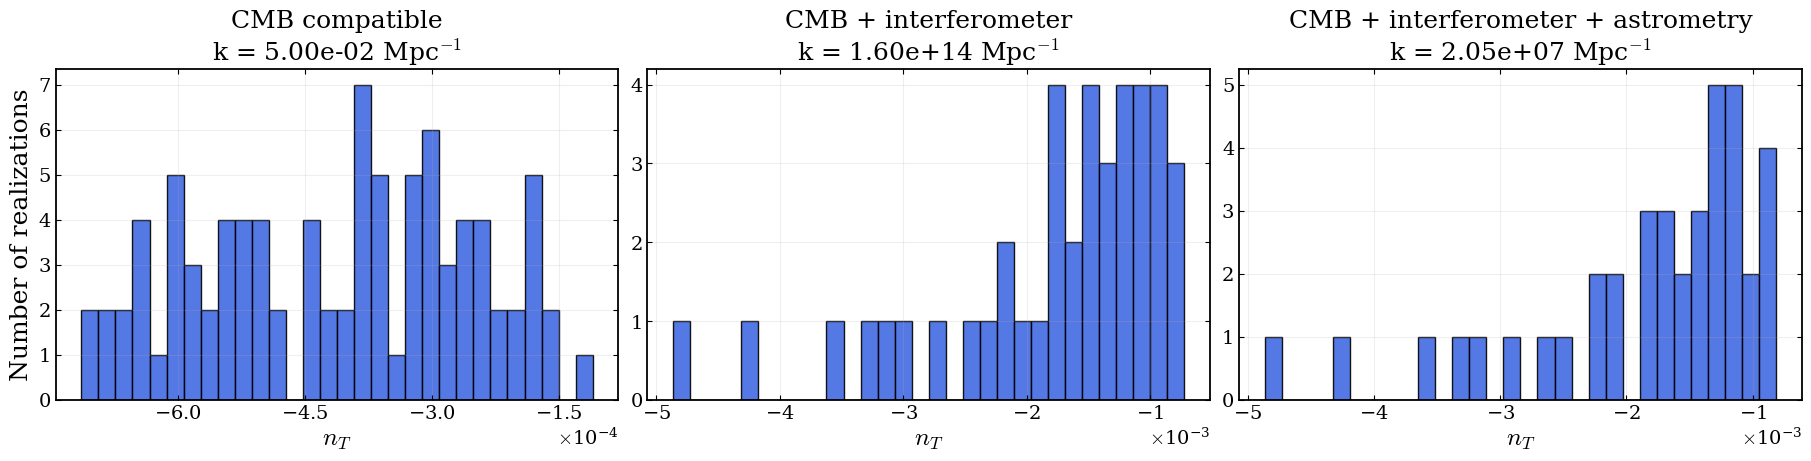

In [57]:
nT_cmb, nT_int, nT_joint_kint = plot_nT_survival_histograms_kint_joint(
    cmb_passing_models,
    fiducial_data,
    k_cmb=0.05,
    NEQS=6,
    h=0.675,
    bins=30,
)

From what we are seeing, for the same 39 realizations that survive at all three scales, when i evaluate the nT tilt at kast I got a median of -7.85e-4 and then if I evaluate at kint for the same models I get median of -1.54e-3. interesting. so it is more negative for kint. Typically scale wise it goes from cmb to ast to int. kint nT value is larger in mag than kast nT value, so nT gets more negative  as we extend to smaller scales. I guess makes sense, nT at CMB scale for what we have is like order 1e-4. Does that make sense though?

Does that change for differ models? by how much?

In general:
k_cmb < k_ast < k_int

We are seeing 
nT_cmb < nT_ast < nT_int.

Since nT = -r/8 and r = 16eps, nT is approx -2eps. So we are saying that at smaller scales, eps is increasing, sure. That corresponds to later in inflation/smaller scales. Yeah higher k modes can expect a larger spectral tilt. The ranges we are choosing come from sampled population, apply a CMB constraint, an interferometer constraint, then an astrometry constraint, and a hypothetical nT constraint. So the black lines to be marked shortly are realization that survive at all three amplitudes constraints and are consistent with some theoretical nT value.


We can see same surving inflationary histories given this set. It is also the case that we get noticeably different local tensor tilts depending on scales probing them.

For fiducial values at all three scales:


Fiducial tensor tilts
---------------------

nT(k_CMB) = -5.294981e-04

nT(k_ast) = -1.364811e-03

nT(k_int) = -4.863495e-03

For ast scale around median I would use maybe:

-1e-3 to -0.6e-3 since the median is around -0.8e-3. Tighter would be something like -0.9e-3 to -0.7e-3.

For int scale around median I would use:
-2e-3 to -1e-3 since median is in between there. But keep in mind thats outside of fiducial. 


# Plot 15: Plot $\Omega_{GW}$ with $n_T$ highlighted

In [58]:
def plot_omegaGW_with_nT_highlight(
    cmb_passing_models,
    fiducial_data,
    nT_min,
    nT_max,
    NEQS=6,
    h=0.675,
    plot_h2=False,
    tf_file=None,
    save_name=None,
):
    """
    Plot all CMB-compatible Omega_GW realizations.

    Colors:
        gray   : CMB compatible
        teal   : CMB + interferometer
        purple : CMB + interferometer + astrometry
        black  : joint survivors with nT in [nT_min, nT_max]

    nT for the black subset is evaluated at k_ast.
    """

    # ========================================================
    # Transfer function
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    tf_data = np.loadtxt(tf_file)

    tf_k = np.asarray(tf_data[:, 0], dtype=float)
    tf_T = np.asarray(tf_data[:, 2], dtype=float)

    good = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good]
    tf_T = tf_T[good]

#     order = np.argsort(tf_k)

#     tf_k = tf_k[order]
#     tf_T = tf_T[order]

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )


    # ========================================================
    # Measurement information
    # ========================================================

    k_int = float(
        fiducial_data["k_int"]
    )

    k_ast = float(
        fiducial_data["k_ast"]
    )
    
    
    fiducial_model_index = int(
    fiducial_data["model_index"]
    )

    Omega_int = float(
        fiducial_data["Omega_meas_int"]
    )

    sigma_int = float(
        fiducial_data["sigma_Omega_int"]
    )

    Omega_ast = float(
        fiducial_data["Omega_meas_ast"]
    )

    sigma_ast = float(
        fiducial_data["sigma_Omega_ast"]
    )


    int_min = Omega_int - 2.0 * sigma_int
    int_max = Omega_int + 2.0 * sigma_int

    ast_min = Omega_ast - 2.0 * sigma_ast
    ast_max = Omega_ast + 2.0 * sigma_ast


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 8),
        constrained_layout=True,
    )


    cmb_color = "#AAB4BE"
    interferometer_color = "#169C9C"
    joint_color = "#8A5FB5"


    highlighted = []


    # ========================================================
    # Loop over models
    # ========================================================

    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        # ----------------------------------------------------
        # Load tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )


        k_raw = (
            np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )
            * h
        )

        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[good]
        Pt_raw = Pt_raw[good]


        order = np.argsort(k_raw)

        k_raw = k_raw[order]
        Pt_raw = Pt_raw[order]


        # ----------------------------------------------------
        # CMB-compatible realizations
        # ----------------------------------------------------

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][pass_mask]


        # ====================================================
        # Loop over realizations
        # ====================================================

        for deltaN in allowed_deltaN:

            k_shifted = (
                k_raw
                * np.exp(-deltaN)
            )


            # ------------------------------------------------
            # Transfer-function overlap
            # ------------------------------------------------

            overlap = (
                (k_shifted >= tf_k[0])
                & (k_shifted <= tf_k[-1])
            )

            k_use = k_shifted[overlap]
            Pt_use = Pt_raw[overlap]


            if len(k_use) < 3:
                continue


            T_use = np.exp(
                logT_interp(
                    np.log(k_use)
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]


            if len(k_use) < 3:
                continue


            # =================================================
            # Omega_GW
            # =================================================

            OmegaGW = (
                T_use
                * Pt_use
            )


            if plot_h2:

                yplot = (
                    h**2
                    * OmegaGW
                )

            else:

                yplot = OmegaGW


            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                kind="linear",
                bounds_error=False,
                fill_value=np.nan,
            )


            # =================================================
            # Interferometer
            # =================================================

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_int = np.nan


            passes_int = (
                np.isfinite(Omega_at_int)
                and
                int_min <= Omega_at_int <= int_max
            )


            # =================================================
            # Astrometry
            # =================================================

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_ast = np.nan


            passes_ast = (
                np.isfinite(Omega_at_ast)
                and
                ast_min <= Omega_at_ast <= ast_max
            )


            passes_joint = (
                passes_int
                and
                passes_ast
            )


            # =================================================
            # nT at third-tier scale
            # =================================================

            nT_ast = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_ast,
            )


            passes_nT = (
                passes_joint
                and
                np.isfinite(nT_ast)
                and
                nT_min <= nT_ast <= nT_max
            )


            
            is_fiducial = (
                model_index == fiducial_model_index
                and np.isclose(
                    deltaN,
                    0.0,
                    atol=1e-8,
                )
            )
            
            
            # =================================================
            # Plot
            # =================================================

            
            if is_fiducial:

                ax.loglog(
                    k_use,
                    yplot,
                    color="black",
                    lw=3.0,
                    ls="--",
                    alpha=1.0,
                    zorder=20,
                )


            elif passes_nT:

                ax.loglog(
                    k_use,
                    yplot,
                    color="mediumvioletred",
                    lw=2.5,
                    alpha=0.95,
                    zorder=10,
                )
    
    

                highlighted.append(
                    {
                        "model_index": model_index,
                        "deltaN": deltaN,
                        "nT": nT_ast,
                    }
                )


            elif passes_joint:

                ax.loglog(
                    k_use,
                    yplot,
                    color=joint_color,
                    lw=2.0,
                    alpha=0.85,
                    zorder=4,
                )


            elif passes_int:

                ax.loglog(
                    k_use,
                    yplot,
                    color=interferometer_color,
                    lw=1.6,
                    alpha=0.75,
                    zorder=3,
                )


            else:

                ax.loglog(
                    k_use,
                    yplot,
                    color=cmb_color,
                    lw=1.0,
                    alpha=0.25,
                    zorder=1,
                )


    # ========================================================
    # Labels
    # ========================================================

    ax.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    if plot_h2:

        ax.set_ylabel(
            r"$\Omega_{\rm GW} h^2$"
        )

    else:

        ax.set_ylabel(
            r"$\Omega_{\rm GW}$"
        )


    ax.set_title(
        "Successive GW constraints with tensor-tilt selection\n"
        rf"${nT_min:.3g} \leq n_T(k_{{\rm ast}}) "
        rf"\leq {nT_max:.3g}$"
    )


    # ========================================================
    # Legend
    # ========================================================

    handles = [

        Line2D(
            [0],
            [0],
            color=cmb_color,
            lw=2,
            label="CMB compatible",
        ),

        Line2D(
            [0],
            [0],
            color=interferometer_color,
            lw=2,
            label="CMB + interferometer",
        ),

        Line2D(
            [0],
            [0],
            color=joint_color,
            lw=2,
            label="CMB + interferometer + astrometry",
        ),

        Line2D(
            [0],
            [0],
            color="mediumvioletred",
            lw=2.5,
            label=(
                rf"Joint + "
                rf"${nT_min:.3g} \leq n_T "
                rf"\leq {nT_max:.3g}$"
            ),
        ),
    ]


    ax.legend(
        handles=handles,
        frameon=False,
    )


    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )

    ax.grid(
        True,
        which="minor",
        alpha=0.10,
    )
    
    
    ax.set_yticks(
    np.geomspace(
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        10,
        )
    )

    ax.set_yticklabels(
        [
            f"{y:.1e}"
            for y in ax.get_yticks()
        ]
    )




    # ========================================================
    # Save
    # ========================================================

    if save_name is not None:

        fig.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )


    plt.show()


    return pd.DataFrame(
        highlighted
    )

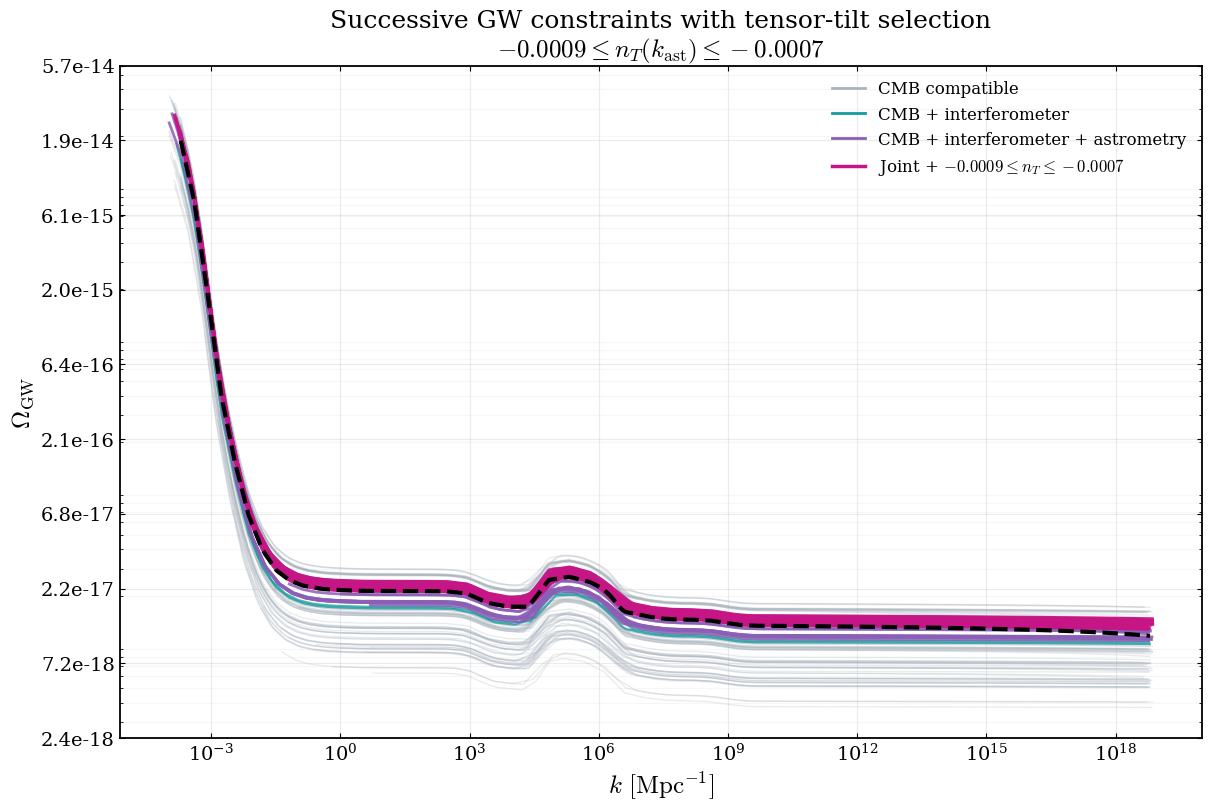

In [59]:
highlighted = plot_omegaGW_with_nT_highlight(
    cmb_passing_models,
    fiducial_data,

    nT_min=-0.9e-3,
    nT_max=-0.7e-3,

    NEQS=6,
    h=0.675,
)



# Plot 16: Background Variables for Surviving Models


**What are the backgrounds of surviving models across scales?**

This will tie us back to the actual physical trajectories. Now, we can examine the background variables normnalized by the model's $N_{ref}$ according to which of these trajectories are consistent with the fiducial model at various scales.

In [60]:
def plot_background_by_survival_stage(
    cmb_passing_models,
    joint_result,
    fiducial_measurements,
    NEQS=6,
    N_ref=60.0,
    N_window=(20.0, 70.0),
    save_name=None,
):
    """
    Plot normalized background histories H(N)/H(N_ref) and V(N)/V(N_ref)
    for models surviving successive observational cuts.

    Colors:
        gray   = CMB compatible
        teal   = CMB + interferometer compatible
        purple = CMB + interferometer + astrometry compatible
        black dashed = fiducial model

    Classification is at the MODEL level:
        a model enters the interferometer set if at least one of its
        CMB-allowed deltaN_piv realizations passes the interferometer cut.

        a model enters the joint set if at least one of its
        CMB-allowed deltaN_piv realizations passes both interferometer
        and astrometry cuts.
    """

    # ========================================================
    # Model sets from previous survival analysis
    # ========================================================

    int_models = set(
        joint_result[
            "interferometer_model_indices"
        ]
    )

    joint_models = set(
        joint_result[
            "joint_model_indices"
        ]
    )

    fiducial_model_index = int(
        fiducial_measurements[
            "model_index"
        ]
    )


    # ========================================================
    # Colors
    # ========================================================

    cmb_color = "#AAB4BE"
    int_color = "#169C9C"
    joint_color = "#8A5FB5"
    fid_color = "black"


    # ========================================================
    # Load and normalize all background trajectories
    # ========================================================

    background_models = []
    #this is defined as all cmb passing models

    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )

        # Same saved path used for this model
        if "path_file" in curves:

            path_file = curves[
                "path_file"
            ]

            data = np.loadtxt(
                path_file
            )

        elif curves.get("outdir") is not None:

            data, path_file = load_path_from_outdir(
                curves["outdir"],
                NEQS=NEQS,
            )

        else:

            raise KeyError(
                f"Model {model_index} has neither "
                "'path_file' nor 'outdir'."
            )


        # This is  existing helper:
        #
        # H -> H/H(N_ref)
        # V -> V/V(N_ref)
        #
        # --------------------------------------------------------
        # Pull H, N, and V from saved path
        # --------------------------------------------------------

        H = np.asarray(
            data[:, 1],
            dtype=float,
        )

        N = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )


        # --------------------------------------------------------
        # Restrict to requested N interval: finite and within window
        # --------------------------------------------------------

        N_min, N_max = N_window

        keep = (
            np.isfinite(N)
            & np.isfinite(H)
            & np.isfinite(V)
            & (N >= N_min)
            & (N <= N_max)
        )

        N_use = N[keep]
        H_use = H[keep]
        V_use = V[keep]


        # --------------------------------------------------------
        # Normalize H and V at N_ref
        # --------------------------------------------------------

        N_H, H_norm, H_ref = normalize_curve_at_Nref(
            N_use,
            H_use,
            N_ref=N_ref,
        )

        N_V, V_norm, V_ref = normalize_curve_at_Nref(
            N_use,
            V_use,
            N_ref=N_ref,
        )


        background_models.append({
            "model_index": model_index,

            "N_H": N_H,
            "H": H_norm,

            "N_V": N_V,
            "V": V_norm,

            "H_ref": H_ref,
            "V_ref": V_ref,
        })




    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        constrained_layout=True,
    )

    ax_H, ax_V = axes


    # ========================================================
    # 1. Plot ALL CMB models first
    # ========================================================

    for model in background_models: #all cmb passing models

        model_index = model[
            "model_index"
        ]

        # Skip fiducial here;
        # draw it separately on top later
        if model_index == fiducial_model_index:
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=cmb_color,
            lw=1.2,
            alpha=0.40,
            zorder=1,
        )


        ax_V.plot(
            model["N_V"],
            model["V"],
            color=cmb_color,
            lw=1.2,
            alpha=0.40,
            zorder=1,
        )


    # ========================================================
    # 2. Overlay interferometer-compatible models
    # ========================================================

    for model in background_models:

        model_index = model[
            "model_index"
        ]

        if (
            model_index not in int_models
            or
            model_index == fiducial_model_index
        ):
            continue #skip if fiducial or not in int


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=int_color,
            lw=2.0,
            alpha=0.80,
            zorder=2,
        )


        ax_V.plot(
            model["N_V"],
            model["V"],
            color=int_color,
            lw=2.0,
            alpha=0.80,
            zorder=2,
        )


    # ========================================================
    # 3. Overlay joint interferometer + astrometry models
    # ========================================================

    for model in background_models:

        model_index = model[
            "model_index"
        ]

        if (
            model_index not in joint_models
            or
            model_index == fiducial_model_index
        ):
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=joint_color,
            lw=2.5,
            alpha=0.95,
            zorder=3,
        )


        ax_V.plot(
            model["N_V"],
            model["V"],
            color=joint_color,
            lw=2.5,
            alpha=0.95,
            zorder=3,
        )


    # ========================================================
    # 4. Fiducial model
    # ========================================================

    fiducial_background = None


    for model in background_models:

        if (
            model["model_index"]
            == fiducial_model_index
        ):

            fiducial_background = model
            break


    if fiducial_background is None:

        raise ValueError(
            f"Fiducial model "
            f"{fiducial_model_index} "
            "was not found in cmb_passing_models."
        ) #this would be a big problem is we get that


    ax_H.plot(
        fiducial_background["N_H"],
        fiducial_background["H"],
        color=fid_color,
        lw=3.0,
        ls="--",
        alpha=1.0,
        zorder=5,
    )


    ax_V.plot(
        fiducial_background["N_V"],
        fiducial_background["V"],
        color=fid_color,
        lw=3.0,
        ls="--",
        alpha=1.0,
        zorder=5,
    )

#worth noting a line could be called three times hehe

    # ========================================================
    # Reference N
    # ========================================================

    for ax in axes:

        ax.axvline(
            N_ref,
            color="black",
            ls=":",
            lw=1.2,
            alpha=0.6,
            zorder=0,
        )


    # ========================================================
    # Legend
    # ========================================================

    cmb_handle = Line2D(
        [0],
        [0],
        color=cmb_color,
        lw=2.0,
        label=(
            rf"CMB compatible "
            rf"({len(cmb_passing_models)})"
        ),
    )


    int_handle = Line2D(
        [0],
        [0],
        color=int_color,
        lw=2.5,
        label=(
            rf"CMB + interferometer "
            rf"({len(int_models)})"
        ),
    )


    joint_handle = Line2D(
        [0],
        [0],
        color=joint_color,
        lw=2.5,
        label=(
            rf"CMB + interferometer + astrometry "
            rf"({len(joint_models)})"
        ),
    )


    fid_handle = Line2D(
        [0],
        [0],
        color=fid_color,
        lw=3.0,
        ls="--",
        label="Fiducial",
    )


    # ========================================================
    # Labels
    # ========================================================

    ax_H.set_title(
        rf"$H(N)/H({N_ref:g})$"
    )

    ax_V.set_title(
        rf"$V(N)/V({N_ref:g})$"
    )


    ax_H.set_ylabel(
        rf"$H/H({N_ref:g})$"
    )

    ax_V.set_ylabel(
        rf"$V/V({N_ref:g})$"
    )


    for ax in axes:

        ax.set_xlabel(
            r"$N$"
        )

        # Larger N = earlier inflation
        ax.invert_xaxis()

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend(
            handles=[
                cmb_handle,
                int_handle,
                joint_handle,
                fid_handle,
            ],
            frameon=False,
            loc="best",
        )


    # ========================================================
    # Overall title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: background evolution after successive constraints"
        "\n"
        rf"{len(cmb_passing_models)} CMB"
        rf" $\rightarrow$ "
        rf"{len(int_models)} CMB + interferometer"
        rf" $\rightarrow$ "
        rf"{len(joint_models)} CMB + interferometer + astrometry"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        save_name = (
            f"background_survival_"
            f"H_V_"
            f"neqs{NEQS}.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


    print("\n" + "=" * 70)
    print("MODEL BACKGROUND SURVIVAL PLOT")
    print("=" * 70)

    print(
        f"CMB models                   : "
        f"{len(cmb_passing_models)}"
    )

    print(
        f"CMB + interferometer models  : "
        f"{len(int_models)}"
    )

    print(
        f"CMB + int + ast models       : "
        f"{len(joint_models)}"
    )

    print(
        f"Fiducial model Index               : "
        f"{fiducial_model_index}"
    )

    print("=" * 70)

    return background_models

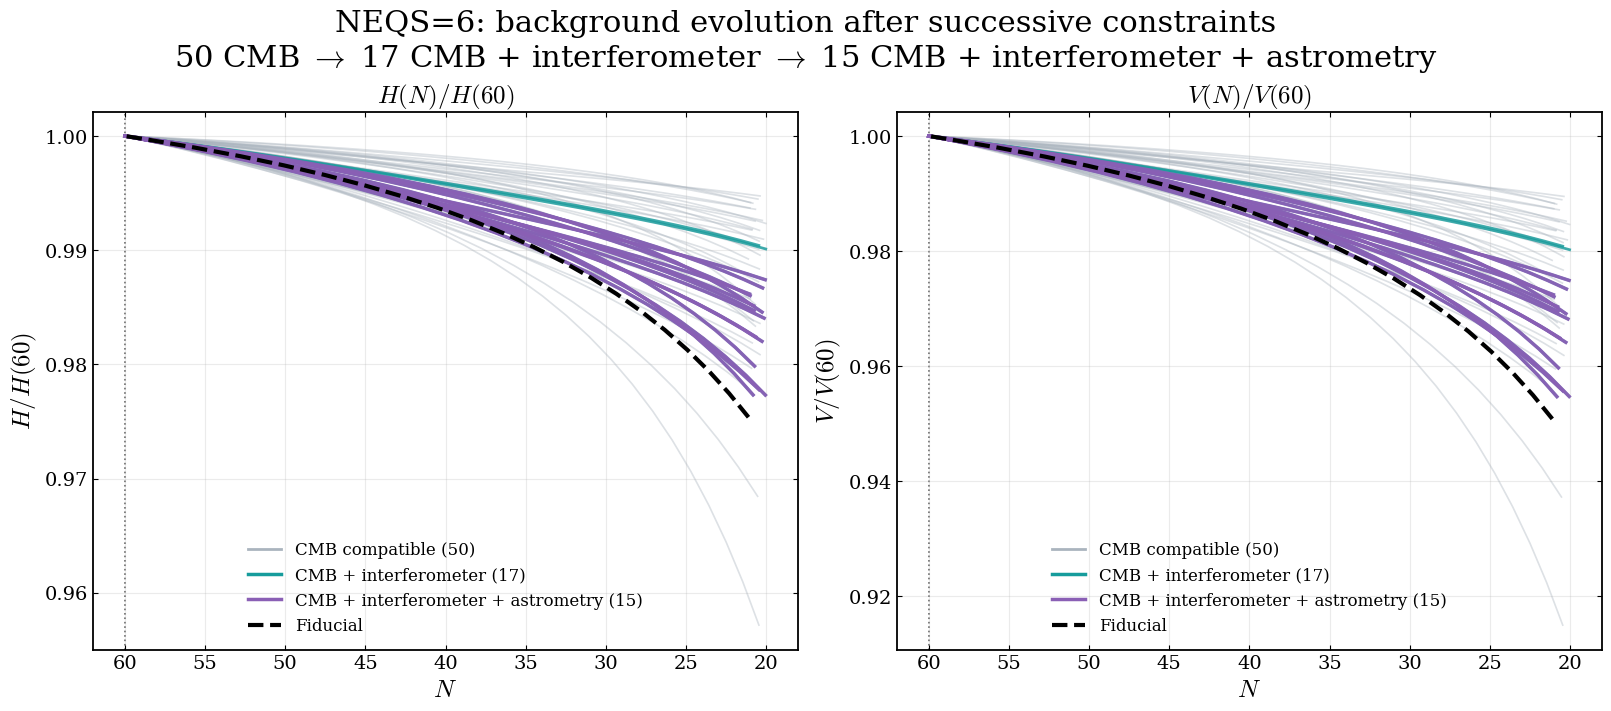


MODEL BACKGROUND SURVIVAL PLOT
CMB models                   : 50
CMB + interferometer models  : 17
CMB + int + ast models       : 15
Fiducial model Index               : 0


In [61]:
background_survival = plot_background_by_survival_stage(
    cmb_passing_models=cmb_passing_models,
    joint_result=joint_result,
    fiducial_measurements=fiducial_data,
    NEQS=6,
    N_ref=60.0,
    N_window=(20.0, 60.0),
)

# Plot 17: Background Variables for Surviving Models with $n_T$


In [63]:
def plot_background_by_survival_stage_with_nT_highlight(
    cmb_passing_models,
    joint_result,
    fiducial_measurements,
    NEQS=6,
    N_ref=60.0,
    N_window=(20.0, 60.0),
    nT_min=-0.9e-3,
    nT_max=-0.7e-3,
    h=0.675,
    tf_file=None,
    save_name=None,
):
    """
    Same background plot as plot_background_by_survival_stage(),
    but highlights in SOLID BLACK any tri-joint model that has
    at least one surviving realization with

        nT_min <= n_T(k_ast) <= nT_max

    n_T is computed directly from P_t(k).
    """

    # ========================================================
    # Model sets from previous survival analysis
    # ========================================================

    int_models = set(
        joint_result["interferometer_model_indices"]
    )

    joint_models = set(
        joint_result["joint_model_indices"]
    )

    fiducial_model_index = int(
        fiducial_measurements["model_index"]
    )


    # ========================================================
    # Measurement information
    # ========================================================

    k_int = float(
        fiducial_measurements["k_int"]
    )

    k_ast = float(
        fiducial_measurements["k_ast"]
    )

    Omega_int = float(
        fiducial_measurements["Omega_meas_int"]
    )

    sigma_int = float(
        fiducial_measurements["sigma_Omega_int"]
    )

    Omega_ast = float(
        fiducial_measurements["Omega_meas_ast"]
    )

    sigma_ast = float(
        fiducial_measurements["sigma_Omega_ast"]
    )


    int_min = Omega_int - 2.0 * sigma_int
    int_max = Omega_int + 2.0 * sigma_int

    ast_min = Omega_ast - 2.0 * sigma_ast
    ast_max = Omega_ast + 2.0 * sigma_ast


    # ========================================================
    # Transfer function
    # ========================================================

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )


    tf_data = np.loadtxt(tf_file)

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )


    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]


    order = np.argsort(tf_k)

    tf_k = tf_k[order]
    tf_T = tf_T[order]


    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )


    # ========================================================
    # Find models with TRI-JOINT realization in desired nT range
    # ========================================================

    nT_models = set()


    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        # Don't bother checking models that did not reach
        # the tri-joint stage
        if model_index not in joint_models:
            continue


        # ----------------------------------------------------
        # Load tensor spectrum
        # ----------------------------------------------------

        tensor_file = os.path.join(
            curves["outdir"],
            f"spec_t_neqs{NEQS}.dat",
        )

        tensor_data = np.loadtxt(
            tensor_file
        )


        k_raw = (
            np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )
            * h
        )

        Pt_raw = np.abs(
            np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )
        )


        good = (
            np.isfinite(k_raw)
            & np.isfinite(Pt_raw)
            & (k_raw > 0)
            & (Pt_raw > 0)
        )

        k_raw = k_raw[good]
        Pt_raw = Pt_raw[good]


        order = np.argsort(k_raw)

        k_raw = k_raw[order]
        Pt_raw = Pt_raw[order]


        # ----------------------------------------------------
        # CMB-compatible realizations
        # ----------------------------------------------------

        pass_mask = curves[
            "cmb_pass_mask"
        ]

        allowed_deltaN = curves[
            "deltaN_piv"
        ][pass_mask]


        # ----------------------------------------------------
        # Check each realization
        # ----------------------------------------------------

        for deltaN in allowed_deltaN:

            k_shifted = (
                k_raw
                * np.exp(-deltaN)
            )


            # ------------------------------------------------
            # Transfer-function overlap
            # ------------------------------------------------

            overlap = (
                (k_shifted >= tf_k[0])
                & (k_shifted <= tf_k[-1])
            )

            k_use = k_shifted[overlap]
            Pt_use = Pt_raw[overlap]


            if len(k_use) < 3:
                continue


            T_use = np.exp(
                logT_interp(
                    np.log(k_use)
                )
            )


            valid = (
                np.isfinite(T_use)
                & (T_use > 0)
            )

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]


            if len(k_use) < 3:
                continue


            # ------------------------------------------------
            # Omega_GW
            # ------------------------------------------------

            OmegaGW = (
                T_use
                * Pt_use
            )


            logOmega_interp = interp1d(
                np.log(k_use),
                np.log(OmegaGW),
                kind="linear",
                bounds_error=False,
                fill_value=np.nan,
            )


            # ------------------------------------------------
            # Interferometer cut
            # ------------------------------------------------

            if (
                k_use[0]
                <= k_int
                <= k_use[-1]
            ):

                Omega_at_int = np.exp(
                    logOmega_interp(
                        np.log(k_int)
                    )
                )

            else:

                Omega_at_int = np.nan


            passes_int = (
                np.isfinite(Omega_at_int)
                and
                int_min <= Omega_at_int <= int_max
            )


            if not passes_int:
                continue


            # ------------------------------------------------
            # Astrometry cut
            # ------------------------------------------------

            if (
                k_use[0]
                <= k_ast
                <= k_use[-1]
            ):

                Omega_at_ast = np.exp(
                    logOmega_interp(
                        np.log(k_ast)
                    )
                )

            else:

                Omega_at_ast = np.nan


            passes_ast = (
                np.isfinite(Omega_at_ast)
                and
                ast_min <= Omega_at_ast <= ast_max
            )


            if not passes_ast:
                continue


            # ------------------------------------------------
            # This realization survived ALL THREE.
            # Now calculate nT at k_ast.
            # ------------------------------------------------

            nT = nT_from_Pt(
                k_shifted,
                Pt_raw,
                k_ast,
            )


            if (
                np.isfinite(nT)
                and
                nT_min <= nT <= nT_max
            ):

                nT_models.add(
                    model_index
                )

                # One passing realization is enough to
                # highlight this model's background
                break


    # ========================================================
    # Colors
    # ========================================================

    cmb_color = "#AAB4BE"
    int_color = "#169C9C"
    joint_color = "#8A5FB5"
    fid_color = "black"


    # ========================================================
    # Load and normalize background trajectories
    # ========================================================

    background_models = []


    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        if "path_file" in curves:

            data = np.loadtxt(
                curves["path_file"]
            )

        elif curves.get("outdir") is not None:

            data, path_file = load_path_from_outdir(
                curves["outdir"],
                NEQS=NEQS,
            )

        else:

            raise KeyError(
                f"Model {model_index} has neither "
                "'path_file' nor 'outdir'."
            )


        H = np.asarray(
            data[:, 1],
            dtype=float,
        )

        N = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )


        N_min, N_max = N_window


        keep = (
            np.isfinite(N)
            & np.isfinite(H)
            & np.isfinite(V)
            & (N >= N_min)
            & (N <= N_max)
        )


        N_use = N[keep]
        H_use = H[keep]
        V_use = V[keep]


        N_H, H_norm, H_ref = normalize_curve_at_Nref(
            N_use,
            H_use,
            N_ref=N_ref,
        )

        N_V, V_norm, V_ref = normalize_curve_at_Nref(
            N_use,
            V_use,
            N_ref=N_ref,
        )


        background_models.append({

            "model_index": model_index,

            "N_H": N_H,
            "H": H_norm,

            "N_V": N_V,
            "V": V_norm,

            "H_ref": H_ref,
            "V_ref": V_ref,
        })


    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        constrained_layout=True,
    )

    ax_H, ax_V = axes


    # ========================================================
    # 1. CMB -- gray
    # ========================================================

    for model in background_models:

        model_index = model["model_index"]

        if model_index == fiducial_model_index:
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=cmb_color,
            lw=1.2,
            alpha=0.40,
            zorder=1,
        )

        ax_V.plot(
            model["N_V"],
            model["V"],
            color=cmb_color,
            lw=1.2,
            alpha=0.40,
            zorder=1,
        )


    # ========================================================
    # 2. CMB + interferometer -- teal
    # ========================================================

    for model in background_models:

        model_index = model["model_index"]

        if (
            model_index not in int_models
            or
            model_index == fiducial_model_index
        ):
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=int_color,
            lw=2.0,
            alpha=0.80,
            zorder=2,
        )

        ax_V.plot(
            model["N_V"],
            model["V"],
            color=int_color,
            lw=2.0,
            alpha=0.80,
            zorder=2,
        )


    # ========================================================
    # 3. TRI-JOINT -- purple
    # ========================================================

    for model in background_models:

        model_index = model["model_index"]

        if (
            model_index not in joint_models
            or
            model_index == fiducial_model_index
        ):
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color=joint_color,
            lw=2.5,
            alpha=0.95,
            zorder=3,
        )

        ax_V.plot(
            model["N_V"],
            model["V"],
            color=joint_color,
            lw=2.5,
            alpha=0.95,
            zorder=3,
        )


    # ========================================================
    # 4. TRI-JOINT + nT RANGE -- BLACK
    # ========================================================

    for model in background_models:

        model_index = model["model_index"]

        if (
            model_index not in nT_models
            or
            model_index == fiducial_model_index
        ):
            continue


        ax_H.plot(
            model["N_H"],
            model["H"],
            color="mediumvioletred",
            lw=3.0,
            alpha=1.0,
            zorder=4,
        )

        ax_V.plot(
            model["N_V"],
            model["V"],
            color="mediumvioletred",
            lw=3.0,
            alpha=1.0,
            zorder=4,
        )


    # ========================================================
    # Fiducial -- dashed black
    # ========================================================

    fiducial_background = None


    for model in background_models:

        if (
            model["model_index"]
            == fiducial_model_index
        ):

            fiducial_background = model
            break


    if fiducial_background is None:

        raise ValueError(
            f"Fiducial model {fiducial_model_index} "
            "was not found."
        )


    ax_H.plot(
        fiducial_background["N_H"],
        fiducial_background["H"],
        color=fid_color,
        lw=3.0,
        ls="--",
        zorder=5,
    )

    ax_V.plot(
        fiducial_background["N_V"],
        fiducial_background["V"],
        color=fid_color,
        lw=3.0,
        ls="--",
        zorder=5,
    )


    # ========================================================
    # Reference N
    # ========================================================

    for ax in axes:

        ax.axvline(
            N_ref,
            color="black",
            ls=":",
            lw=1.2,
            alpha=0.6,
            zorder=0,
        )


    # ========================================================
    # Legend
    # ========================================================

    handles = [

        Line2D(
            [0], [0],
            color=cmb_color,
            lw=2.0,
            label=f"CMB compatible ({len(cmb_passing_models)})",
        ),

        Line2D(
            [0], [0],
            color=int_color,
            lw=2.5,
            label=f"CMB + interferometer ({len(int_models)})",
        ),

        Line2D(
            [0], [0],
            color=joint_color,
            lw=2.5,
            label=(
                "CMB + interferometer + astrometry "
                f"({len(joint_models)})"
            ),
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=3.0,
            label=(
                rf"$8\times10^{{-5}}\leq n_T"
                rf"\leq1.4\times10^{{-4}}$ "
                rf"({len(nT_models)})"
            ),
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=3.0,
            ls="--",
            label="Fiducial",
        ),
    ]


    # ========================================================
    # Labels
    # ========================================================

    ax_H.set_title(
        rf"$H(N)/H({N_ref:g})$"
    )

    ax_V.set_title(
        rf"$V(N)/V({N_ref:g})$"
    )

    ax_H.set_ylabel(
        rf"$H/H({N_ref:g})$"
    )

    ax_V.set_ylabel(
        rf"$V/V({N_ref:g})$"
    )


    for ax in axes:

        ax.set_xlabel(
            r"$N$"
        )

        ax.invert_xaxis()

        ax.grid(
            True,
            alpha=0.25,
        )

        ax.legend(
            handles=handles,
            frameon=False,
            loc="best",
        )


    # ========================================================
    # Overall title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: background evolution after successive constraints"
        "\n"
        rf"{len(cmb_passing_models)} CMB"
        rf" $\rightarrow$ "
        rf"{len(int_models)} CMB + interferometer"
        rf" $\rightarrow$ "
        rf"{len(joint_models)} tri-joint"
        rf" $\rightarrow$ "
        rf"{len(nT_models)} in selected $n_T$ range"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        save_name = (
            f"background_survival_"
            f"H_V_nT_highlight_"
            f"neqs{NEQS}.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    print("\nSelected nT models:")
    print(sorted(nT_models))


    return background_models, sorted(nT_models)

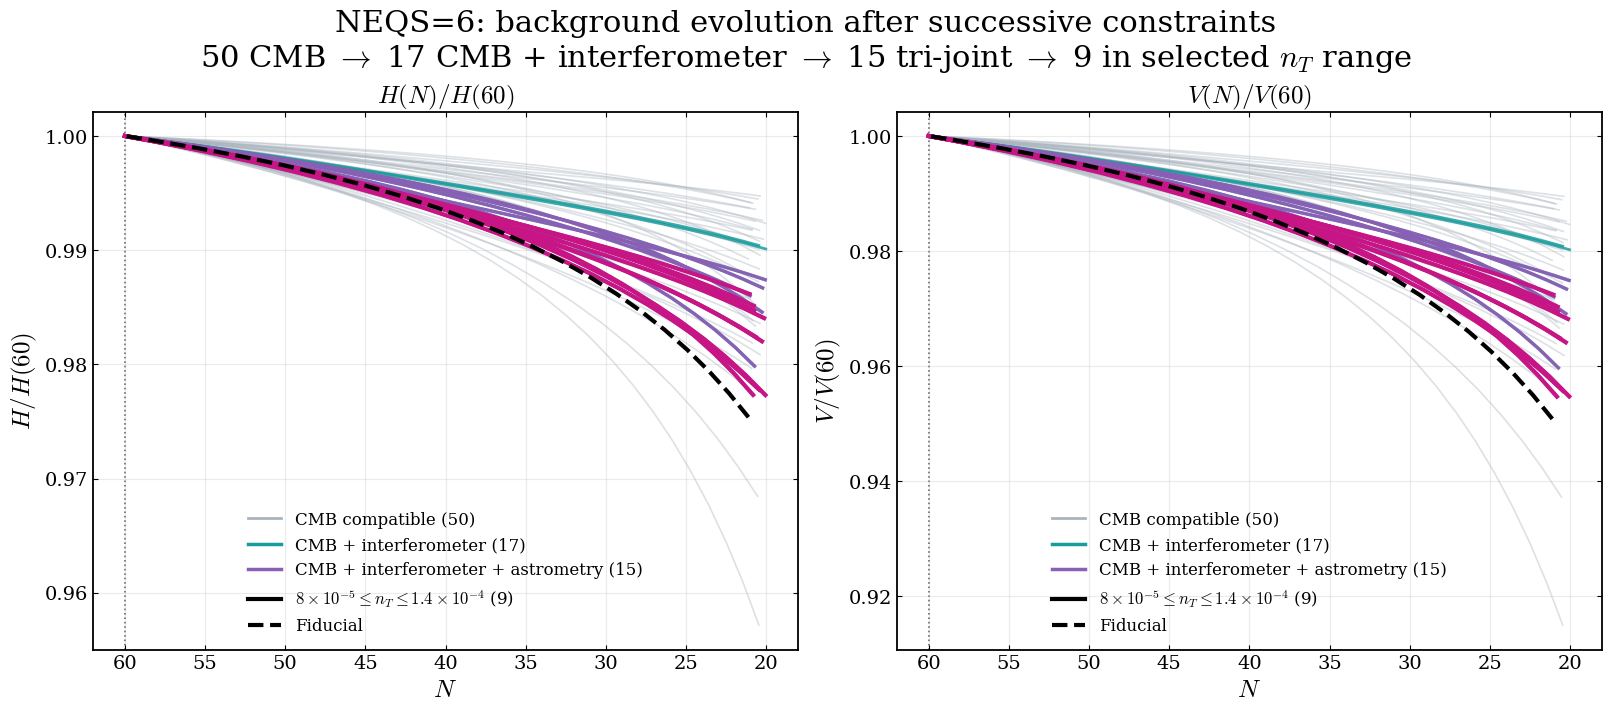


Selected nT models:
[1, 53, 77, 88, 121, 161, 172, 187, 197]


In [64]:
background_survival_nT, nT_models = (
    plot_background_by_survival_stage_with_nT_highlight(
        cmb_passing_models=cmb_passing_models,
        joint_result=joint_result,
        fiducial_measurements=fiducial_data,
        NEQS=6,
        N_ref=60.0,
        N_window=(20.0, 60.0),
        nT_min=-0.9e-3,
        nT_max=-0.7e-3,
    )
)

# Plot 18: Background Variable Envelopes with $n_T$ 

If you dont wanna include $n_T$ literally make the values sooooo fucking small.

In [67]:
def plot_background_envelopes_by_survival_with_nT(
    cmb_passing_models,
    joint_result,
    fiducial_measurements,
    nT_selected,
    NEQS=6,
    N_ref=60.0,
    N_window=(20.0, 60.0),
    N_points=500,
    save_name=None,
):
    """
    Plot min/max envelopes of

        H(N) / H(N_ref)
        V(N) / V(N_ref)

    for nested model sets:

        gray   = CMB compatible
        teal   = CMB + interferometer compatible
        purple = CMB + interferometer + astrometry compatible
        mediumvioletred = joint models selected by n_T(k_ast)

    Fiducial/base model is black dashed.

    Parameters
    ----------
    nT_selected :
        DataFrame returned by plot_omegaGW_with_nT_highlight().
        Must contain a "model_index" column.
    """

    # ========================================================
    # Model classifications
    # ========================================================

    int_model_indices = set(
        joint_result[
            "interferometer_model_indices"
        ]
    )

    joint_model_indices = set(
        joint_result[
            "joint_model_indices"
        ]
    )

    fiducial_model_index = int(
        fiducial_measurements[
            "model_index"
        ]
    )


    # ========================================================
    # nT-selected model indices
    # ========================================================

    nT_model_indices = set(
        nT_selected["model_index"]
    )


    # ========================================================
    # Colors
    # ========================================================

    cmb_color = "#AAB4BE"
    int_color = "#169C9C"
    joint_color = "#8A5FB5"
    nT_color = "mediumvioletred"
    fid_color = "black"


    # ========================================================
    # Common N grid
    # ========================================================

    N_min, N_max = N_window

    N_grid = np.linspace(
        N_min,
        N_max,
        N_points,
    )


    # ========================================================
    # Load and normalize every CMB-compatible trajectory
    # ========================================================

    background_models = []


    for curves in cmb_passing_models:

        model_index = int(
            curves["model_index"]
        )


        # ----------------------------------------------------
        # Load saved path
        # ----------------------------------------------------

        if (
            "path_file" in curves
            and curves["path_file"] is not None
        ):

            data = np.loadtxt(
                curves["path_file"]
            )

        elif (
            "outdir" in curves
            and curves["outdir"] is not None
        ):

            data, path_file = load_path_from_outdir(
                curves["outdir"],
                NEQS=NEQS,
            )

        else:

            raise KeyError(
                f"Model {model_index} has neither "
                "'path_file' nor 'outdir'."
            )


        data = np.asarray(
            data,
            dtype=float,
        )


        # ----------------------------------------------------
        # Saved path convention
        # ----------------------------------------------------

        H = np.asarray(
            data[:, 1],
            dtype=float,
        )

        N = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )


        # ----------------------------------------------------
        # Keep finite values
        # ----------------------------------------------------

        good = (
            np.isfinite(N)
            & np.isfinite(H)
            & np.isfinite(V)
        )

        N = N[good]
        H = H[good]
        V = V[good]


        # ----------------------------------------------------
        # Normalize at N_ref
        # ----------------------------------------------------

        N_H, H_norm, H_ref = (
            normalize_curve_at_Nref(
                N,
                H,
                N_ref=N_ref,
            )
        )

        N_V, V_norm, V_ref = (
            normalize_curve_at_Nref(
                N,
                V,
                N_ref=N_ref,
            )
        )


        # ----------------------------------------------------
        # Check requested plotting window
        # ----------------------------------------------------

        if not (
            N_H.min() <= N_min
            and
            N_H.max() >= N_max
        ):

            raise ValueError(
                f"Model {model_index}: H trajectory only covers "
                f"[{N_H.min():.4f}, {N_H.max():.4f}], "
                f"but requested N_window is "
                f"[{N_min:.4f}, {N_max:.4f}]."
            )


        if not (
            N_V.min() <= N_min
            and
            N_V.max() >= N_max
        ):

            raise ValueError(
                f"Model {model_index}: V trajectory only covers "
                f"[{N_V.min():.4f}, {N_V.max():.4f}], "
                f"but requested N_window is "
                f"[{N_min:.4f}, {N_max:.4f}]."
            )


        # ----------------------------------------------------
        # Interpolate onto common N grid
        # ----------------------------------------------------

        H_grid = np.interp(
            N_grid,
            N_H,
            H_norm,
        )

        V_grid = np.interp(
            N_grid,
            N_V,
            V_norm,
        )


        background_models.append({

            "model_index":
                model_index,

            "N_H":
                N_H,

            "H":
                H_norm,

            "N_V":
                N_V,

            "V":
                V_norm,

            "H_grid":
                H_grid,

            "V_grid":
                V_grid,

            "H_ref":
                H_ref,

            "V_ref":
                V_ref,
        })


    # ========================================================
    # Separate nested model sets
    # ========================================================

    cmb_models = background_models


    int_models = [
        model
        for model in background_models
        if model["model_index"]
        in int_model_indices
    ]


    joint_models = [
        model
        for model in background_models
        if model["model_index"]
        in joint_model_indices
    ]


    nT_models = [
        model
        for model in background_models
        if model["model_index"]
        in nT_model_indices
    ]


    # ========================================================
    # Envelope helper
    # ========================================================

    def get_envelope(
        models,
        key,
    ):

        if len(models) == 0:

            raise ValueError(
                f"No models available for envelope '{key}'."
            )


        stack = np.asarray(
            [
                model[key]
                for model in models
            ],
            dtype=float,
        )


        lower = np.min(
            stack,
            axis=0,
        )

        upper = np.max(
            stack,
            axis=0,
        )


        return lower, upper


    # ========================================================
    # H envelopes
    # ========================================================

    H_cmb_min, H_cmb_max = get_envelope(
        cmb_models,
        "H_grid",
    )

    H_int_min, H_int_max = get_envelope(
        int_models,
        "H_grid",
    )

    H_joint_min, H_joint_max = get_envelope(
        joint_models,
        "H_grid",
    )

    H_nT_min, H_nT_max = get_envelope(
        nT_models,
        "H_grid",
    )


    # ========================================================
    # V envelopes
    # ========================================================

    V_cmb_min, V_cmb_max = get_envelope(
        cmb_models,
        "V_grid",
    )

    V_int_min, V_int_max = get_envelope(
        int_models,
        "V_grid",
    )

    V_joint_min, V_joint_max = get_envelope(
        joint_models,
        "V_grid",
    )

    V_nT_min, V_nT_max = get_envelope(
        nT_models,
        "V_grid",
    )


    # ========================================================
    # Find fiducial model
    # ========================================================

    fiducial_background = None


    for model in background_models:

        if (
            model["model_index"]
            == fiducial_model_index
        ):

            fiducial_background = model

            break


    if fiducial_background is None:

        raise ValueError(
            f"Fiducial model "
            f"{fiducial_model_index} "
            "was not found."
        )


    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        constrained_layout=True,
    )

    ax_H, ax_V = axes


    # ========================================================
    # H(N)/H(N_ref)
    # ========================================================

    ax_H.fill_between(
        N_grid,
        H_cmb_min,
        H_cmb_max,
        color=cmb_color,
        alpha=0.30,
        zorder=1,
    )


    ax_H.fill_between(
        N_grid,
        H_int_min,
        H_int_max,
        color=int_color,
        alpha=0.35,
        zorder=2,
    )


    ax_H.fill_between(
        N_grid,
        H_joint_min,
        H_joint_max,
        color=joint_color,
        alpha=0.40,
        zorder=3,
    )


    # nT-selected joint envelope
    ax_H.fill_between(
        N_grid,
        H_nT_min,
        H_nT_max,
        color=nT_color,
        alpha=0.50,
        zorder=4,
    )


    # Fiducial H
    fid_H_grid = np.interp(
        N_grid,
        fiducial_background["N_H"],
        fiducial_background["H"],
    )


    ax_H.plot(
        N_grid,
        fid_H_grid,
        color=fid_color,
        lw=3.0,
        ls="--",
        zorder=10,
    )


    # ========================================================
    # V(N)/V(N_ref)
    # ========================================================

    ax_V.fill_between(
        N_grid,
        V_cmb_min,
        V_cmb_max,
        color=cmb_color,
        alpha=0.30,
        zorder=1,
    )


    ax_V.fill_between(
        N_grid,
        V_int_min,
        V_int_max,
        color=int_color,
        alpha=0.35,
        zorder=2,
    )


    ax_V.fill_between(
        N_grid,
        V_joint_min,
        V_joint_max,
        color=joint_color,
        alpha=0.40,
        zorder=3,
    )


    # nT-selected joint envelope
    ax_V.fill_between(
        N_grid,
        V_nT_min,
        V_nT_max,
        color=nT_color,
        alpha=0.50,
        zorder=4,
    )


    # Fiducial V
    fid_V_grid = np.interp(
        N_grid,
        fiducial_background["N_V"],
        fiducial_background["V"],
    )


    ax_V.plot(
        N_grid,
        fid_V_grid,
        color=fid_color,
        lw=3.0,
        ls="--",
        zorder=10,
    )


    # ========================================================
    # Labels
    # ========================================================

    ax_H.set_title(
        rf"$H(N)/H({N_ref:g})$"
    )

    ax_V.set_title(
        rf"$V(N)/V({N_ref:g})$"
    )


    ax_H.set_ylabel(
        rf"$H(N)/H({N_ref:g})$"
    )

    ax_V.set_ylabel(
        rf"$V(N)/V({N_ref:g})$"
    )


    # ========================================================
    # Legend handles
    # ========================================================

    cmb_handle = Patch(
        facecolor=cmb_color,
        alpha=0.30,
        label=(
            rf"CMB "
            rf"({len(cmb_models)} models)"
        ),
    )


    int_handle = Patch(
        facecolor=int_color,
        alpha=0.35,
        label=(
            rf"CMB + interferometer "
            rf"({len(int_models)} models)"
        ),
    )


    joint_handle = Patch(
        facecolor=joint_color,
        alpha=0.40,
        label=(
            rf"CMB + interferometer + astrometry "
            rf"({len(joint_models)} models)"
        ),
    )


    nT_handle = Patch(
        facecolor=nT_color,
        alpha=0.50,
        label=(
            rf"Joint + selected $n_T(k_{{ast}})$ "
            rf"({len(nT_models)} models)"
        ),
    )


    fid_handle = Line2D(
        [0],
        [0],
        color=fid_color,
        lw=3.0,
        ls="--",
        label="Fiducial",
    )


    # ========================================================
    # Shared styling
    # ========================================================

    for ax in axes:

        ax.set_xlabel(
            r"$N$"
        )


        ax.axvline(
            N_ref,
            color="black",
            ls=":",
            lw=1.2,
            alpha=0.6,
            zorder=0,
        )


        ax.grid(
            True,
            alpha=0.22,
        )


        ax.invert_xaxis()


        ax.legend(
            handles=[
                cmb_handle,
                int_handle,
                joint_handle,
                nT_handle,
                fid_handle,
            ],
            frameon=False,
            loc="best",
        )


    # ========================================================
    # Figure title
    # ========================================================

    fig.suptitle(
        rf"NEQS={NEQS}: normalized inflationary background envelopes"
        "\n"
        rf"{len(cmb_models)} CMB"
        rf" $\rightarrow$ "
        rf"{len(int_models)} CMB + interferometer"
        rf" $\rightarrow$ "
        rf"{len(joint_models)} CMB + interferometer + astrometry"
        rf" $\rightarrow$ "
        rf"{len(nT_models)} selected by $n_T(k_{{ast}})$"
    )


    # ========================================================
    # Save
    # ========================================================

    if save_name is None:

        save_name = (
            f"background_envelopes_"
            f"H_V_nTast_"
            f"neqs{NEQS}.pdf"
        )


    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    # ========================================================
    # Summary
    # ========================================================

    print("\n" + "=" * 72)
    print("BACKGROUND ENVELOPE + nT SUMMARY")
    print("=" * 72)

    print(
        f"CMB models                   : "
        f"{len(cmb_models)}"
    )

    print(
        f"CMB + interferometer models  : "
        f"{len(int_models)}"
    )

    print(
        f"CMB + int + ast models       : "
        f"{len(joint_models)}"
    )

    print(
        f"Joint + selected nT models   : "
        f"{len(nT_models)}"
    )

    print(
        f"Fiducial model               : "
        f"{fiducial_model_index}"
    )

    print("=" * 72)


    return {

        "N_grid":
            N_grid,

        "background_models":
            background_models,

        "nT_model_indices":
            sorted(nT_model_indices),

        "H_CMB_min":
            H_cmb_min,

        "H_CMB_max":
            H_cmb_max,

        "H_int_min":
            H_int_min,

        "H_int_max":
            H_int_max,

        "H_joint_min":
            H_joint_min,

        "H_joint_max":
            H_joint_max,

        "H_nT_min":
            H_nT_min,

        "H_nT_max":
            H_nT_max,

        "V_CMB_min":
            V_cmb_min,

        "V_CMB_max":
            V_cmb_max,

        "V_int_min":
            V_int_min,

        "V_int_max":
            V_int_max,

        "V_joint_min":
            V_joint_min,

        "V_joint_max":
            V_joint_max,

        "V_nT_min":
            V_nT_min,

        "V_nT_max":
            V_nT_max,
    }

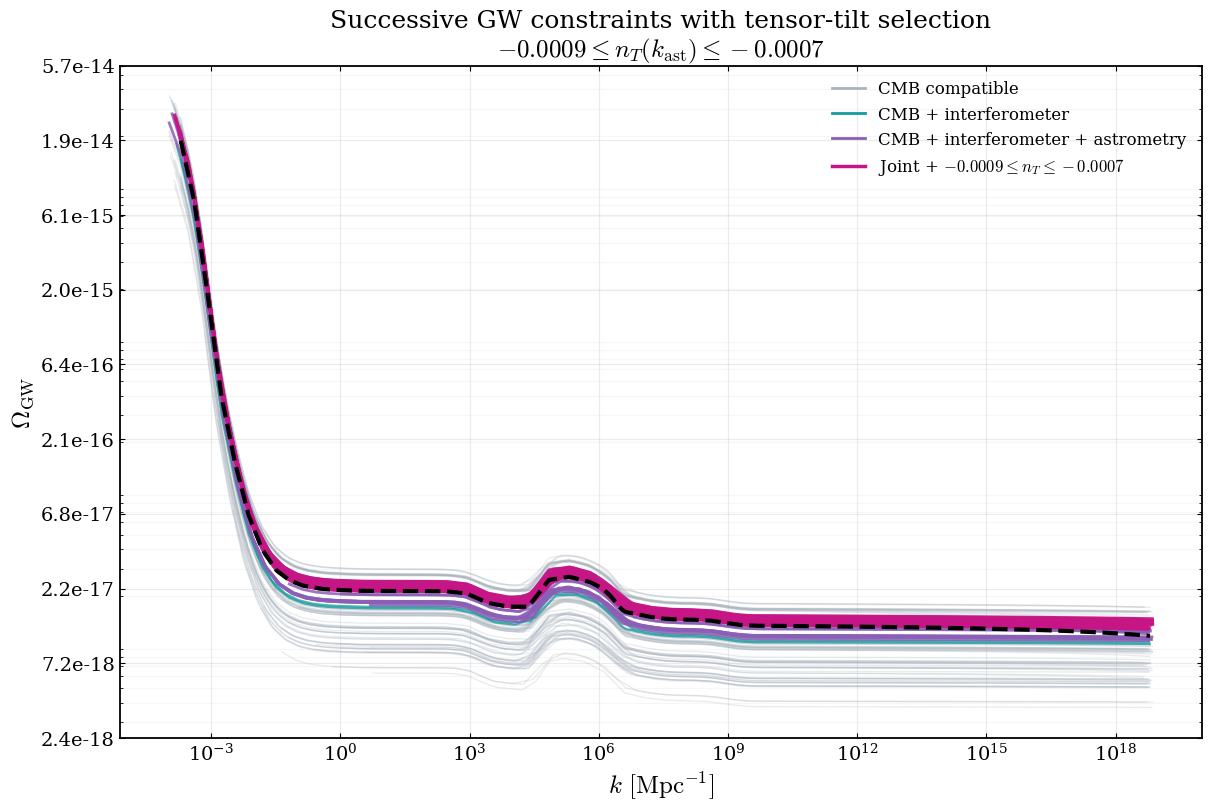

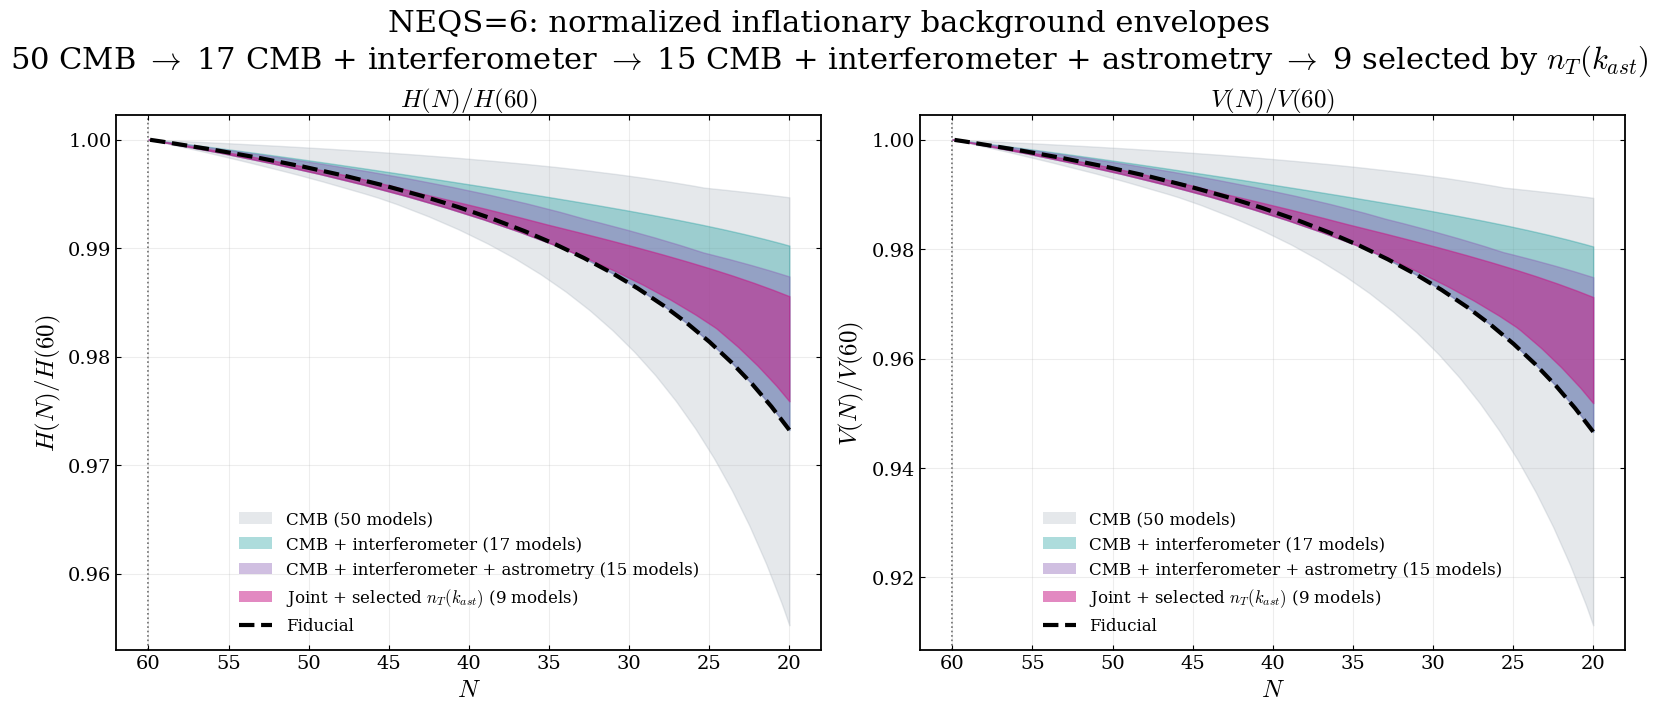


BACKGROUND ENVELOPE + nT SUMMARY
CMB models                   : 50
CMB + interferometer models  : 17
CMB + int + ast models       : 15
Joint + selected nT models   : 9
Fiducial model               : 0


In [68]:
nT_selected = plot_omegaGW_with_nT_highlight(
    cmb_passing_models,
    fiducial_data,
    nT_min=-0.9e-3,
    nT_max=-0.7e-3,
    NEQS=6,
)

background_envelopes_nT = (
    plot_background_envelopes_by_survival_with_nT(
        cmb_passing_models=cmb_passing_models,
        joint_result=joint_result,
        fiducial_measurements=fiducial_data,
        nT_selected=nT_selected,
        NEQS=6,
        N_ref=60.0,
        N_window=(20.0, 60.0),
    )
)

For final inspection of scalar and tensor spectra and eventual $\Omega_{GW}$, this is quick and easy to show

# Plot 19: Spectra for Compatible Models

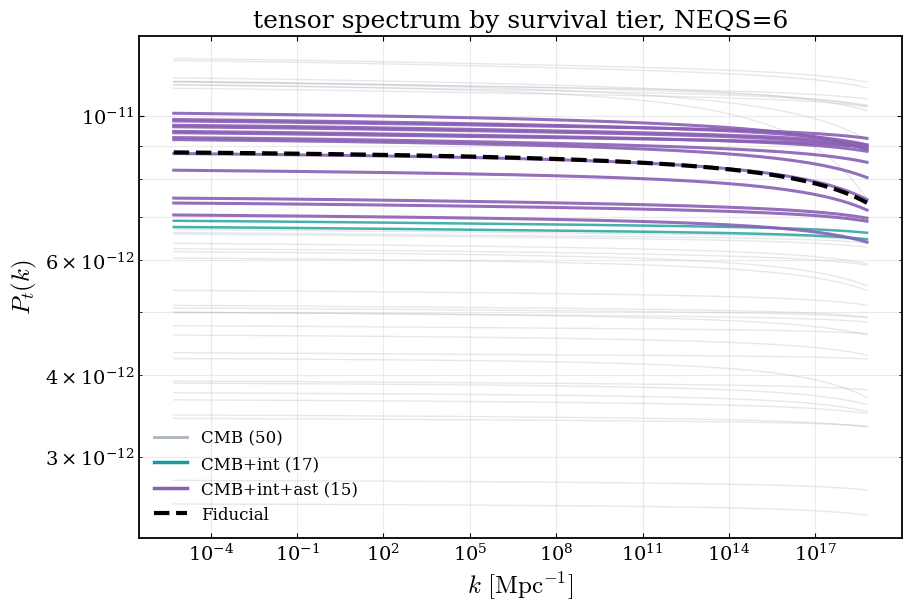

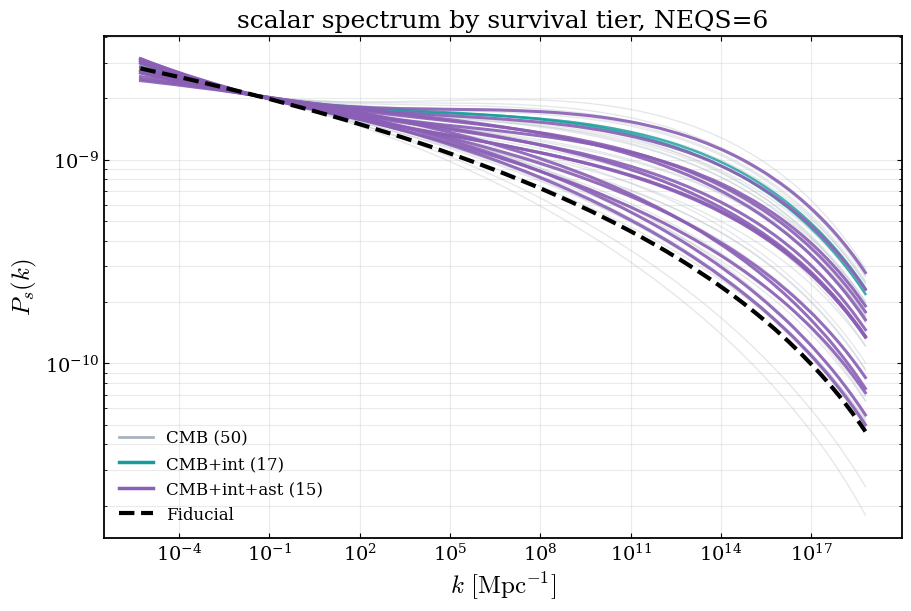

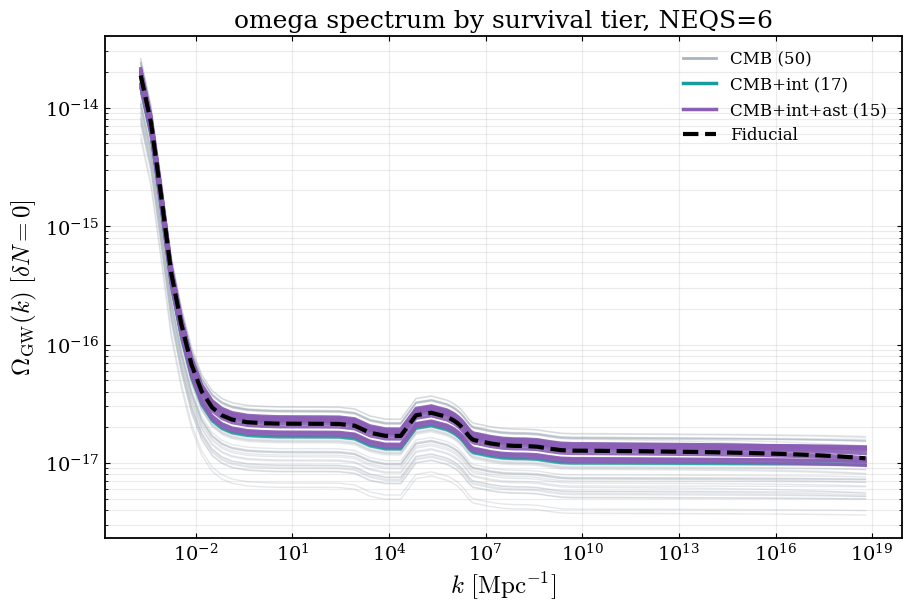

In [69]:
# ============================================================
# CHEAT SHEET: quick spectra plots by survival tier
# Reuses: cmb_passing_models, joint_result, fiducial_data,
#         tf_k_invMpc, tf_median, NEQS, h
# ============================================================

# --- Reusable helper: load raw P_s(k) or P_t(k) for one model ---
def _load_spectrum(curves, kind="tensor", NEQS=6, h=0.67):
    fname = f"spec_t_neqs{NEQS}.dat" if kind == "tensor" else f"spec_s_neqs{NEQS}.dat"
    spec_data = np.loadtxt(os.path.join(curves["outdir"], fname))

    k_raw = np.asarray(spec_data[:, 0], dtype=float) * h   # h/Mpc -> Mpc^-1
    P_raw = np.abs(np.asarray(spec_data[:, 1], dtype=float))

    good = np.isfinite(k_raw) & np.isfinite(P_raw) & (k_raw > 0) & (P_raw > 0)
    k_raw, P_raw = ensure_increasing_k(k_raw[good], P_raw[good], name="spectrum")
    return k_raw, P_raw


# # --- Reusable helper: shift + transfer -> Omega_GW(k), at given deltaN ---
#old below
# def _omega_gw_at_deltaN(curves, deltaN=0.0, NEQS=6, h=0.67):
#     k_raw, Pt_raw = _load_spectrum(curves, kind="tensor", NEQS=NEQS, h=h)

#     tf_k = np.asarray(tf_k_invMpc, dtype=float)
#     tf_T = np.asarray(tf_median, dtype=float)
#     good_tf = np.isfinite(tf_k) & np.isfinite(tf_T) & (tf_k > 0) & (tf_T > 0)
#     tf_k, tf_T = ensure_increasing_k(tf_k[good_tf], tf_T[good_tf], name="Transfer function")

#     logT_interp = PchipInterpolator(np.log(tf_k), np.log(tf_T), extrapolate=False)

#     k_shifted = k_raw * np.exp(-deltaN)
#     overlap = (k_shifted >= tf_k[0]) & (k_shifted <= tf_k[-1])
#     k_use, Pt_use = k_shifted[overlap], Pt_raw[overlap]

#     T_use = np.exp(logT_interp(np.log(k_use)))
#     valid = np.isfinite(T_use) & (T_use > 0)
#     k_use, Pt_use, T_use = k_use[valid], Pt_use[valid], T_use[valid]

#     OmegaGW = (T_use * Pt_use) / h**2
#     return k_use, OmegaGW
def _omega_gw_at_deltaN(
    curves,
    deltaN=0.0,
    NEQS=6,
    h=0.675,
    tf_file=None,
):
    """
    Shift the primordial tensor spectrum and apply the merged
    Kite + Saikawa-Shirai transfer function.

    Merged TF convention:

        T_Omega(k) = Omega_GW(k) / P_T(k)

    therefore

        Omega_GW(k) = T_Omega(k) * P_T(k)
    """

    # --------------------------------------------------------
    # Load primordial tensor spectrum
    # --------------------------------------------------------

    k_raw, Pt_raw = _load_spectrum(
        curves,
        kind="tensor",
        NEQS=NEQS,
        h=h,
    )

    # --------------------------------------------------------
    # Merged transfer-function file
    # --------------------------------------------------------

    if tf_file is None:

        tf_file = Path(
            "/Users/epmeador/Desktop/research/rwarthur/"
            "inflation_gravitywaves/inflation_code/"
            "InflationModels/merged_transfer_function/"
            "merged_gw_transfer_function_extended.dat"
        )

    else:

        tf_file = Path(tf_file)

    if not tf_file.exists():

        raise FileNotFoundError(
            f"Merged transfer-function file not found:\n{tf_file}"
        )

    # --------------------------------------------------------
    # Load merged TF
    #
    # Columns:
    #   0 : k [Mpc^-1]
    #   1 : f [Hz]
    #   2 : Omega_GW / P_T
    # --------------------------------------------------------

    tf_data = np.loadtxt(
        tf_file
    )

    tf_k = np.asarray(
        tf_data[:, 0],
        dtype=float,
    )

    tf_T = np.asarray(
        tf_data[:, 2],
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[
        good_tf
    ]

    tf_T = tf_T[
        good_tf
    ]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Merged transfer function",
    )

    # --------------------------------------------------------
    # Log-log interpolation
    # --------------------------------------------------------

    logT_interp = PchipInterpolator(
        np.log(tf_k),
        np.log(tf_T),
        extrapolate=False,
    )

    # --------------------------------------------------------
    # Shift k according to deltaN_piv
    # --------------------------------------------------------

    k_shifted = (
        k_raw
        * np.exp(-deltaN)
    )

    # --------------------------------------------------------
    # Restrict to merged-TF domain
    # --------------------------------------------------------

    overlap = (
        (k_shifted >= tf_k[0])
        & (k_shifted <= tf_k[-1])
    )

    k_use = k_shifted[
        overlap
    ]

    Pt_use = Pt_raw[
        overlap
    ]

    if len(k_use) < 2:

        raise ValueError(
            "Too few tensor-spectrum points overlap "
            "the merged transfer-function range."
        )

    # --------------------------------------------------------
    # Evaluate merged TF
    # --------------------------------------------------------

    T_use = np.exp(
        logT_interp(
            np.log(k_use)
        )
    )

    valid = (
        np.isfinite(T_use)
        & (T_use > 0)
    )

    k_use = k_use[
        valid
    ]

    Pt_use = Pt_use[
        valid
    ]

    T_use = T_use[
        valid
    ]

    # --------------------------------------------------------
    # Apply merged-TF convention
    #
    # T = Omega_GW / P_T
    #
    # => Omega_GW = T * P_T
    # --------------------------------------------------------

    OmegaGW = (
        T_use
        * Pt_use
    )

    return (
        k_use,
        OmegaGW,
    )



# --- Quick spaghetti plot for one spectral quantity ---
def quick_spectra_plot(
    quantity="tensor",     # "tensor", "scalar", or "omega"
    deltaN=0.0,             # only used for "omega"
    NEQS=6,
    h=0.67,
):
    int_ids = set(joint_result["interferometer_model_indices"])
    joint_ids = set(joint_result["joint_model_indices"])
    fid_id = int(fiducial_data["model_index"])

    colors = {"cmb": "#AAB4BE", "int": "#169C9C", "joint": "#8A5FB5", "fid": "black"}

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

    def get_curve(curves):
        if quantity == "omega":
            return _omega_gw_at_deltaN(curves, deltaN=deltaN, NEQS=NEQS, h=h)
        else:
            return _load_spectrum(curves, kind=quantity, NEQS=NEQS, h=h)

    for curves in cmb_passing_models:
        model_index = int(curves["model_index"])
        if model_index == fid_id:
            continue  # draw fiducial last, on top

        try:
            k_use, y = get_curve(curves)
        except (FileNotFoundError, ValueError):
            continue

        if model_index in joint_ids:
            color, lw, alpha, z = colors["joint"], 2.2, 0.9, 3
        elif model_index in int_ids:
            color, lw, alpha, z = colors["int"], 1.8, 0.8, 2
        else:
            color, lw, alpha, z = colors["cmb"], 1.0, 0.30, 1

        ax.loglog(k_use, y, color=color, lw=lw, alpha=alpha, zorder=z)

    # Fiducial on top
    for curves in cmb_passing_models:
        if int(curves["model_index"]) == fid_id:
            k_use, y = get_curve(curves)
            ax.loglog(k_use, y, color=colors["fid"], lw=3.0, ls="--", zorder=5, label="Fiducial")
            break

    ylabel = {
        "tensor": r"$P_t(k)$",
        "scalar": r"$P_s(k)$",
        "omega": rf"$\Omega_{{\rm GW}}(k)\ [\delta N={deltaN:g}]$",
    }[quantity]

    ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(
        handles=[
            Line2D([0],[0], color=colors["cmb"], lw=2, label=f"CMB ({len(cmb_passing_models)})"),
            Line2D([0],[0], color=colors["int"], lw=2.5, label=f"CMB+int ({len(int_ids)})"),
            Line2D([0],[0], color=colors["joint"], lw=2.5, label=f"CMB+int+ast ({len(joint_ids)})"),
            Line2D([0],[0], color=colors["fid"], lw=3, ls="--", label="Fiducial"),
        ],
        frameon=False, loc="best",
    )
    ax.set_title(f"{quantity} spectrum by survival tier, NEQS={NEQS}")
    plt.show()


# ============================================================
# Quick calls
# ============================================================
quick_spectra_plot("tensor")               # P_t(k), unshifted
quick_spectra_plot("scalar")               # P_s(k), unshifted
quick_spectra_plot("omega", deltaN=0.0)    # Omega_GW(k) at nominal pivot